# Валидация TTS систем при условиях больничного шума

In [ ]:
# ============================================
# УСТАНОВКА ЗАВИСИМОСТЕЙ
# ============================================

!pip install -q faster-whisper jiwer soundfile pandas openpyxl matplotlib scipy numpy tqdm scikit-learn sentence-transformers nltk vosk

import nltk
nltk.download('punkt', quiet=True)

print("✓ Установка завершена")

✓ Установка завершена


In [ ]:
# ============================================
# ИМПОРТЫ
# ============================================

import os
import re
import json
import subprocess
import wave
import math
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import soundfile as sf
from scipy import signal
from scipy.stats import kruskal, mannwhitneyu, friedmanchisquare, spearmanr
from scipy.spatial.distance import cosine
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_sim
import torch

# NLTK для BLEU
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Sentence Transformers для семантического сходства
from sentence_transformers import SentenceTransformer

# Whisper
from faster_whisper import WhisperModel

# Vosk
from vosk import Model as VoskModel, KaldiRecognizer, SetLogLevel
SetLogLevel(-1)

# Jiwer
from jiwer import wer, cer

print("✓ Импорты завершены")

✓ Импорты завершены


In [ ]:
# ============================================
# НАСТРОЙКИ
# ============================================

EXCEL_PATH = "/content/med_set.xlsx"
ALICE_INPUT_DIR = "/content"

WORK_DIR = "/content/eval_work"
ALICE_WAV_DIR = os.path.join(WORK_DIR, "alice_wav")
NOISY_DIR = os.path.join(WORK_DIR, "noisy")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

SAMPLE_RATE = 24000
NOISE_TYPES = ['white', 'pink']
SNR_LEVELS = [0, 5, 10, 15, 20]  # Добавлен 0 (очень сильный шум)

WHISPER_MODEL = "small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
COMPUTE_TYPE = "float16" if DEVICE == "cuda" else "float32"

# Создаем директории
for d in [ALICE_WAV_DIR, NOISY_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Устройство: {DEVICE}")
print(f"SNR уровни: {SNR_LEVELS}")

Устройство: cpu
SNR уровни: [0, 5, 10, 15, 20]


In [ ]:
# ============================================
# ЗАГРУЗКА МОДЕЛЕЙ
# ============================================

print("=== ЗАГРУЗКА МОДЕЛЕЙ ===\n")

# 1. Whisper
print("1. Whisper...")
whisper_model = WhisperModel(WHISPER_MODEL, device=DEVICE, compute_type=COMPUTE_TYPE)
print(f"   ✓ Whisper {WHISPER_MODEL} на {DEVICE}")

# 2. Vosk ASR
print("\n2. Vosk ASR...")
VOSK_ASR_AVAILABLE = False
vosk_asr_model = None

try:
    vosk_path = "/content/models/vosk-model-ru-0.42"
    if not os.path.exists(vosk_path):
        !mkdir -p /content/models
        %cd /content/models
        !wget -q https://alphacephei.com/vosk/models/vosk-model-ru-0.42.zip
        !unzip -q vosk-model-ru-0.42.zip
        !mv vosk-model-ru-0.42 vosk-model-ru
        vosk_path = "/content/models/vosk-model-ru"
        %cd /content

    vosk_asr_model = VoskModel(vosk_path)
    VOSK_ASR_AVAILABLE = True
    print(f"   ✓ Vosk ASR загружен")
except Exception as e:
    print(f"   ⚠️ Vosk ASR недоступен: {e}")

# 3. Sentence Transformer для семантического сходства
print("\n3. Sentence Transformer...")
try:
    sbert_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
    SBERT_AVAILABLE = True
    print(f"   ✓ SBERT загружен")
except Exception as e:
    print(f"   ⚠️ SBERT недоступен: {e}")
    SBERT_AVAILABLE = False

print("\n✓ Все модели загружены")

=== ЗАГРУЗКА МОДЕЛЕЙ ===

1. Whisper...
   ✓ Whisper small на cpu

2. Vosk ASR...
/content/models
/content
   ✓ Vosk ASR загружен

3. Sentence Transformer...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ✓ SBERT загружен

✓ Все модели загружены


In [ ]:
# ============================================
# ЗАГРУЗКА ДАТАСЕТА
# ============================================
EXCEL_PATH = "/content/drive/MyDrive/dataset_ds/med_set.xlsx"

def load_dataset(excel_path):
    """Загружает датасет из Excel"""
    if not Path(excel_path).exists():
        raise FileNotFoundError(f"Файл {excel_path} не найден!")

    df = pd.read_excel(excel_path, sheet_name=0, dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Ищем колонки
    col_map = {}
    expected = {
        'id': ['id', 'ID', 'номер'],
        'short_label': ['short', 'short_label', 'brief', 'краткий'],
        'reference_utterance': ['reference', 'reference_utterance', 'ref', 'эталон'],
        'context_text': ['context', 'context_text', 'full', 'контекст']
    }

    for key, variants in expected.items():
        for col in df.columns:
            col_clean = col.lower().replace(' ', '_')
            if any(v.lower() in col_clean for v in variants):
                col_map[key] = col
                break

    refs = {}
    for _, row in df.iterrows():
        idv = str(row.get(col_map.get('id'), "")).strip()
        if not idv or idv.lower() == 'nan':
            continue

        refs[idv] = {
            'id': idv,
            'short': str(row.get(col_map.get('short_label', ''), "")).strip(),
            'reference_utterance': str(row.get(col_map.get('reference_utterance', ''), "")).strip(),
            'context_text': str(row.get(col_map.get('context_text', ''), "")).strip()
        }

    return refs

refs = load_dataset(EXCEL_PATH)
print(f"Загружено {len(refs)} записей")
print(f"Пример: {list(refs.keys())[0]}")

Загружено 50 записей
Пример: 07-143


In [ ]:
# ============================================
# ОБРАБОТКА ФАЙЛОВ АЛИСЫ
# ============================================

def parse_filename(filename):
    """Парсит 02-005_2 -> (02-005, 2)"""
    stem = Path(filename).stem
    patterns = [
        r'([0-9]{2,}-[0-9]{1,4})[_\-\.]?0?([123])$',
        r'([0-9]{2,}-[0-9]{1,4}).*?[_\-\s]([123])$'
    ]

    for pattern in patterns:
        m = re.search(pattern, stem)
        if m:
            return m.group(1), m.group(2)

    id_match = re.match(r'([0-9]{2,}-[0-9]{1,4})', stem)
    if id_match:
        id_part = id_match.group(1)
        var_match = re.search(r'([123])$', stem)
        if var_match:
            return id_part, var_match.group(1)

    return None, None

def convert_to_wav(input_path, output_path, sr=24000):
    """Конвертирует в WAV mono 16-bit"""
    cmd = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", str(sr), "-ac", "1",
        "-vn", "-sample_fmt", "s16",
        output_path
    ]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except:
        return False

# Находим и конвертируем файлы Алисы
alice_files = []
for pattern in ['*.mp4', '*.MP4', '*.wav', '*.WAV']:
    alice_files.extend(Path(ALICE_INPUT_DIR).glob(pattern))

alice_data = {}

for fpath in sorted([str(f) for f in alice_files]):
    fname = os.path.basename(fpath)
    id_part, variant = parse_filename(fname)

    if id_part and variant:
        wav_name = f"{id_part}_{variant}.wav"
        wav_path = os.path.join(ALICE_WAV_DIR, wav_name)

        if convert_to_wav(fpath, wav_path):
            alice_data[(id_part, variant)] = {
                'original': fpath,
                'wav': wav_path,
                'id': id_part,
                'variant': variant
            }

print(f"Обработано {len(alice_data)} файлов Алисы")
for (idv, var), info in list(alice_data.items())[:3]:
    print(f"  {idv}_{var}: {info['wav']}")

Обработано 33 файлов Алисы
  02-005_2: /content/eval_work/alice_wav/02-005_2.wav
  09-179_1: /content/eval_work/alice_wav/09-179_1.wav
  09-179_2: /content/eval_work/alice_wav/09-179_2.wav


In [ ]:
# ============================================
# ГЕНЕРАЦИЯ ШУМА
# ============================================

class NoiseGenerator:
    def __init__(self, sr=24000):
        self.sr = sr

    def white(self, n_samples):
        return np.random.normal(0, 1, n_samples)

    def pink(self, n_samples):
        white = np.random.normal(0, 1, n_samples)
        b, a = signal.butter(2, 0.1, btype='low')
        pink = signal.lfilter(b, a, white)
        return pink / (np.std(pink) + 1e-10)

    def add_noise(self, clean, noise_type, snr_db):
        """Добавляет шум с заданным SNR"""
        rms_signal = np.sqrt(np.mean(clean**2))

        if noise_type == 'white':
            noise = self.white(len(clean))
        else:
            noise = self.pink(len(clean))

        rms_noise = rms_signal / (10 ** (snr_db / 20))
        noise = noise * (rms_noise / (np.sqrt(np.mean(noise**2)) + 1e-10))

        noisy = clean + noise
        max_val = np.max(np.abs(noisy))
        if max_val > 1:
            noisy = noisy / max_val * 0.95

        return noisy

def create_noisy_versions(clean_path, output_dir, prefix, noise_gen):
    """Создает зашумленные версии для всех SNR"""
    audio, sr = sf.read(clean_path)

    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0

    results = {('clean', None): clean_path}  # Добавляем clean

    for noise_type in NOISE_TYPES:
        for snr in SNR_LEVELS:
            noisy = noise_gen.add_noise(audio, noise_type, snr)

            filename = f"{prefix}_{noise_type}_snr{snr}.wav"
            filepath = os.path.join(output_dir, filename)

            sf.write(filepath, (noisy * 32767).astype(np.int16), sr)
            results[(noise_type, snr)] = filepath

    return results

# Генерируем шум
print("=== ГЕНЕРАЦИЯ ШУМА ===\n")
noise_gen = NoiseGenerator(24000)

alice_noisy = {}

for (id_part, variant), info in alice_data.items():
    prefix = f"alice_{id_part}_{variant}"
    alice_noise_dir = os.path.join(NOISY_DIR, "alice")
    os.makedirs(alice_noise_dir, exist_ok=True)

    versions = create_noisy_versions(info['wav'], alice_noise_dir, prefix, noise_gen)

    for (nt, snr), path in versions.items():
        alice_noisy[(id_part, variant, nt, snr)] = path

    print(f"✓ {id_part}_{variant}: {len(versions)} версий (clean + {len(versions)-1} noisy)")

print(f"\nВсего файлов: {len(alice_noisy)}")

=== ГЕНЕРАЦИЯ ШУМА ===

✓ 02-005_2: 11 версий (clean + 10 noisy)
✓ 09-179_1: 11 версий (clean + 10 noisy)
✓ 09-179_2: 11 версий (clean + 10 noisy)
✓ 09-179_3: 11 версий (clean + 10 noisy)
✓ 15-014_1: 11 версий (clean + 10 noisy)
✓ 15-014_2: 11 версий (clean + 10 noisy)
✓ 15-014_3: 11 версий (clean + 10 noisy)
✓ 19-021_1: 11 версий (clean + 10 noisy)
✓ 19-021_2: 11 версий (clean + 10 noisy)
✓ 19-021_3: 11 версий (clean + 10 noisy)
✓ 40-131_2: 11 версий (clean + 10 noisy)
✓ 40-131_3: 11 версий (clean + 10 noisy)
✓ 40-138_1: 11 версий (clean + 10 noisy)
✓ 40-138_2: 11 версий (clean + 10 noisy)
✓ 40-138_3: 11 версий (clean + 10 noisy)
✓ 40-142_1: 11 версий (clean + 10 noisy)
✓ 40-142_3: 11 версий (clean + 10 noisy)
✓ 40-153_3: 11 версий (clean + 10 noisy)
✓ 40-439_1: 11 версий (clean + 10 noisy)
✓ 40-439_2: 11 версий (clean + 10 noisy)
✓ 40-439_3: 11 версий (clean + 10 noisy)
✓ 40-445_2: 11 версий (clean + 10 noisy)
✓ 40-508_2: 11 версий (clean + 10 noisy)
✓ 40-508_3: 11 версий (clean + 10

In [ ]:
# ============================================
# ЗАГРУЗКА МЕДИЦИНСКИХ ТЕРМИНОВ ИЗ ФАЙЛОВ АЛИСЫ
# ============================================

def load_medical_terms_from_files():
    """
    Загружает медицинские термины из двух MP4 файлов Алисы.
    Конвертирует MP4 в WAV, распознает речь, извлекает термины.
    """
    terms = {
        'disease': [],      # Заболевания
        'analysis': []      # Анализы/исследования
    }

    # Пути к файлам
    disease_mp4 = "/content/drive/MyDrive/dataset_ds/disease.mp4"
    analysis_mp4 = "/content/analysis.mp4"

    # Конвертируем и распознаем disease.mp4
    if os.path.exists(disease_mp4):
        print("Обработка disease.mp4...")
        disease_wav = os.path.join(ALICE_WAV_DIR, "disease.wav")
        if convert_to_wav(disease_mp4, disease_wav):
            # Распознаем Whisper (лучше для словарного запаса)
            text = transcribe_whisper(disease_wav)
            # Извлекаем термины (каждая строка = один термин)
            disease_terms = [t.strip() for t in text.split('\n') if len(t.strip()) > 3]
            terms['disease'] = disease_terms
            print(f"  ✓ Загружено {len(disease_terms)} терминов заболеваний")
            # Сохраняем для проверки
            with open(os.path.join(RESULTS_DIR, "disease_terms.txt"), "w", encoding="utf-8") as f:
                f.write("\n".join(disease_terms))

    # Конвертируем и распознаем analysis.mp4
    if os.path.exists(analysis_mp4):
        print("Обработка analysis.mp4...")
        analysis_wav = os.path.join(ALICE_WAV_DIR, "analysis.wav")
        if convert_to_wav(analysis_mp4, analysis_wav):
            text = transcribe_whisper(analysis_wav)
            # Извлекаем термины
            analysis_terms = [t.strip() for t in text.split('\n') if len(t.strip()) > 3]
            terms['analysis'] = analysis_terms
            print(f"  ✓ Загружено {len(analysis_terms)} терминов анализов")
            # Сохраняем для проверки
            with open(os.path.join(RESULTS_DIR, "analysis_terms.txt"), "w", encoding="utf-8") as f:
                f.write("\n".join(analysis_terms))

    return terms

# Загружаем термины из файлов (глобальная переменная)
MEDICAL_TERMS_FROM_FILES = load_medical_terms_from_files()

# Объединяем все термины в один словарь
def build_medical_lexicon(refs_dict, external_terms=None):
    """
    Строит расширенный медицинский словарь:
    1. Из текстов Excel (short, reference, context)
    2. Из распознанных файлов disease.mp4 и analysis.mp4
    3. Дополнительные медицинские термины
    """
    lexicon = set()

    # 1. Извлекаем из текстов Excel
    for data in refs_dict.values():
        for text in [data['short'], data['reference_utterance'], data['context_text']]:
            if text:
                words = re.findall(r'\b[а-яёa-z]+\b', text.lower())
                for w in words:
                    if len(w) > 3:
                        lexicon.add(w)

    # 2. Добавляем термины из файлов (распознанные + оригинальные списки)
    if external_terms:
        for category, terms in external_terms.items():
            for term in terms:
                # Добавляем полный термин
                lexicon.add(term.lower())
                # Добавляем отдельные слова из термина
                words = re.findall(r'\b[а-яёa-z]+\b', term.lower())
                for w in words:
                    if len(w) > 3:
                        lexicon.add(w)

    # 3. Добавляем оригинальные списки (на случай если распознавание было неточным)
    original_disease_terms = [
        'алкалоз', 'анемия', 'атипичная пневмония', 'бешенство', 'болезнь альцгеймера',
        'бронхит', 'булимия', 'вич-инфекция', 'воспалительные заболевания кишечника',
        'гастрит', 'гипертиреоз', 'гипогликемия', 'грибковые инфекции', 'диарея',
        'желтуха', 'желчнокаменная болезнь', 'заболевания паращитовидных желез', 'запор',
        'инсульт', 'крапивница', 'лейкоз', 'малярия', 'миокардит',
        'нарушения кислотного равновесия крови', 'ожирение', 'остеопороз',
        'острый аппендицит', 'острый синусит', 'панкреатит', 'педикулез', 'псориаз',
        'рак молочной железы', 'рассеянный склероз', 'сальмонеллез', 'сахарный диабет',
        'синдром дауна', 'синдром жильбера', 'системная красная волчанка',
        'тошнота и рвота', 'тромбофилия', 'углеводная недостаточность', 'феохромоцитома',
        'холера', 'хроническая почечная недостаточность', 'чесотка', 'шизофрения',
        'эндометриоз', 'хроническая сердечная недостаточность', 'целиакия', 'цервицит'
    ]

    original_analysis_terms = [
        'anti-hav', 'антитела', 'адренокортикотропный гормон', 'актг',
        'аллерген d74 - клещ домашней пыли', 'антистресс', 'антитела к инсулину',
        'базовые биохимические показатели', 'беременность - i триместр',
        'вальпроевая кислота', 'вирус клещевого энцефалита', 'витамин b1', 'тиамин',
        'волчаночный антикоагулянт', 'выявление мутаций гена kras',
        'габапентин', 'генетические причины мужского бесплодия',
        'генодиагностика болезни вильсона - коновалова', 'мутации гена atp7b',
        'гистамин в крови', 'глюкоза в моче', 'диагностика аутоиммунного поражения почек',
        'диагностика воспалительных миокардиопатий', 'европий в волосах',
        'ежегодное лабораторное обследование женщин', 'ежегодное лабораторное обследование мужчин',
        'ежегодное лабораторное обследование ребенка', 'железо в ногтях',
        'жидкостное цитологическое исследование', 'щитовидной железы',
        'здоровый жкт', 'зипрасидон', 'золото в плазме',
        'иммунологическое обследование при аутоиммунных заболеваниях',
        'инсулин', 'йод в моче', 'кадмий в волосах', 'калий в сыворотке',
        'кальций в сыворотке', 'клинический анализ крови', 'лейкоцитарная формула',
        'комплексное серологическое обследование', 'аутоиммунные эндокринопатии',
        'компонентная диагностика аллергии на молоко', 'лабораторная диагностика железодефицитной анемии',
        'лабораторное обследование при артериальной гипертензии',
        'лабораторные маркеры рака легких', 'лактат', 'метаболический баланс',
        'метгемоглобин в крови', 'наследственная гипербилирубинемия',
        'нэш-фибротест', 'обмен и усвоение белка', 'обследование щитовидной железы',
        'оланзапин', 'определение наличия летучих токсических веществ в моче', 'орви-скрин'
    ]

    # Добавляем оригинальные термины
    for term in original_disease_terms + original_analysis_terms:
        lexicon.add(term.lower())
        words = re.findall(r'\b[а-яёa-z0-9\-]+\b', term.lower())
        for w in words:
            if len(w) > 2:
                lexicon.add(w)

    # 4. Дополнительные общие медицинские термины
    additional_terms = [
        'гипертония', 'гипертонический', 'криз', 'кризис', 'давление', 'артериальный',
        'сердце', 'сердечный', 'тахикардия', 'брадикардия', 'аритмия',
        'сахар', 'диабет', 'глюкоза', 'гликемия',
        'холестерин', 'липид', 'триглицерид',
        'анализ', 'кровь', 'плазма', 'сыворотка',
        'болезнь', 'синдром', 'диагноз', 'симптом', 'лечение',
        'препарат', 'лекарство', 'доза', 'мг', 'мл', 'таблетка',
        'врач', 'терапевт', 'кардиолог', 'эндокринолог',
        'госпитализация', 'стационар', 'поликлиника',
        'рекомендация', 'назначение', 'прием', 'питание', 'диета',
        'анализ', 'исследование', 'обследование', 'диагностика',
        'ген', 'мутация', 'антитела', 'гормон', 'витамин',
        'инфекция', 'воспаление', 'опухоль', 'рак',
        'почка', 'печень', 'селезенка', 'желудок', 'кишечник',
        'щитовидная', 'поджелудочная', 'надпочечник', 'гипофиз'
    ]

    lexicon.update(additional_terms)

    return lexicon, original_disease_terms, original_analysis_terms

# Строим словарь
medical_lexicon, disease_list, analysis_list = build_medical_lexicon(refs, MEDICAL_TERMS_FROM_FILES)

print(f"\n=== МЕДИЦИНСКИЙ СЛОВАРЬ ===")
print(f"Всего уникальных терминов: {len(medical_lexicon)}")
print(f"Заболеваний в списке: {len(disease_list)}")
print(f"Анализов в списке: {len(analysis_list)}")
print(f"Примеры терминов: {list(medical_lexicon)[:15]}")

Обработка disease.mp4...
Обработка analysis.mp4...

=== МЕДИЦИНСКИЙ СЛОВАРЬ ===
Всего уникальных терминов: 1479
Заболеваний в списке: 50
Анализов в списке: 57
Примеры терминов: ['сахарный диабет', 'появляющуюся', 'поступлением', 'витамин', 'имеет', 'детском', 'триместр', 'жидкостное', 'распространенности', 'генодиагностика болезни вильсона - коновалова', 'иммуноглобулины', 'фосфолипидами', 'йод', 'заболеваниях', 'наследственная']


In [ ]:
# ============================================
# КАЛЬКУЛЯТОР МЕТРИК
# ============================================

class MetricsCalculator:
    def __init__(self, medical_lexicon, disease_terms, analysis_terms, sbert_model=None):
        self.med_lexicon = medical_lexicon
        self.disease_terms = set(t.lower() for t in disease_terms)
        self.analysis_terms = set(t.lower() for t in analysis_terms)
        self.sbert = sbert_model

        self.tfidf = TfidfVectorizer(
            lowercase=True,
            token_pattern=r'[а-яёa-z0-9\-]+',
            ngram_range=(1, 2),
            min_df=1
        )
        self.smoothing = SmoothingFunction().method1

    def calculate_wer(self, ref, hyp):
        """Стандартный WER"""
        if not ref or not hyp:
            return 1.0 if ref else 0.0
        try:
            return wer(ref, hyp)
        except:
            return 1.0 if ref else 0.0

    def calculate_cer(self, ref, hyp):
        """Character Error Rate"""
        if not ref or not hyp:
            return 1.0 if ref else 0.0
        try:
            return cer(ref, hyp)
        except:
            return 1.0 if ref else 0.0

    def calculate_mwer(self, ref, hyp):
        """
        Medical WER - частота ошибок в медицинских терминах.
        Сравнивает только слова из медицинского словаря.
        """
        if not ref:
            return None

        # Извлекаем медицинские слова из референса и гипотезы
        ref_words = [w for w in ref.split() if w in self.med_lexicon]
        hyp_words = [w for w in hyp.split() if w in self.med_lexicon]

        if len(ref_words) == 0:
            return 0.0  # Нет медицинских терминов в референсе

        try:
            return wer(" ".join(ref_words), " ".join(hyp_words))
        except:
            return 1.0

    def calculate_disease_cer(self, ref, hyp):
        """
        CER только для терминов заболеваний (из disease.mp4).
        Проверяет точность распознавания названий болезней.
        """
        if not ref:
            return None

        # Находим термины заболеваний в тексте
        ref_diseases = []
        hyp_diseases = []

        for disease in self.disease_terms:
            if disease in ref:
                ref_diseases.append(disease)
                # Ищем соответствие в гипотезе (частичное)
                found = False
                for hyp_d in self.disease_terms:
                    if hyp_d in hyp:
                        hyp_diseases.append(hyp_d)
                        found = True
                        break
                if not found:
                    hyp_diseases.append("")  # Пропущен термин

        if len(ref_diseases) == 0:
            return None

        # Считаем CER для найденных терминов
        total_cer = 0
        for r, h in zip(ref_diseases, hyp_diseases):
            total_cer += self.calculate_cer(r, h)

        return total_cer / len(ref_diseases)

    def calculate_analysis_cer(self, ref, hyp):
        """
        CER только для терминов анализов (из analysis.mp4).
        Проверяет точность распознавания названий лабораторных исследований.
        """
        if not ref:
            return None

        # Находим термины анализов
        ref_analyses = []
        hyp_analyses = []

        for analysis in self.analysis_terms:
            if analysis in ref:
                ref_analyses.append(analysis)
                found = False
                for hyp_a in self.analysis_terms:
                    if hyp_a in hyp:
                        hyp_analyses.append(hyp_a)
                        found = True
                        break
                if not found:
                    hyp_analyses.append("")

        if len(ref_analyses) == 0:
            return None

        total_cer = 0
        for r, h in zip(ref_analyses, hyp_analyses):
            total_cer += self.calculate_cer(r, h)

        return total_cer / len(ref_analyses)

    def calculate_tfidf_cosine(self, ref, hyp):
        """Косинусное сходство TF-IDF"""
        if not ref or not hyp:
            return 0.0

        try:
            tfidf_matrix = self.tfidf.fit_transform([ref, hyp])
            return float(sk_cosine_sim(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0])
        except:
            return 0.0

    def calculate_bleu(self, ref, hyp):
        """BLEU score"""
        if not ref or not hyp:
            return 0.0

        ref_tokens = ref.split()
        hyp_tokens = hyp.split()

        if len(hyp_tokens) == 0:
            return 0.0

        try:
            return sentence_bleu(
                [ref_tokens],
                hyp_tokens,
                smoothing_function=self.smoothing,
                weights=(0.5, 0.5, 0, 0)
            )
        except:
            return 0.0

    def calculate_semantic_similarity(self, ref, hyp):
        """Семантическое сходство через SBERT"""
        if not self.sbert or not ref or not hyp:
            return None

        try:
            embeddings = self.sbert.encode([ref, hyp], convert_to_tensor=True)
            cos_sim = torch.nn.functional.cosine_similarity(
                embeddings[0].unsqueeze(0),
                embeddings[1].unsqueeze(0)
            )
            return float(cos_sim[0])
        except:
            return None

# Инициализируем калькулятор с разделением на disease/analysis
metrics_calc = MetricsCalculator(
    medical_lexicon,
    disease_list,
    analysis_list,
    sbert_model if SBERT_AVAILABLE else None
)

print("✓ Калькулятор метрик инициализирован")
print(f"  - Общий мед. словарь: {len(medical_lexicon)} терминов")
print(f"  - Заболеваний: {len(disease_list)}")
print(f"  - Анализов: {len(analysis_list)}")

✓ Калькулятор метрик инициализирован
  - Общий мед. словарь: 1479 терминов
  - Заболеваний: 50
  - Анализов: 57


## Добавление шума

Три вида шума:
- белый шум
- розовый шум
- реальный шум из больницы

Транскрипция выполняется с помощью двух ASR систем: Whisper и Vosk

In [ ]:
# ============================================
# ЗАГРУЗКА ДАТАСЕТА ШУМА ИЗ KAGGLE
# ============================================

import kagglehub
from glob import glob

# Скачиваем датасет
print("Скачивание датасета hospital-ambient-noise...")
path = kagglehub.dataset_download("nafin59/hospital-ambient-noise")
print(f"Датасет скачан: {path}")

# Находим все wav файлы (используем оригинальные, не фильтрованные - 44.1kHz)
# Пробуем разные пути (Kaggle vs Colab)
possible_paths = [
    os.path.join(path, "Hospital noise original", "*.wav"),
    os.path.join(path, "Hospital noise original", "**", "*.wav"),
    "/content/hospital-ambient-noise/Hospital noise original/**/*.wav",
    "/content/datasets/hospital-ambient-noise/Hospital noise original/**/*.wav"
]

noise_files = []
for pattern in possible_paths:
    files = glob(pattern, recursive=True)
    if files:
        noise_files.extend(files)
        print(f"Найдено {len(files)} файлов по пути: {pattern}")

# Убираем дубликаты
noise_files = list(set(noise_files))
print(f"\nВсего загружено {len(noise_files)} файлов шума больницы")

# Проверяем один файл
if noise_files:
    test_audio, test_sr = sf.read(noise_files[0])
    print(f"Пример файла: {os.path.basename(noise_files[0])}")
    print(f"  Длительность: {len(test_audio)/test_sr:.2f}с, частота: {test_sr}Hz")

Скачивание датасета hospital-ambient-noise...


100%|██████████| 191M/191M [00:09<00:00, 21.9MB/s]

Extracting files...


Датасет скачан: /root/.cache/kagglehub/datasets/nafin59/hospital-ambient-noise/versions/2
Найдено 562 файлов по пути: /root/.cache/kagglehub/datasets/nafin59/hospital-ambient-noise/versions/2/Hospital noise original/**/*.wav

Всего загружено 562 файлов шума больницы
Пример файла: seg_141.wav
  Длительность: 5.00с, частота: 44100Hz


In [ ]:
# ============================================
# КЛАСС ДЛЯ РЕАЛЬНОГО ШУМА БОЛЬНИЦЫ
# ============================================

class HospitalNoiseGenerator:
    def __init__(self, noise_files, target_sr=24000):
        """
        Генератор шума из реальных аудио файлов больницы

        Args:
            noise_files: список путей к wav файлам
            target_sr: целевая частота дискретизации (24kHz как у Алисы)
        """
        self.noise_files = noise_files
        self.target_sr = target_sr
        self.noise_cache = {}  # Кэш загруженных шумов
        self.resamplers = {}   # Кэш ресемплеров

        print(f"Инициализирован генератор с {len(noise_files)} файлами шума")

    def _load_and_resample(self, file_path):
        """Загружает файл и ресемплирует в target_sr"""
        if file_path in self.noise_cache:
            return self.noise_cache[file_path]

        # Загружаем
        audio, sr = sf.read(file_path)

        # Конвертируем в float32 [-1, 1]
        if audio.dtype == np.int16:
            audio = audio.astype(np.float32) / 32768.0

        # В mono если стерео
        if len(audio.shape) > 1:
            audio = audio.mean(axis=1)

        # Ресемплируем если нужно
        if sr != self.target_sr:
            # Создаем ресемплер для этой частоты если еще нет
            key = (sr, self.target_sr)
            if key not in self.resamplers:
                self.resamplers[key] = torchaudio.transforms.Resample(
                    orig_freq=sr,
                    new_freq=self.target_sr
                )

            # Применяем ресемплинг через torch
            audio_tensor = torch.from_numpy(audio).float()
            audio_tensor = self.resamplers[key](audio_tensor.unsqueeze(0)).squeeze(0)
            audio = audio_tensor.numpy()

        # Нормализуем
        audio = audio / (np.max(np.abs(audio)) + 1e-10)

        self.noise_cache[file_path] = audio
        return audio

    def _generate_noise_segment(self, target_length):
        """
        Генерирует шумовой сегмент нужной длины из случайных кусков файлов

        Может:
        1. Склеивать последовательно (конкатенация)
        2. Накладывать друг на друга (смешивание)
        3. Брать случайный кусок из одного файла
        """
        noise_segments = []
        current_length = 0

        # Стратегия: смешиваем 2-4 случайных файла с разными смещениями
        num_files = random.randint(2, 4)

        for _ in range(num_files):
            # Выбираем случайный файл
            file_path = random.choice(self.noise_files)
            audio = self._load_and_resample(file_path)

            # Случайное смещение (начинаем не с начала)
            max_offset = max(0, len(audio) - target_length // 2)
            offset = random.randint(0, max_offset) if max_offset > 0 else 0

            # Берем кусок или весь файл
            segment = audio[offset:offset + target_length]

            # Если короткий - дополняем тишиной или повторяем
            if len(segment) < target_length:
                # Повторяем сегмент пока не достигнем нужной длины
                repeats = int(np.ceil(target_length / len(segment)))
                segment = np.tile(segment, repeats)[:target_length]

            noise_segments.append(segment[:target_length])
            current_length = max(current_length, len(segment))

        # Смешиваем сегменты с разными громкостями для естественности
        mixed = np.zeros(target_length)
        for seg in noise_segments:
            # Случайная громкость для каждого слоя
            weight = random.uniform(0.3, 0.7)
            mixed += seg[:target_length] * weight

        # Нормализуем
        mixed = mixed / (np.max(np.abs(mixed)) + 1e-10)

        return mixed

    def add_noise(self, clean, snr_db):
        """
        Добавляет реальный шум больницы с заданным SNR

        Args:
            clean: чистый сигнал
            snr_db: желаемое SNR в дБ (5, 10, 15, 20)
        """
        target_length = len(clean)

        # Генерируем шум нужной длины
        noise = self._generate_noise_segment(target_length)

        # Рассчитываем мощности
        rms_signal = np.sqrt(np.mean(clean**2))
        rms_noise_current = np.sqrt(np.mean(noise**2))

        # Целевая мощность шума для заданного SNR
        # SNR = 20 * log10(rms_signal / rms_noise)
        rms_noise_target = rms_signal / (10 ** (snr_db / 20))

        # Масштабируем шум
        if rms_noise_current > 0:
            noise = noise * (rms_noise_target / rms_noise_current)

        # Смешиваем
        noisy = clean + noise

        # Проверяем клиппинг
        max_val = np.max(np.abs(noisy))
        if max_val > 1:
            noisy = noisy / max_val * 0.95

        return noisy, noise  # Возвращаем и шум для анализа

# Инициализируем генератор
hospital_noise_gen = HospitalNoiseGenerator(noise_files, target_sr=24000)

Инициализирован генератор с 562 файлами шума


In [ ]:
# ============================================
# ГЕНЕРАЦИЯ ЗАШУМЛЕННЫХ ВЕРСИЙ С РЕАЛЬНЫМ ШУМОМ
# ============================================

def create_hospital_noisy_versions(clean_path, output_dir, prefix, noise_gen, snr_levels=[5, 10, 15, 20]):
    """
    Создает версии с реальным шумом больницы

    Returns:
        dict: {(snr_db): path_to_file}
    """
    # Загружаем чистое аудио
    audio, sr = sf.read(clean_path)

    # Конвертируем в float32 [-1, 1]
    if audio.dtype == np.int16:
        audio = audio.astype(np.float32) / 32768.0

    results = {}

    for snr in snr_levels:
        # Добавляем реальный шум больницы
        noisy, noise_profile = noise_gen.add_noise(audio, snr)

        # Формируем имя файла
        filename = f"{prefix}_hospital_snr{snr}.wav"
        filepath = os.path.join(output_dir, filename)

        # Сохраняем как 16-bit int
        sf.write(filepath, (noisy * 32767).astype(np.int16), sr)

        results[snr] = filepath
        print(f"  ✓ {filename} (SNR={snr}dB)")

    return results

# Генерируем зашумленные версии
print("=== ГЕНЕРАЦИЯ ШУМА БОЛЬНИЦЫ ===\n")

alice_hospital_noisy = {}

for (id_part, variant), info in alice_data.items():
    prefix = f"alice_{id_part}_{variant}"

    # Директория для шума больницы
    hospital_dir = os.path.join(NOISY_DIR, "hospital")
    os.makedirs(hospital_dir, exist_ok=True)

    # Генерируем 4 версии (SNR 5, 10, 15, 20)
    versions = create_hospital_noisy_versions(
        info['wav'],
        hospital_dir,
        prefix,
        hospital_noise_gen,
        snr_levels=[5, 10, 15, 20]
    )

    for snr, path in versions.items():
        alice_hospital_noisy[(id_part, variant, 'hospital', snr)] = path

    print(f"✓ {id_part}_{variant}: 4 версии с шумом больницы")

print(f"\nВсего сгенерировано: {len(alice_hospital_noisy)} файлов")

=== ГЕНЕРАЦИЯ ШУМА БОЛЬНИЦЫ ===

  ✓ alice_02-005_2_hospital_snr5.wav (SNR=5dB)
  ✓ alice_02-005_2_hospital_snr10.wav (SNR=10dB)
  ✓ alice_02-005_2_hospital_snr15.wav (SNR=15dB)
  ✓ alice_02-005_2_hospital_snr20.wav (SNR=20dB)
✓ 02-005_2: 4 версии с шумом больницы
  ✓ alice_09-179_1_hospital_snr5.wav (SNR=5dB)
  ✓ alice_09-179_1_hospital_snr10.wav (SNR=10dB)
  ✓ alice_09-179_1_hospital_snr15.wav (SNR=15dB)
  ✓ alice_09-179_1_hospital_snr20.wav (SNR=20dB)
✓ 09-179_1: 4 версии с шумом больницы
  ✓ alice_09-179_2_hospital_snr5.wav (SNR=5dB)
  ✓ alice_09-179_2_hospital_snr10.wav (SNR=10dB)
  ✓ alice_09-179_2_hospital_snr15.wav (SNR=15dB)
  ✓ alice_09-179_2_hospital_snr20.wav (SNR=20dB)
✓ 09-179_2: 4 версии с шумом больницы
  ✓ alice_09-179_3_hospital_snr5.wav (SNR=5dB)
  ✓ alice_09-179_3_hospital_snr10.wav (SNR=10dB)
  ✓ alice_09-179_3_hospital_snr15.wav (SNR=15dB)
  ✓ alice_09-179_3_hospital_snr20.wav (SNR=20dB)
✓ 09-179_3: 4 версии с шумом больницы
  ✓ alice_15-014_1_hospital_snr5.wav (S

In [ ]:
# ============================================
# ОЦЕНКА ЗАПИСЕЙ С ШУМОМ БОЛЬНИЦЫ
# ============================================

print("=== ОЦЕНКА ЗАПИСЕЙ С ШУМОМ БОЛЬНИЦЫ ===\n")

hospital_results = []

for (id_part, variant, noise_type, snr), audio_path in tqdm(alice_hospital_noisy.items()):
    # Оцениваем только hospital шум
    result = evaluate_with_medical_metrics(audio_path, id_part, variant, noise_type, snr)
    hospital_results.append(result)

# DataFrame для hospital шума
df_hospital = pd.DataFrame(hospital_results)
df_hospital.to_csv(os.path.join(RESULTS_DIR, "hospital_noise_results.csv"),
                  index=False, encoding='utf-8-sig')

print(f"\n✓ Оценено {len(df_hospital)} записей с шумом больницы")

# Объединяем с основными результатами для сравнения
df_all = pd.concat([df_results, df_hospital], ignore_index=True)
df_all.to_csv(os.path.join(RESULTS_DIR, "all_results_combined.csv"),
              index=False, encoding='utf-8-sig')

=== ОЦЕНКА ЗАПИСЕЙ С ШУМОМ БОЛЬНИЦЫ ===



100%|██████████| 132/132 [37:35<00:00, 17.09s/it]


✓ Оценено 132 записей с шумом больницы


In [ ]:
# ============================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ: Hospital vs Синтетический шум
# ============================================

print("=== СРАВНЕНИЕ: РЕАЛЬНЫЙ vs СИНТЕТИЧЕСКИЙ ШУМ ===\n")

# 1. Сводка по типам шума для каждого SNR
print("1. Средние метрики по типам шума (Whisper):")
comparison_metrics = ['whisper_wer', 'whisper_cer', 'whisper_mwer',
                      'whisper_tfidf', 'whisper_bleu', 'whisper_semantic']

# Фильтруем только зашумленные данные (без clean)
noisy_data = df_all[df_all['noise_type'] != 'none']

summary_by_noise = noisy_data.groupby(['snr_db', 'noise_type'])[comparison_metrics].mean().round(4)
print(summary_by_noise)

# 2. Статистические тесты для каждого SNR
print("\n2. Сравнение Hospital vs White vs Pink (Kruskal-Wallis):")
for snr in [5, 10, 15, 20]:
    snr_subset = noisy_data[noisy_data['snr_db'] == snr]

    # Группы для сравнения
    hospital = snr_subset[snr_subset['noise_type'] == 'hospital']['whisper_wer'].dropna()
    white = snr_subset[snr_subset['noise_type'] == 'white']['whisper_wer'].dropna()
    pink = snr_subset[snr_subset['noise_type'] == 'pink']['whisper_wer'].dropna()

    groups = [g for g in [hospital, white, pink] if len(g) > 0]
    labels = []
    if len(hospital) > 0: labels.append('hospital')
    if len(white) > 0: labels.append('white')
    if len(pink) > 0: labels.append('pink')

    if len(groups) >= 2:
        h, p = kruskal(*groups)
        print(f"   SNR {snr}dB: H = {h:.3f}, p = {p:.4f}")
        for label, group in zip(labels, groups):
            print(f"      {label}: mean={group.mean():.3f}, n={len(group)}")
    else:
        print(f"   SNR {snr}dB: недостаточно данных")

# 3. Парные сравнения Hospital vs Synthetic
print("\n3. Парные сравнения Hospital vs Synthetic (Mann-Whitney U):")
for snr in [5, 10, 15, 20]:
    snr_subset = noisy_data[noisy_data['snr_db'] == snr]

    hospital = snr_subset[snr_subset['noise_type'] == 'hospital']['whisper_wer'].dropna()
    synthetic = snr_subset[snr_subset['noise_type'].isin(['white', 'pink'])]['whisper_wer'].dropna()

    if len(hospital) > 0 and len(synthetic) > 0:
        stat, p = mannwhitneyu(hospital, synthetic)
        print(f"   SNR {snr}dB: hospital={hospital.mean():.3f} vs synthetic={synthetic.mean():.3f}, p={p:.4f}")

# 4. Корреляция SNR для hospital шума
print("\n4. Влияние SNR на метрики (только hospital шум):")
hospital_only = df_all[df_all['noise_type'] == 'hospital']

for metric in ['whisper_wer', 'whisper_mwer', 'whisper_tfidf', 'whisper_semantic']:
    valid_data = hospital_only[['snr_db', metric]].dropna()
    if len(valid_data) > 1:
        corr, p = spearmanr(valid_data['snr_db'], valid_data[metric])
        print(f"   {metric}: ρ = {corr:.3f}, p = {p:.4f} (n={len(valid_data)})")

# Сохраняем статистику
summary_by_noise.to_csv(os.path.join(RESULTS_DIR, "hospital_vs_synthetic_summary.csv"))
print("\n✓ Статистика сохранена")

=== СРАВНЕНИЕ: РЕАЛЬНЫЙ vs СИНТЕТИЧЕСКИЙ ШУМ ===

1. Средние метрики по типам шума (Whisper):
                   whisper_wer  whisper_cer  whisper_mwer  whisper_tfidf  \
snr_db noise_type                                                          
0.0    pink             0.7478       0.4911        0.6617         0.2830   
       white            0.7974       0.5173        0.7212         0.2074   
5.0    hospital         0.6511       0.4266        0.5784         0.3910   
       pink             0.6512       0.4206        0.5443         0.3920   
       white            0.6564       0.4715        0.6391         0.2954   
10.0   hospital         0.6275       0.4258        0.5503         0.4134   
       pink             0.5737       0.4078        0.5362         0.4293   
       white            0.6353       0.4153        0.5701         0.3825   
15.0   hospital         0.6032       0.4070        0.5308         0.4459   
       pink             0.5867       0.4050        0.5228         0.44

=== ВИЗУАЛИЗАЦИЯ ===



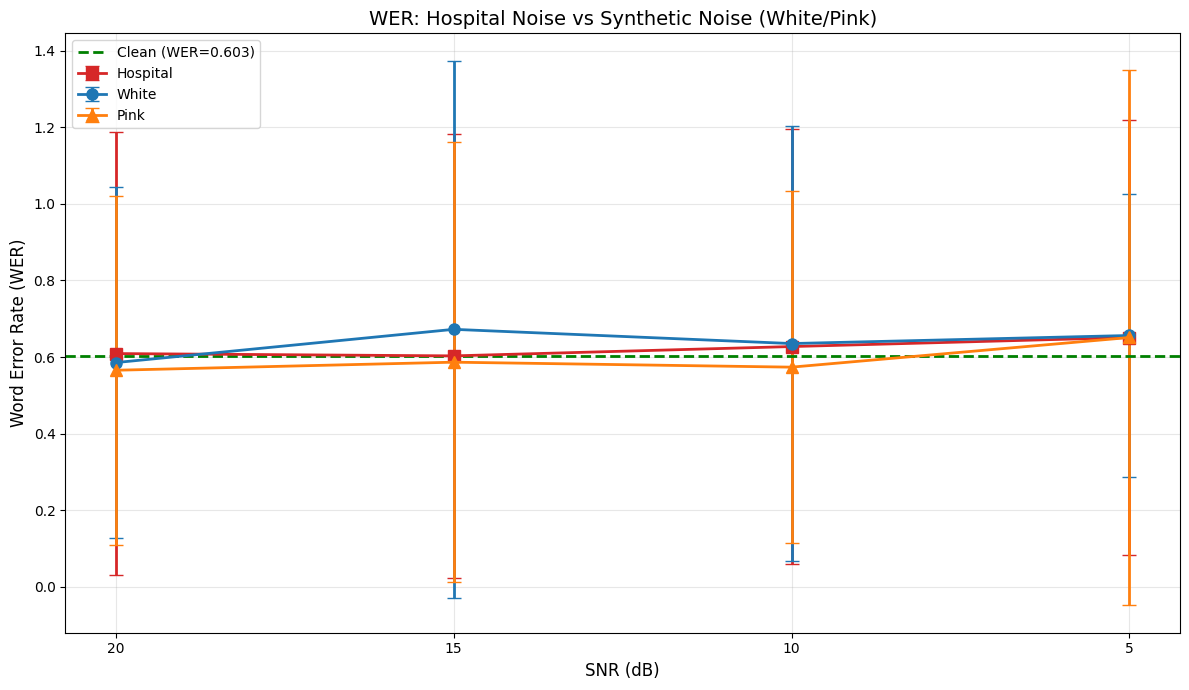

✓ График 1: WER сравнение


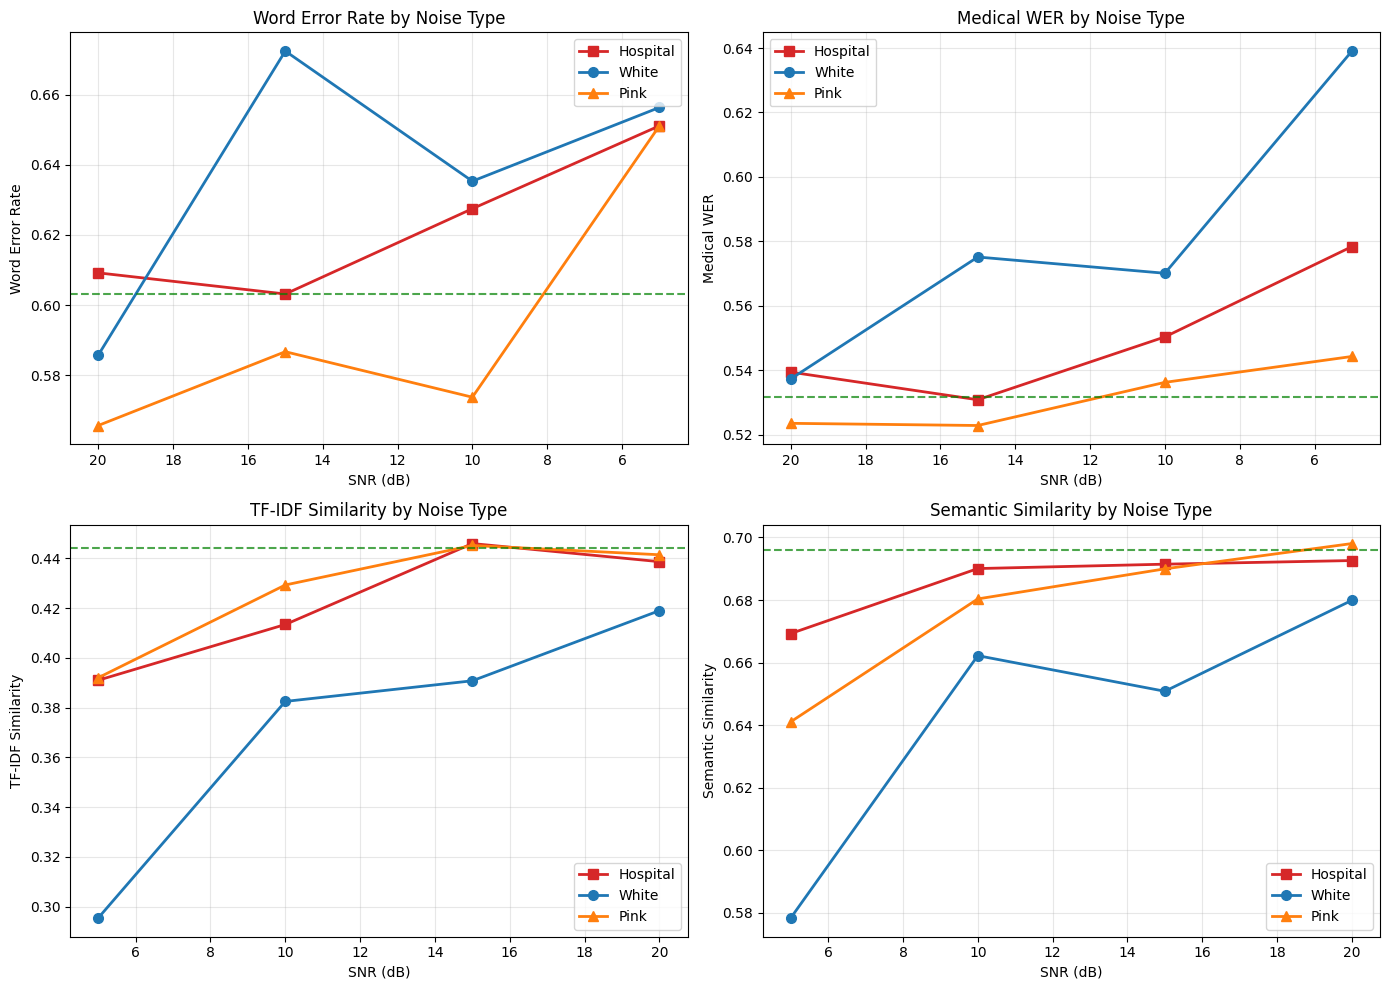

✓ График 2: Мульти-метрики


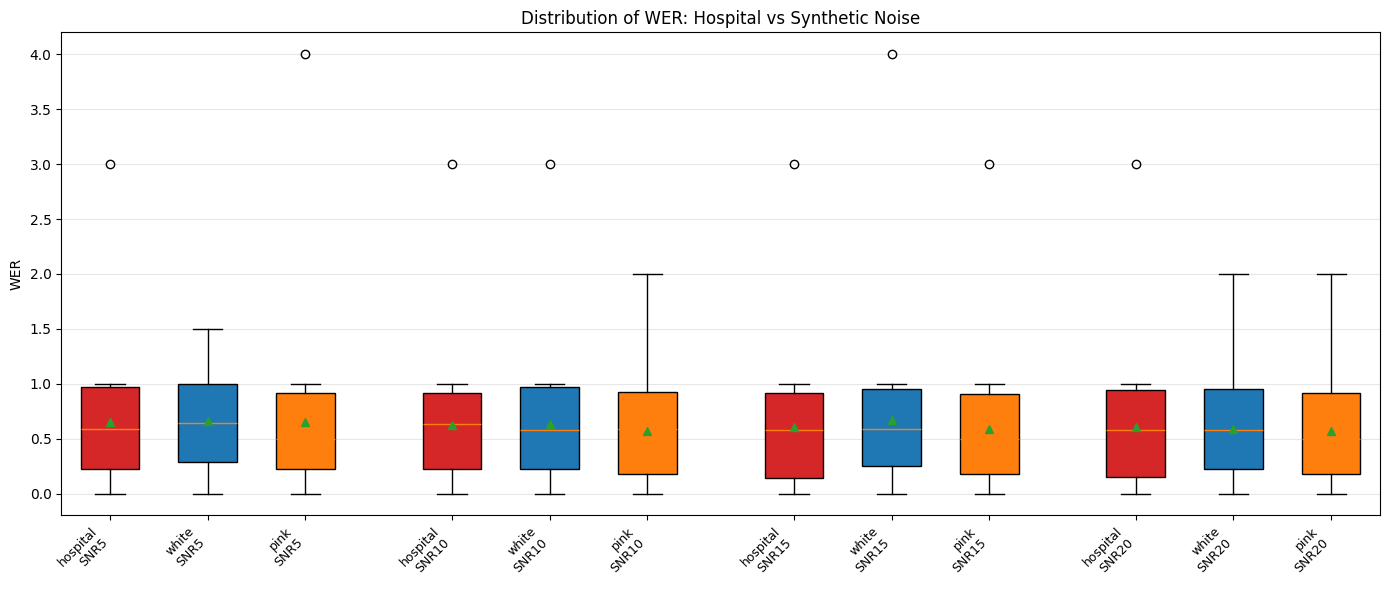

✓ График 3: Boxplot распределений


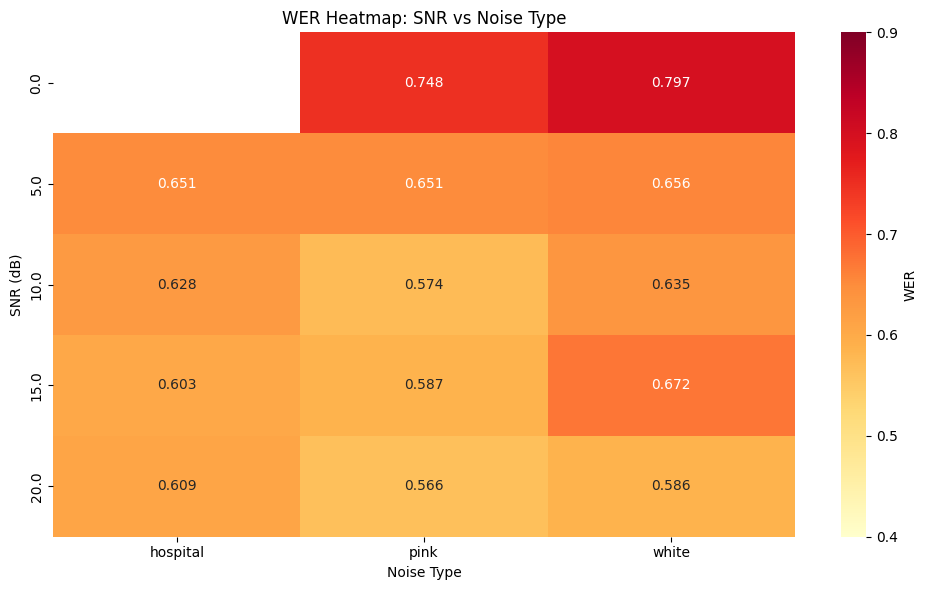

✓ График 4: Heatmap


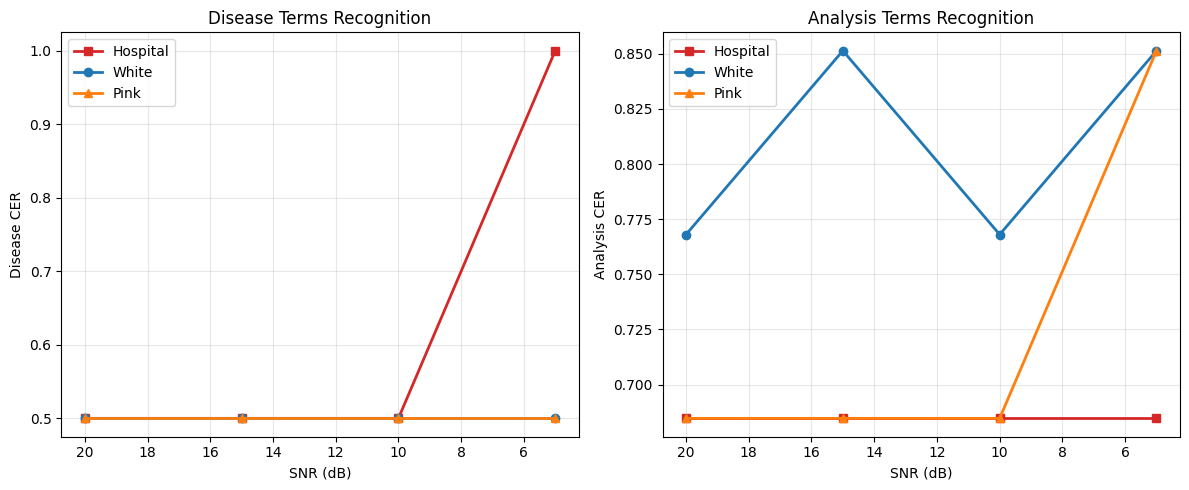

✓ График 5: Medical CER

✓ Все графики сохранены в /content/eval_work/results/plots


In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ: Hospital vs Синтетический шум
# ============================================

print("=== ВИЗУАЛИЗАЦИЯ ===\n")

# 1. Сравнение WER по типам шума
fig, ax = plt.subplots(figsize=(12, 7))

snr_levels = [5, 10, 15, 20]
noise_types = ['hospital', 'white', 'pink']
colors = {'hospital': '#d62728', 'white': '#1f77b4', 'pink': '#ff7f0e'}
markers = {'hospital': 's', 'white': 'o', 'pink': '^'}

for nt in noise_types:
    means = []
    stds = []
    for snr in snr_levels:
        data = noisy_data[(noisy_data['noise_type'] == nt) &
                         (noisy_data['snr_db'] == snr)]['whisper_wer'].dropna()
        means.append(data.mean() if len(data) > 0 else np.nan)
        stds.append(data.std() if len(data) > 0 else 0)

    ax.errorbar(snr_levels, means, yerr=stds,
                marker=markers[nt], label=nt.capitalize(),
                color=colors[nt], linewidth=2, capsize=5, markersize=8)

# Добавляем clean как горизонтальную линию
clean_wer = df_all[df_all['condition'] == 'clean']['whisper_wer'].mean()
ax.axhline(y=clean_wer, color='green', linestyle='--', linewidth=2,
           label=f'Clean (WER={clean_wer:.3f})')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Word Error Rate (WER)', fontsize=12)
ax.set_title('WER: Hospital Noise vs Synthetic Noise (White/Pink)', fontsize=14)
ax.set_xticks(snr_levels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hospital_vs_synthetic_wer.png"), dpi=300)
plt.show()
print("✓ График 1: WER сравнение")

# 2. Несколько метрик на одном графике (subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_plot = [
    ('whisper_wer', 'Word Error Rate'),
    ('whisper_mwer', 'Medical WER'),
    ('whisper_tfidf', 'TF-IDF Similarity'),
    ('whisper_semantic', 'Semantic Similarity')
]

for idx, (metric, title) in enumerate(metrics_plot):
    ax = axes[idx // 2, idx % 2]

    for nt in noise_types:
        means = []
        for snr in snr_levels:
            data = noisy_data[(noisy_data['noise_type'] == nt) &
                             (noisy_data['snr_db'] == snr)][metric].dropna()
            means.append(data.mean() if len(data) > 0 else np.nan)

        ax.plot(snr_levels, means, marker=markers[nt], label=nt.capitalize(),
                color=colors[nt], linewidth=2, markersize=7)

    # Добавляем clean
    clean_val = df_all[df_all['condition'] == 'clean'][metric].mean()
    ax.axhline(y=clean_val, color='green', linestyle='--', alpha=0.7)

    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Noise Type')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if 'Similarity' not in title:
        ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hospital_multi_metrics.png"), dpi=300)
plt.show()
print("✓ График 2: Мульти-метрики")

# 3. Boxplot сравнение распределений
fig, ax = plt.subplots(figsize=(14, 6))

# Подготовка данных для boxplot
box_data = []
labels = []
positions = []
pos = 1

for snr in snr_levels:
    for nt in noise_types:
        data = noisy_data[(noisy_data['noise_type'] == nt) &
                         (noisy_data['snr_db'] == snr)]['whisper_wer'].dropna()
        if len(data) > 0:
            box_data.append(data.values)
            labels.append(f'{nt}\nSNR{snr}')
            positions.append(pos)
            pos += 1
    pos += 0.5  # Пробел между SNR группами

bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                patch_artist=True, showmeans=True)

# Раскраска
for patch, label in zip(bp['boxes'], labels):
    if 'hospital' in label:
        patch.set_facecolor('#d62728')
    elif 'white' in label:
        patch.set_facecolor('#1f77b4')
    else:
        patch.set_facecolor('#ff7f0e')

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('WER')
ax.set_title('Distribution of WER: Hospital vs Synthetic Noise')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hospital_boxplot_wer.png"), dpi=300)
plt.show()
print("✓ График 3: Boxplot распределений")

# 4. Тепловая карта: SNR vs Noise Type
fig, ax = plt.subplots(figsize=(10, 6))

# Создаем сводную таблицу для heatmap
pivot_wer = noisy_data.pivot_table(
    values='whisper_wer',
    index='snr_db',
    columns='noise_type',
    aggfunc='mean'
)

sns.heatmap(pivot_wer, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'WER'}, ax=ax, vmin=0.4, vmax=0.9)
ax.set_title('WER Heatmap: SNR vs Noise Type')
ax.set_xlabel('Noise Type')
ax.set_ylabel('SNR (dB)')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hospital_heatmap_wer.png"), dpi=300)
plt.show()
print("✓ График 4: Heatmap")

# 5. Medical-specific метрики для hospital шума
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Disease CER
ax = axes[0]
for nt in ['hospital', 'white', 'pink']:
    means = []
    for snr in snr_levels:
        data = noisy_data[(noisy_data['noise_type'] == nt) &
                         (noisy_data['snr_db'] == snr)]['whisper_disease_cer'].dropna()
        means.append(data.mean() if len(data) > 0 else np.nan)

    ax.plot(snr_levels, means, marker=markers.get(nt, 'o'),
            label=nt.capitalize(), color=colors.get(nt, 'gray'), linewidth=2)

ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Disease CER')
ax.set_title('Disease Terms Recognition')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Analysis CER
ax = axes[1]
for nt in ['hospital', 'white', 'pink']:
    means = []
    for snr in snr_levels:
        data = noisy_data[(noisy_data['noise_type'] == nt) &
                         (noisy_data['snr_db'] == snr)]['whisper_analysis_cer'].dropna()
        means.append(data.mean() if len(data) > 0 else np.nan)

    ax.plot(snr_levels, means, marker=markers.get(nt, 'o'),
            label=nt.capitalize(), color=colors.get(nt, 'gray'), linewidth=2)

ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Analysis CER')
ax.set_title('Analysis Terms Recognition')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "hospital_medical_cer.png"), dpi=300)
plt.show()
print("✓ График 5: Medical CER")

print(f"\n✓ Все графики сохранены в {PLOTS_DIR}")

In [ ]:
# ============================================
# ЗАГРУЗКА ДАННЫХ ДЛЯ VOSK (только hospital шум)
# ============================================

print("=== ПОДГОТОВКА ДАННЫХ ДЛЯ VOSK ===\n")

# Берем только hospital шум + clean для сравнения
vosk_eval_data = {}

# Clean версии
for (id_part, variant), info in alice_data.items():
    vosk_eval_data[(id_part, variant, 'none', None)] = info['wav']

# Hospital шум (все SNR)
for (id_part, variant, noise_type, snr), path in alice_hospital_noisy.items():
    vosk_eval_data[(id_part, variant, noise_type, snr)] = path

print(f"Подготовлено {len(vosk_eval_data)} файлов для Vosk")
print(f"  - Clean: {sum(1 for k in vosk_eval_data.keys() if k[2] == 'none')}")
print(f"  - Hospital noise: {sum(1 for k in vosk_eval_data.keys() if k[2] == 'hospital')}")

=== ПОДГОТОВКА ДАННЫХ ДЛЯ VOSK ===

Подготовлено 165 файлов для Vosk
  - Clean: 33
  - Hospital noise: 132


In [ ]:
# ============================================
# ОЦЕНКА VOSK (только hospital шум)
# ============================================

def evaluate_vosk_only(audio_path, id_part, variant, noise_type, snr):
    """
    Оценивает аудио только через Vosk STT.
    """
    # Эталонный текст
    ref_text = get_ref_text(id_part, variant)
    ref_norm = normalize_text(ref_text)

    # Определяем условие
    if noise_type == 'none':
        condition = 'clean'
        snr_val = np.inf
    else:
        condition = f"{noise_type}_snr{snr}"
        snr_val = snr

    result = {
        'id': id_part,
        'variant': variant,
        'noise_type': noise_type if noise_type != 'none' else 'none',
        'snr_db': snr_val,
        'condition': condition,
        'audio_path': audio_path,
        'reference': ref_text,
        'reference_norm': ref_norm
    }

    # Vosk STT
    hyp_v = transcribe_vosk_fixed(audio_path)
    hyp_v_norm = normalize_text(hyp_v)

    result['vosk_hyp'] = hyp_v
    result['vosk_wer'] = metrics_calc.calculate_wer(ref_norm, hyp_v_norm)
    result['vosk_cer'] = metrics_calc.calculate_cer(ref_norm, hyp_v_norm)
    result['vosk_mwer'] = metrics_calc.calculate_mwer(ref_norm, hyp_v_norm)
    result['vosk_disease_cer'] = metrics_calc.calculate_disease_cer(ref_norm, hyp_v_norm)
    result['vosk_analysis_cer'] = metrics_calc.calculate_analysis_cer(ref_norm, hyp_v_norm)
    result['vosk_tfidf'] = metrics_calc.calculate_tfidf_cosine(ref_norm, hyp_v_norm)
    result['vosk_bleu'] = metrics_calc.calculate_bleu(ref_norm, hyp_v_norm)
    result['vosk_semantic'] = metrics_calc.calculate_semantic_similarity(ref_text, hyp_v)

    # Длительность
    try:
        audio, sr = sf.read(audio_path)
        result['duration_sec'] = len(audio) / sr
    except:
        result['duration_sec'] = None

    return result

# Проверяем доступность Vosk
if not VOSK_ASR_AVAILABLE:
    print("⚠️ Vosk ASR не доступен! Скачиваем модель...")
    !mkdir -p /content/models
    %cd /content/models
    !wget -q https://alphacephei.com/vosk/models/vosk-model-ru-0.42.zip
    !unzip -q vosk-model-ru-0.42.zip
    !mv vosk-model-ru-0.42 vosk-model-ru
    %cd /content

    try:
        from vosk import Model as VoskModel, KaldiRecognizer, SetLogLevel
        SetLogLevel(-1)
        vosk_asr_model = VoskModel("/content/models/vosk-model-ru")
        VOSK_ASR_AVAILABLE = True
        print("✓ Vosk ASR загружен")
    except Exception as e:
        print(f"✗ Не удалось загрузить Vosk: {e}")
        raise RuntimeError("Vosk ASR необходим для этого блока")

# Оценка
print("\n=== ОЦЕНКА VOSK (Hospital Noise Only) ===\n")

vosk_results = []

for (id_part, variant, noise_type, snr), audio_path in tqdm(vosk_eval_data.items()):
    result = evaluate_vosk_only(audio_path, id_part, variant, noise_type, snr)
    vosk_results.append(result)

# DataFrame
df_vosk = pd.DataFrame(vosk_results)
df_vosk.to_csv(os.path.join(RESULTS_DIR, "vosk_hospital_results.csv"),
               index=False, encoding='utf-8-sig')

print(f"\n✓ Оценено {len(df_vosk)} записей Vosk")
print(f"Колонки: {list(df_vosk.columns)}")


=== ОЦЕНКА VOSK (Hospital Noise Only) ===



100%|██████████| 165/165 [09:02<00:00,  3.29s/it]


✓ Оценено 165 записей Vosk
Колонки: ['id', 'variant', 'noise_type', 'snr_db', 'condition', 'audio_path', 'reference', 'reference_norm', 'vosk_hyp', 'vosk_wer', 'vosk_cer', 'vosk_mwer', 'vosk_disease_cer', 'vosk_analysis_cer', 'vosk_tfidf', 'vosk_bleu', 'vosk_semantic', 'duration_sec']


In [ ]:
# ============================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ VOSK
# ============================================

print("=== СТАТИСТИЧЕСКИЙ АНАЛИЗ VOSK ===\n")

# 1. Описательная статистика
print("1. Описательная статистика (Vosk):")
vosk_metrics = ['vosk_wer', 'vosk_cer', 'vosk_mwer', 'vosk_disease_cer',
                'vosk_analysis_cer', 'vosk_tfidf', 'vosk_bleu', 'vosk_semantic']

desc_vosk = df_vosk[vosk_metrics].describe().round(4)
print(desc_vosk)

# 2. Влияние SNR (только hospital шум)
print("\n2. Влияние SNR на метрики Vosk (только hospital):")
hospital_vosk = df_vosk[df_vosk['noise_type'] == 'hospital']

for metric in ['vosk_wer', 'vosk_mwer', 'vosk_tfidf', 'vosk_semantic']:
    valid_data = hospital_vosk[['snr_db', metric]].dropna()
    if len(valid_data) > 1:
        corr, p = spearmanr(valid_data['snr_db'], valid_data[metric])
        print(f"   {metric}: ρ = {corr:.3f}, p = {p:.4f} (n={len(valid_data)})")

# 3. Сравнение с clean
print("\n3. Сравнение Hospital vs Clean (Vosk):")
clean_vosk = df_vosk[df_vosk['condition'] == 'clean']
hospital_by_snr = df_vosk[df_vosk['noise_type'] == 'hospital'].groupby('snr_db')

clean_wer = clean_vosk['vosk_wer'].mean()
print(f"   Clean WER: {clean_wer:.4f}")

for snr, group in hospital_by_snr:
    hosp_wer = group['vosk_wer'].mean()
    change = ((hosp_wer - clean_wer) / clean_wer * 100)
    print(f"   SNR {snr}dB WER: {hosp_wer:.4f} (+{change:.1f}%)")

# Сохраняем
desc_vosk.to_csv(os.path.join(RESULTS_DIR, "vosk_descriptive_stats.csv"))
print("\n✓ Статистика Vosk сохранена")

=== СТАТИСТИЧЕСКИЙ АНАЛИЗ VOSK ===

1. Описательная статистика (Vosk):
       vosk_wer  vosk_cer  vosk_mwer  vosk_disease_cer  vosk_analysis_cer  \
count  165.0000  165.0000   165.0000            10.000            60.0000   
mean     0.5192    0.4142     0.4782             0.500             0.3514   
std      0.4491    0.3836     0.4157             0.527             0.4663   
min      0.0000    0.0000     0.0000             0.000             0.0000   
25%      0.0476    0.0076     0.0000             0.000             0.0000   
50%      0.6400    0.4348     0.5385             0.500             0.0000   
75%      0.9167    0.8369     0.9032             1.000             1.0000   
max      2.0000    0.9562     1.0000             1.000             1.0000   

       vosk_tfidf  vosk_bleu  vosk_semantic  
count    165.0000   165.0000       165.0000  
mean       0.5025     0.4561         0.7046  
std        0.3896     0.4435         0.2658  
min        0.0000     0.0000         0.2066  
25%  

In [ ]:
# ============================================
# СРАВНЕНИЕ WHISPER vs VOSK (Hospital Noise)
# ============================================

print("=== СРАВНЕНИЕ WHISPER vs VOSK ===\n")

# Объединяем данные для сравнения
# Берем только hospital шум из обоих датафреймов
whisper_hosp = df_all[df_all['noise_type'] == 'hospital'][['id', 'variant', 'snr_db',
                                                            'whisper_wer', 'whisper_mwer',
                                                            'whisper_tfidf', 'whisper_semantic']].copy()

vosk_hosp = df_vosk[df_vosk['noise_type'] == 'hospital'][['id', 'variant', 'snr_db',
                                                          'vosk_wer', 'vosk_mwer',
                                                          'vosk_tfidf', 'vosk_semantic']].copy()

# Мержим по id, variant, snr_db
comparison_df = pd.merge(whisper_hosp, vosk_hosp,
                        on=['id', 'variant', 'snr_db'],
                        how='inner')

print(f"Сопоставлено {len(comparison_df)} записей для прямого сравнения")

# Статистические тесты
print("\nСравнение по метрикам (Mann-Whitney U):")

metrics_compare = [
    ('whisper_wer', 'vosk_wer', 'WER'),
    ('whisper_mwer', 'vosk_mwer', 'mWER'),
    ('whisper_tfidf', 'vosk_tfidf', 'TF-IDF'),
    ('whisper_semantic', 'vosk_semantic', 'Semantic')
]

for w_col, v_col, name in metrics_compare:
    w_data = comparison_df[w_col].dropna()
    v_data = comparison_df[v_col].dropna()

    if len(w_data) > 0 and len(v_data) > 0:
        stat, p = mannwhitneyu(w_data, v_data)
        print(f"   {name}:")
        print(f"      Whisper: {w_data.mean():.4f} ± {w_data.std():.4f}")
        print(f"      Vosk:    {v_data.mean():.4f} ± {v_data.std():.4f}")
        print(f"      p = {p:.4f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''}")

# По SNR
print("\nСравнение по SNR уровням (WER):")
for snr in [5, 10, 15, 20]:
    subset = comparison_df[comparison_df['snr_db'] == snr]
    if len(subset) > 0:
        w_wer = subset['whisper_wer'].mean()
        v_wer = subset['vosk_wer'].mean()
        print(f"   SNR {snr}dB: Whisper={w_wer:.3f}, Vosk={v_wer:.3f}, Δ={w_wer-v_wer:+.3f}")

comparison_df.to_csv(os.path.join(RESULTS_DIR, "whisper_vs_vosk_comparison.csv"), index=False)

=== СРАВНЕНИЕ WHISPER vs VOSK ===

Сопоставлено 132 записей для прямого сравнения

Сравнение по метрикам (Mann-Whitney U):
   WER:
      Whisper: 0.6228 ± 0.5672
      Vosk:    0.5232 ± 0.4506
      p = 0.0925 
   mWER:
      Whisper: 0.5497 ± 0.3917
      Vosk:    0.4790 ± 0.4154
      p = 0.0437 *
   TF-IDF:
      Whisper: 0.4222 ± 0.3521
      Vosk:    0.5003 ± 0.3871
      p = 0.0581 
   Semantic:
      Whisper: 0.6859 ± 0.2945
      Vosk:    0.7048 ± 0.2660
      p = 0.6899 

Сравнение по SNR уровням (WER):
   SNR 5dB: Whisper=0.651, Vosk=0.579, Δ=+0.072
   SNR 10dB: Whisper=0.628, Vosk=0.515, Δ=+0.112
   SNR 15dB: Whisper=0.603, Vosk=0.502, Δ=+0.101
   SNR 20dB: Whisper=0.609, Vosk=0.497, Δ=+0.112


=== ВИЗУАЛИЗАЦИЯ VOSK ===



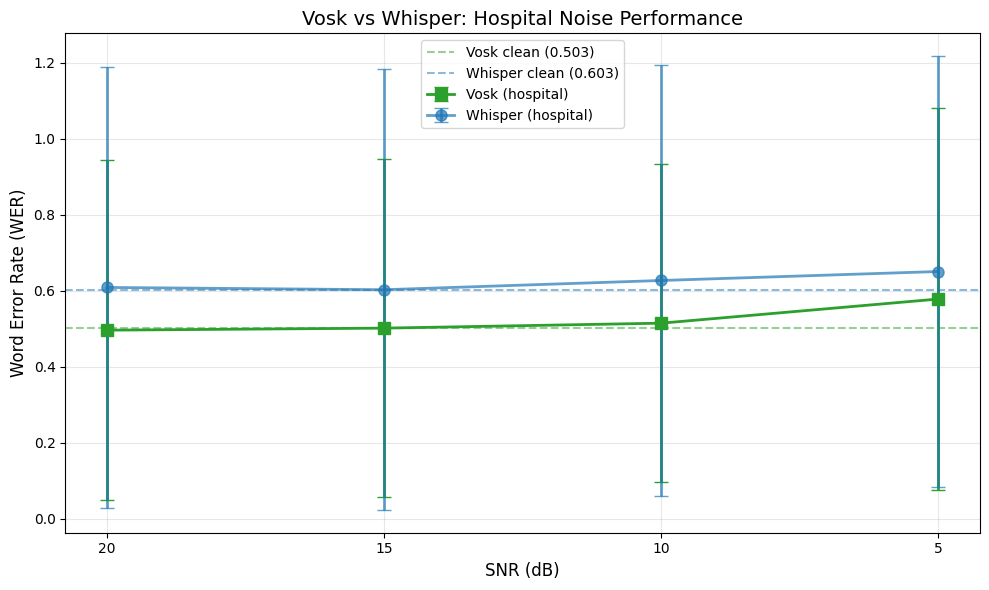

✓ График 1: Vosk vs Whisper WER


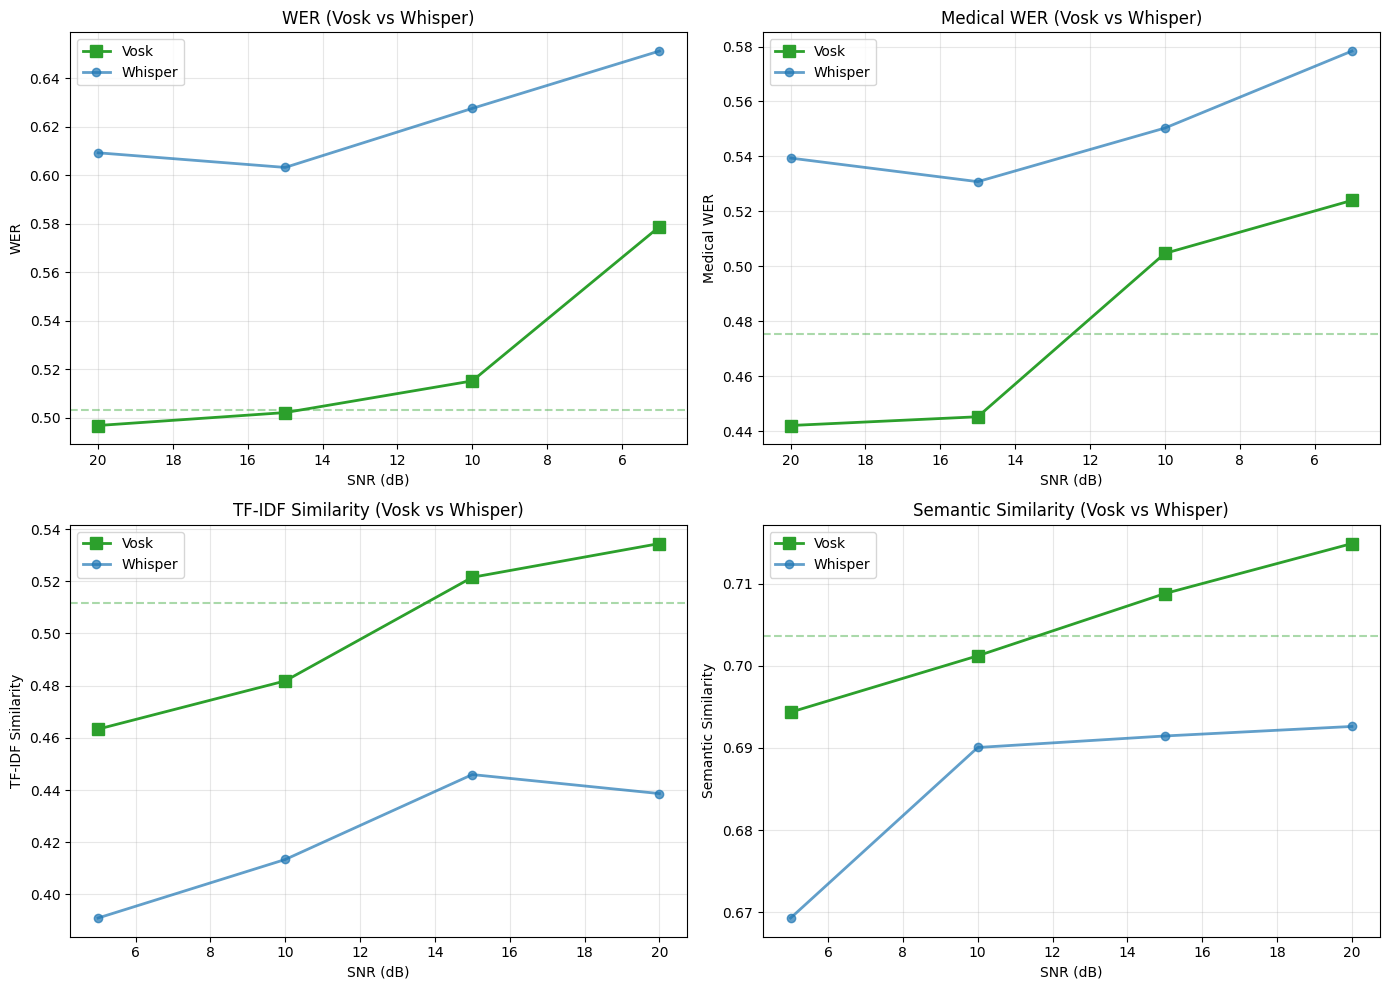

✓ График 2: Vosk multi-metrics


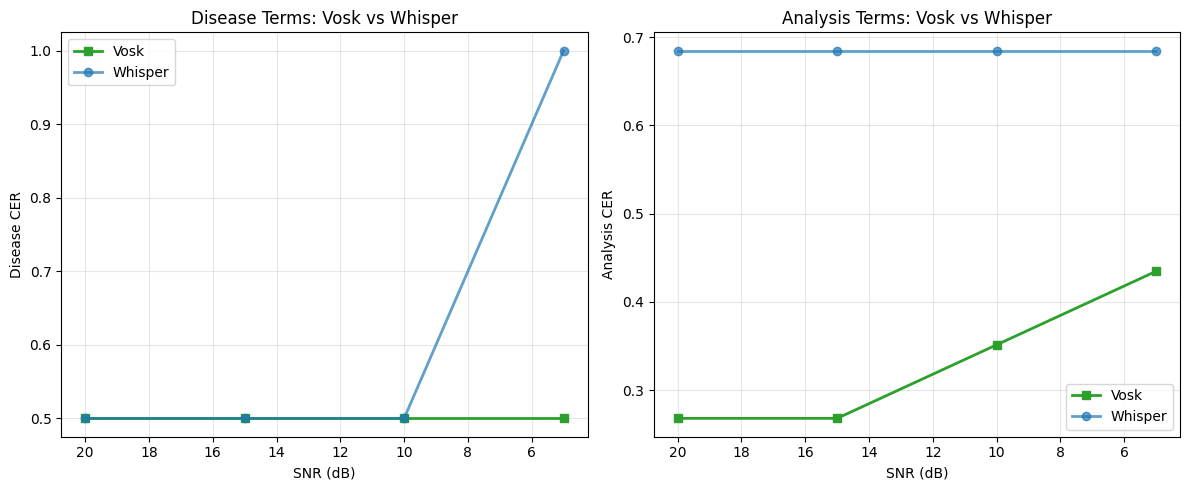

✓ График 3: Medical CER comparison

✓ Все графики Vosk сохранены в /content/eval_work/results/plots


In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ VOSK + СРАВНЕНИЕ
# ============================================

print("=== ВИЗУАЛИЗАЦИЯ VOSK ===\n")

# 1. Vosk WER по SNR (hospital only)
fig, ax = plt.subplots(figsize=(10, 6))

snr_levels = [5, 10, 15, 20]

# Vosk hospital
vosk_means = [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                      (df_vosk['snr_db'] == s)]['vosk_wer'].mean()
              for s in snr_levels]
vosk_stds = [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                     (df_vosk['snr_db'] == s)]['vosk_wer'].std()
             for s in snr_levels]

ax.errorbar(snr_levels, vosk_means, yerr=vosk_stds,
            marker='s', label='Vosk (hospital)',
            color='#2ca02c', linewidth=2, capsize=5, markersize=8)

# Whisper hospital для сравнения
whisper_means = [df_all[(df_all['noise_type'] == 'hospital') &
                        (df_all['snr_db'] == s)]['whisper_wer'].mean()
                 for s in snr_levels]
whisper_stds = [df_all[(df_all['noise_type'] == 'hospital') &
                       (df_all['snr_db'] == s)]['whisper_wer'].std()
                for s in snr_levels]

ax.errorbar(snr_levels, whisper_means, yerr=whisper_stds,
            marker='o', label='Whisper (hospital)',
            color='#1f77b4', linewidth=2, capsize=5, markersize=8, alpha=0.7)

# Clean baseline
clean_vosk = df_vosk[df_vosk['condition'] == 'clean']['vosk_wer'].mean()
clean_whisper = df_all[df_all['condition'] == 'clean']['whisper_wer'].mean()
ax.axhline(y=clean_vosk, color='#2ca02c', linestyle='--', alpha=0.5, label=f'Vosk clean ({clean_vosk:.3f})')
ax.axhline(y=clean_whisper, color='#1f77b4', linestyle='--', alpha=0.5, label=f'Whisper clean ({clean_whisper:.3f})')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Word Error Rate (WER)', fontsize=12)
ax.set_title('Vosk vs Whisper: Hospital Noise Performance', fontsize=14)
ax.set_xticks(snr_levels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "vosk_vs_whisper_wer.png"), dpi=300)
plt.show()
print("✓ График 1: Vosk vs Whisper WER")

# 2. Мульти-метрики для Vosk
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

vosk_metrics_plot = [
    ('vosk_wer', 'WER'),
    ('vosk_mwer', 'Medical WER'),
    ('vosk_tfidf', 'TF-IDF Similarity'),
    ('vosk_semantic', 'Semantic Similarity')
]

for idx, (metric, title) in enumerate(vosk_metrics_plot):
    ax = axes[idx // 2, idx % 2]

    # Vosk hospital
    means = [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                     (df_vosk['snr_db'] == s)][metric].mean()
             for s in snr_levels]

    ax.plot(snr_levels, means, marker='s', label='Vosk',
            color='#2ca02c', linewidth=2, markersize=8)

    # Whisper для сравнения
    w_metric = metric.replace('vosk_', 'whisper_')
    if w_metric in df_all.columns:
        w_means = [df_all[(df_all['noise_type'] == 'hospital') &
                          (df_all['snr_db'] == s)][w_metric].mean()
                   for s in snr_levels]
        ax.plot(snr_levels, w_means, marker='o', label='Whisper',
                color='#1f77b4', linewidth=2, markersize=6, alpha=0.7)

    # Clean baseline
    clean_val = df_vosk[df_vosk['condition'] == 'clean'][metric].mean()
    ax.axhline(y=clean_val, color='#2ca02c', linestyle='--', alpha=0.4)

    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} (Vosk vs Whisper)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if 'Similarity' not in title:
        ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "vosk_multi_metrics.png"), dpi=300)
plt.show()
print("✓ График 2: Vosk multi-metrics")

# 3. Medical-specific сравнение
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Disease CER
ax = axes[0]
v_disease = [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                     (df_vosk['snr_db'] == s)]['vosk_disease_cer'].mean()
             for s in snr_levels]
w_disease = [df_all[(df_all['noise_type'] == 'hospital') &
                    (df_all['snr_db'] == s)]['whisper_disease_cer'].mean()
             for s in snr_levels]

ax.plot(snr_levels, v_disease, marker='s', label='Vosk', color='#2ca02c', linewidth=2)
ax.plot(snr_levels, w_disease, marker='o', label='Whisper', color='#1f77b4', linewidth=2, alpha=0.7)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Disease CER')
ax.set_title('Disease Terms: Vosk vs Whisper')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Analysis CER
ax = axes[1]
v_analysis = [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                     (df_vosk['snr_db'] == s)]['vosk_analysis_cer'].mean()
              for s in snr_levels]
w_analysis = [df_all[(df_all['noise_type'] == 'hospital') &
                     (df_all['snr_db'] == s)]['whisper_analysis_cer'].mean()
              for s in snr_levels]

ax.plot(snr_levels, v_analysis, marker='s', label='Vosk', color='#2ca02c', linewidth=2)
ax.plot(snr_levels, w_analysis, marker='o', label='Whisper', color='#1f77b4', linewidth=2, alpha=0.7)
ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Analysis CER')
ax.set_title('Analysis Terms: Vosk vs Whisper')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "vosk_vs_whisper_medical_cer.png"), dpi=300)
plt.show()
print("✓ График 3: Medical CER comparison")

print(f"\n✓ Все графики Vosk сохранены в {PLOTS_DIR}")

In [ ]:
# ============================================
# ИТОГОВАЯ СВОДКА VOSK
# ============================================

print("=== ИТОГОВАЯ СВОДКА VOSK ===\n")

print("Сравнение с Whisper (Hospital Noise):")
print("-" * 50)

# Сводная таблица
summary_comparison = pd.DataFrame({
    'SNR (dB)': [5, 10, 15, 20],
    'Vosk WER': [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                         (df_vosk['snr_db'] == s)]['vosk_wer'].mean() for s in [5, 10, 15, 20]],
    'Whisper WER': [df_all[(df_all['noise_type'] == 'hospital') &
                           (df_all['snr_db'] == s)]['whisper_wer'].mean() for s in [5, 10, 15, 20]],
    'Vosk mWER': [df_vosk[(df_vosk['noise_type'] == 'hospital') &
                          (df_vosk['snr_db'] == s)]['vosk_mwer'].mean() for s in [5, 10, 15, 20]],
    'Whisper mWER': [df_all[(df_all['noise_type'] == 'hospital') &
                            (df_all['snr_db'] == s)]['whisper_mwer'].mean() for s in [5, 10, 15, 20]]
}).round(4)

print(summary_comparison.to_string(index=False))

# Clean baseline
print(f"\nClean (без шума):")
print(f"  Vosk WER: {df_vosk[df_vosk['condition'] == 'clean']['vosk_wer'].mean():.4f}")
print(f"  Whisper WER: {df_all[df_all['condition'] == 'clean']['whisper_wer'].mean():.4f}")

=== ИТОГОВАЯ СВОДКА VOSK ===

Сравнение с Whisper (Hospital Noise):
--------------------------------------------------
 SNR (dB)  Vosk WER  Whisper WER  Vosk mWER  Whisper mWER
        5    0.5787       0.6511     0.5240        0.5784
       10    0.5152       0.6275     0.5047        0.5503
       15    0.5021       0.6032     0.4452        0.5308
       20    0.4968       0.6092     0.4420        0.5394

Clean (без шума):
  Vosk WER: 0.5031
  Whisper WER: 0.6031


# Статистический анализ TTS системы (Алиса) с помощью ASR

In [ ]:
# ============================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================

def get_ref_text(id_part, variant):
    """Получает эталонный текст из Excel по ID и варианту"""
    if id_part not in refs:
        return ""

    ref_data = refs[id_part]
    texts = {
        '1': ref_data.get('short', ''),
        '2': ref_data.get('reference_utterance', ''),
        '3': ref_data.get('context_text', '')
    }
    return texts.get(str(variant), '')

def normalize_text(text):
    """Нормализация текста для сравнения"""
    if not text:
        return ""

    text = str(text).lower()
    text = re.sub(r'[—–\-]', ' ', text)
    text = re.sub(r'[.,;:!?«»"\'"()\[\]]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def transcribe_whisper_fixed(audio_path):
    """Распознает через Whisper (использует глобальную модель)"""
    try:
        segments, _ = whisper_model.transcribe(
            audio_path,
            beam_size=5,
            vad_filter=True,
            language="ru"
        )
        return "".join([s.text for s in segments]).strip()
    except Exception as e:
        print(f"Whisper error: {e}")
        return ""

# Проверяем функции
print("Проверка функций:")
test_id = list(refs.keys())[0] if refs else None
if test_id:
    print(f"ID {test_id}, variant 1: {get_ref_text(test_id, '1')[:50]}...")

# ============================================
# ОЦЕНКА С МЕДИЦИНСКИМИ МЕТРИКАМИ (только Whisper)
# ============================================

def evaluate_with_medical_metrics(audio_path, id_part, variant, noise_type, snr):
    """
    Оценивает аудио с расширенными медицинскими метриками (только Whisper).
    """
    # Эталонный текст
    ref_text = get_ref_text(id_part, variant)
    ref_norm = normalize_text(ref_text)

    # Определяем условие
    if noise_type == 'clean':
        condition = 'clean'
        snr_val = np.inf
    else:
        condition = f"{noise_type}_snr{snr}"
        snr_val = snr

    result = {
        'id': id_part,
        'variant': variant,
        'noise_type': noise_type if noise_type != 'clean' else 'none',
        'snr_db': snr_val,
        'condition': condition,
        'audio_path': audio_path,
        'reference': ref_text,
        'reference_norm': ref_norm
    }

    # Whisper
    hyp_w = transcribe_whisper_fixed(audio_path)
    hyp_w_norm = normalize_text(hyp_w)

    result['whisper_hyp'] = hyp_w
    result['whisper_wer'] = metrics_calc.calculate_wer(ref_norm, hyp_w_norm)
    result['whisper_cer'] = metrics_calc.calculate_cer(ref_norm, hyp_w_norm)
    result['whisper_mwer'] = metrics_calc.calculate_mwer(ref_norm, hyp_w_norm)
    result['whisper_disease_cer'] = metrics_calc.calculate_disease_cer(ref_norm, hyp_w_norm)
    result['whisper_analysis_cer'] = metrics_calc.calculate_analysis_cer(ref_norm, hyp_w_norm)
    result['whisper_tfidf'] = metrics_calc.calculate_tfidf_cosine(ref_norm, hyp_w_norm)
    result['whisper_bleu'] = metrics_calc.calculate_bleu(ref_norm, hyp_w_norm)
    result['whisper_semantic'] = metrics_calc.calculate_semantic_similarity(ref_text, hyp_w)

    # Длительность
    try:
        audio, sr = sf.read(audio_path)
        result['duration_sec'] = len(audio) / sr
    except:
        result['duration_sec'] = None

    return result

# Оценка всех записей
print("\n=== ОЦЕНКА ЗАПИСЕЙ С МЕДИЦИНСКИМИ МЕТРИКАМИ (Whisper only) ===\n")

all_results = []

for (id_part, variant, noise_type, snr), audio_path in tqdm(alice_noisy.items()):
    result = evaluate_with_medical_metrics(audio_path, id_part, variant, noise_type, snr)
    all_results.append(result)

# DataFrame
df_results = pd.DataFrame(all_results)
df_results.to_csv(os.path.join(RESULTS_DIR, "detailed_results_medical.csv"),
                  index=False, encoding='utf-8-sig')

print(f"\n✓ Оценено {len(df_results)} записей")
print(f"Колонки: {list(df_results.columns)}")

Проверка функций:
ID 07-143, variant 1: Anti-HAV, антитела...

=== ОЦЕНКА ЗАПИСЕЙ С МЕДИЦИНСКИМИ МЕТРИКАМИ (Whisper only) ===



100%|██████████| 363/363 [1:43:41<00:00, 17.14s/it]


✓ Оценено 363 записей
Колонки: ['id', 'variant', 'noise_type', 'snr_db', 'condition', 'audio_path', 'reference', 'reference_norm', 'whisper_hyp', 'whisper_wer', 'whisper_cer', 'whisper_mwer', 'whisper_disease_cer', 'whisper_analysis_cer', 'whisper_tfidf', 'whisper_bleu', 'whisper_semantic', 'duration_sec']


In [ ]:
# ============================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ МЕДИЦИНСКИХ МЕТРИК
# ============================================

print("=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ===\n")

# 1. Описательная статистика по всем метрикам
print("1. Описательная статистика (Whisper):")
metrics_cols = ['whisper_wer', 'whisper_cer', 'whisper_mwer',
                'whisper_disease_cer', 'whisper_analysis_cer',
                'whisper_tfidf', 'whisper_bleu', 'whisper_semantic']

desc_stats = df_results[metrics_cols].describe().round(4)
print(desc_stats)

# 2. Влияние SNR на медицинские метрики (ИСПРАВЛЕНО)
print("\n2. Влияние SNR на медицинские метрики:")
snr_data = df_results[df_results['snr_db'] != np.inf].copy()

for metric in ['whisper_mwer', 'whisper_disease_cer', 'whisper_analysis_cer']:
    # Удаляем пропуски СИНХРОННО для обоих столбцов
    valid_data = snr_data[['snr_db', metric]].dropna()

    if len(valid_data) > 1:
        corr, p = spearmanr(valid_data['snr_db'], valid_data[metric])
        print(f"   {metric}: ρ = {corr:.3f}, p = {p:.4f} (n={len(valid_data)})")
    else:
        print(f"   {metric}: недостаточно данных")

# 3. Сравнение типов шума для медицинских терминов (ИСПРАВЛЕНО)
print("\n3. Сравнение типов шума (Mann-Whitney U) для mWER:")
for snr in SNR_LEVELS:
    # Получаем данные для этого SNR
    snr_subset = snr_data[snr_data['snr_db'] == snr]

    white = snr_subset[snr_subset['noise_type'] == 'white']['whisper_mwer'].dropna()
    pink = snr_subset[snr_subset['noise_type'] == 'pink']['whisper_mwer'].dropna()

    if len(white) > 0 and len(pink) > 0:
        stat, p = mannwhitneyu(white, pink)
        print(f"   SNR {snr}dB: white={white.mean():.3f} (n={len(white)}), "
              f"pink={pink.mean():.3f} (n={len(pink)}), p={p:.4f}")
    else:
        print(f"   SNR {snr}dB: недостаточно данных "
              f"(white={len(white)}, pink={len(pink)})")

# 4. Сравнение Disease CER vs Analysis CER (ИСПРАВЛЕНО)
print("\n4. Сравнение Disease CER vs Analysis CER:")
# Берем только строки где ОБЕ метрики не null
valid_both = df_results[['whisper_disease_cer', 'whisper_analysis_cer']].dropna()

if len(valid_both) > 0:
    d_cer = valid_both['whisper_disease_cer']
    a_cer = valid_both['whisper_analysis_cer']

    stat, p = mannwhitneyu(d_cer, a_cer)
    print(f"   Disease CER: {d_cer.mean():.4f} ± {d_cer.std():.4f} (n={len(d_cer)})")
    print(f"   Analysis CER: {a_cer.mean():.4f} ± {a_cer.std():.4f} (n={len(a_cer)})")
    print(f"   Mann-Whitney U: p = {p:.4f}")
else:
    print("   Недостаточно данных для сравнения")

# 5. Сводка по условиям (только для существующих)
print("\n5. Сводка по условиям:")
# Группируем и считаем средние только для числовых колонок
numeric_cols = df_results.select_dtypes(include=[np.number]).columns
summary_table = df_results.groupby('condition')[numeric_cols].mean().round(4)

# Выводим только ключевые метрики
key_metrics = [c for c in metrics_cols if c in summary_table.columns]
print(summary_table[key_metrics].head(10))

# Сохраняем
summary_table.to_csv(os.path.join(RESULTS_DIR, "medical_metrics_summary.csv"))
desc_stats.to_csv(os.path.join(RESULTS_DIR, "descriptive_statistics.csv"))

print("\n✓ Статистика сохранена")

=== СТАТИСТИЧЕСКИЙ АНАЛИЗ ===

1. Описательная статистика (Whisper):
       whisper_wer  whisper_cer  whisper_mwer  whisper_disease_cer  \
count     363.0000     363.0000      363.0000              22.0000   
mean        0.6432       0.4336        0.5784               0.5909   
std         0.5557       0.3705        0.3724               0.5032   
min         0.0000       0.0000        0.0000               0.0000   
25%         0.2440       0.0690        0.2500               0.0000   
50%         0.5882       0.4091        0.5385               1.0000   
75%         0.9559       0.8440        0.9615               1.0000   
max         4.0000       1.0000        1.0000               1.0000   

       whisper_analysis_cer  whisper_tfidf  whisper_bleu  whisper_semantic  
count              132.0000       363.0000      363.0000          362.0000  
mean                 0.7832         0.3755        0.3603            0.6358  
std                  0.3960         0.3312        0.3759            0

=== ВИЗУАЛИЗАЦИЯ ===



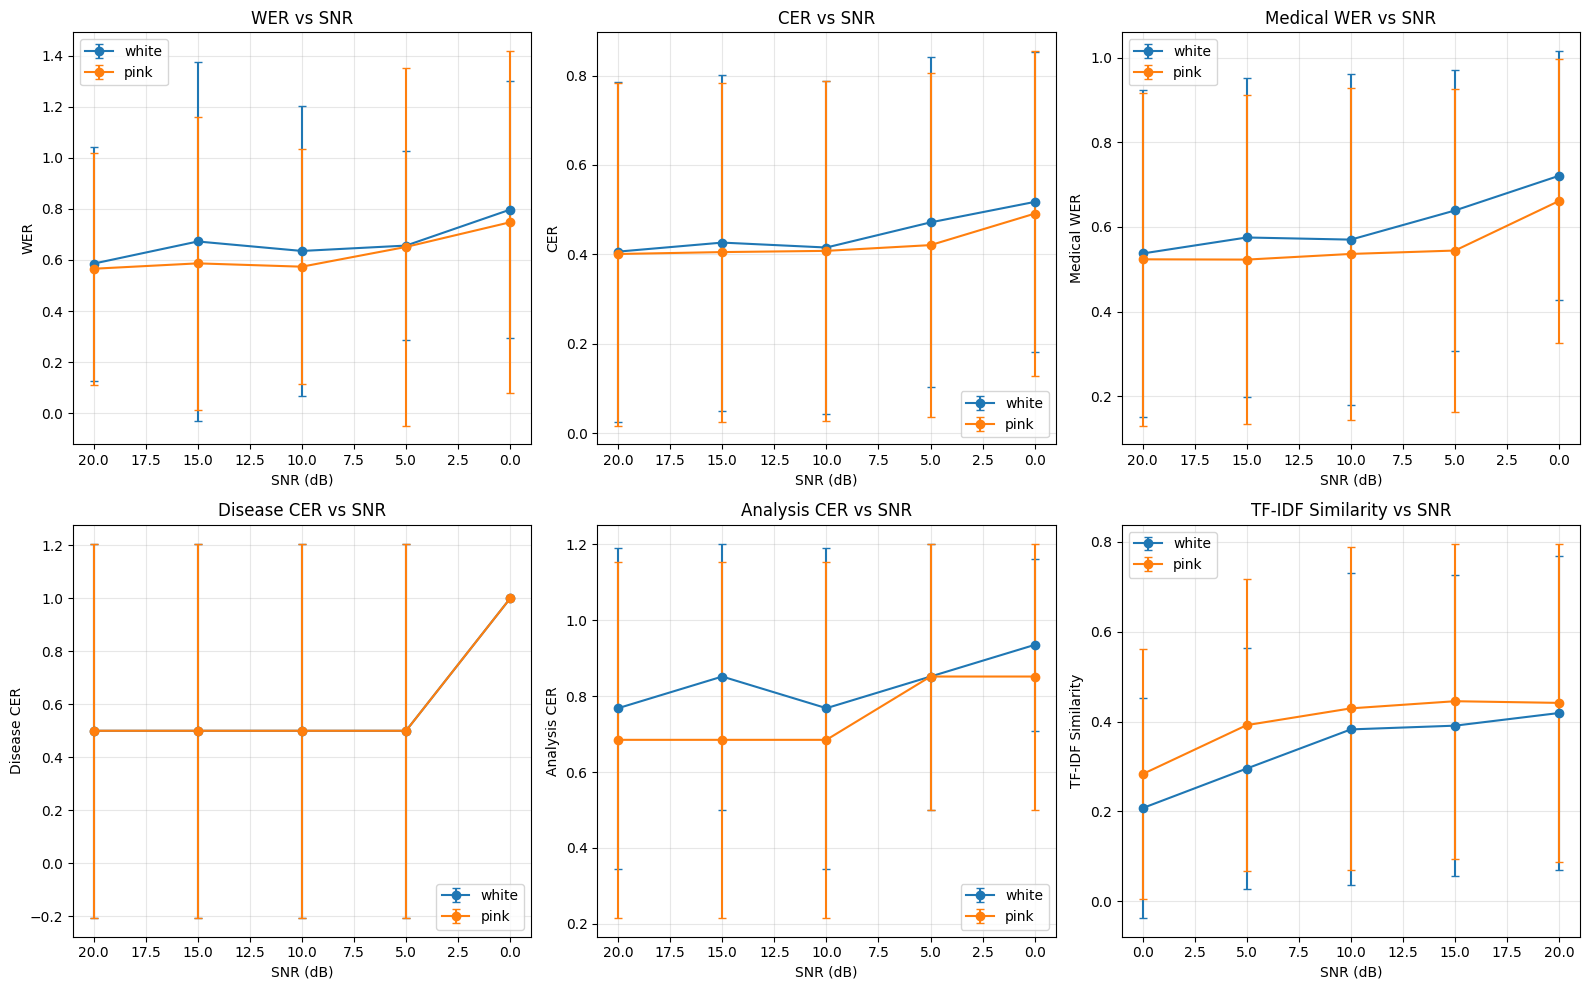

✓ График 1: Медицинские метрики по SNR


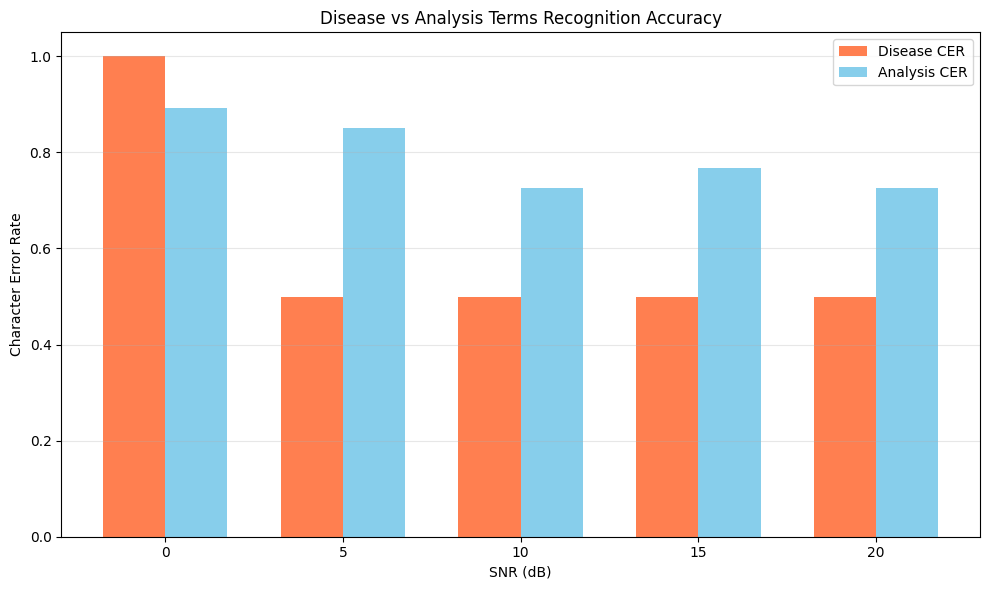

✓ График 2: Disease vs Analysis CER


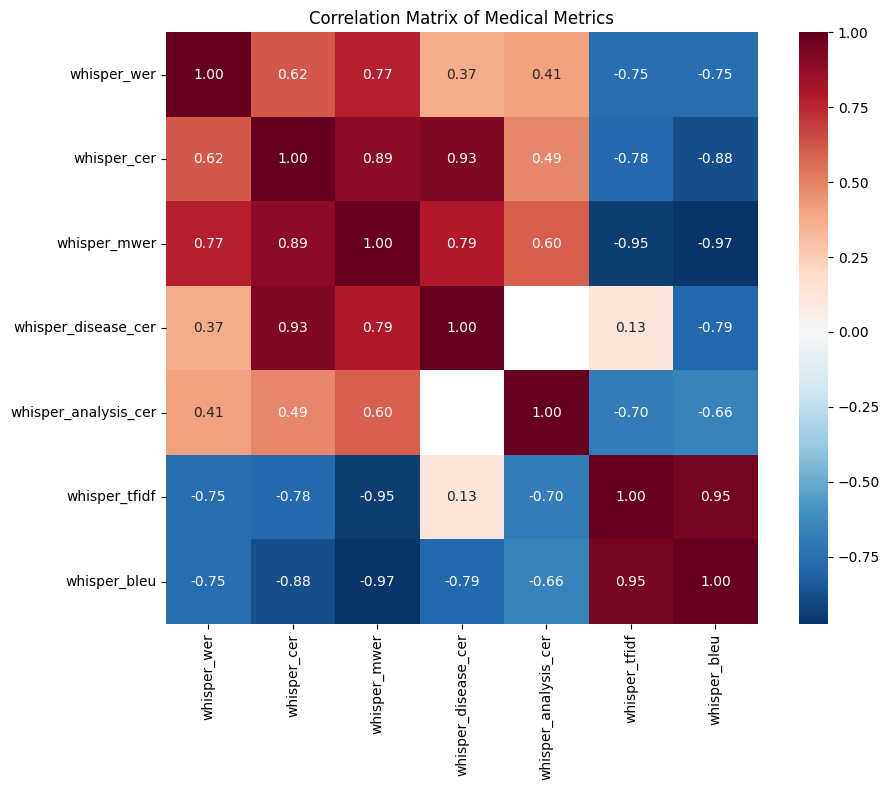

✓ График 3: Корреляционная матрица


/tmp/ipython-input-1189914317.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(mwer_data, labels=[c.replace('_', '\n') for c in conditions],


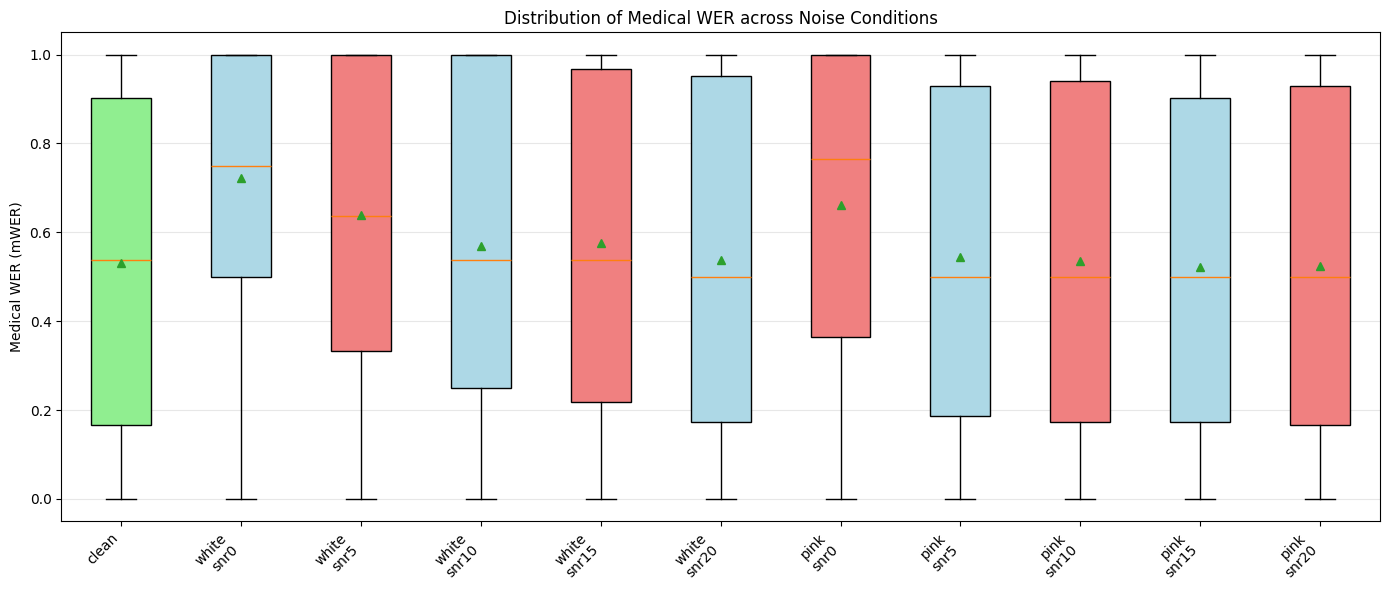

✓ График 4: Распределение mWER

✓ Все графики сохранены в /content/eval_work/results/plots


In [ ]:
# ============================================
# ВИЗУАЛИЗАЦИЯ МЕДИЦИНСКИХ МЕТРИК
# ============================================

print("=== ВИЗУАЛИЗАЦИЯ ===\n")

# 1. Медицинские метрики по SNR
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

metrics_to_plot = [
    ('whisper_wer', 'WER'),
    ('whisper_cer', 'CER'),
    ('whisper_mwer', 'Medical WER'),
    ('whisper_disease_cer', 'Disease CER'),
    ('whisper_analysis_cer', 'Analysis CER'),
    ('whisper_tfidf', 'TF-IDF Similarity')
]

for idx, (col, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]

    for nt in NOISE_TYPES:
        means = []
        stds = []
        for snr in SNR_LEVELS:
            data = df_results[(df_results['noise_type'] == nt) &
                           (df_results['snr_db'] == snr)][col].dropna()
            means.append(data.mean() if len(data) > 0 else 0)
            stds.append(data.std() if len(data) > 0 else 0)

        ax.errorbar(SNR_LEVELS, means, yerr=stds, marker='o', label=nt, capsize=3)

    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs SNR')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if 'Similarity' not in title:
        ax.invert_xaxis()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "medical_metrics_by_snr.png"), dpi=300)
plt.show()
print("✓ График 1: Медицинские метрики по SNR")

# 2. Сравнение Disease vs Analysis CER
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(SNR_LEVELS))
width = 0.35

d_means = [df_results[(df_results['snr_db'] == s)]['whisper_disease_cer'].mean()
           for s in SNR_LEVELS]
a_means = [df_results[(df_results['snr_db'] == s)]['whisper_analysis_cer'].mean()
           for s in SNR_LEVELS]

ax.bar(x - width/2, d_means, width, label='Disease CER', color='coral')
ax.bar(x + width/2, a_means, width, label='Analysis CER', color='skyblue')

ax.set_xlabel('SNR (dB)')
ax.set_ylabel('Character Error Rate')
ax.set_title('Disease vs Analysis Terms Recognition Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(SNR_LEVELS)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "disease_vs_analysis_cer.png"), dpi=300)
plt.show()
print("✓ График 2: Disease vs Analysis CER")

# 3. Корреляционная матрица метрик
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['whisper_wer', 'whisper_cer', 'whisper_mwer',
             'whisper_disease_cer', 'whisper_analysis_cer',
             'whisper_tfidf', 'whisper_bleu']
corr_matrix = df_results[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax)
ax.set_title('Correlation Matrix of Medical Metrics')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "correlation_matrix.png"), dpi=300)
plt.show()
print("✓ График 3: Корреляционная матрица")

# 4. Boxplot сравнения условий
fig, ax = plt.subplots(figsize=(14, 6))

conditions = ['clean'] + [f'{nt}_snr{s}' for nt in NOISE_TYPES for s in SNR_LEVELS]
mwer_data = [df_results[df_results['condition'] == c]['whisper_mwer'].dropna().values
             for c in conditions]

bp = ax.boxplot(mwer_data, labels=[c.replace('_', '\n') for c in conditions],
                patch_artist=True, showmeans=True)

colors = ['lightgreen'] + ['lightblue', 'lightcoral'] * len(SNR_LEVELS)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Medical WER (mWER)')
ax.set_title('Distribution of Medical WER across Noise Conditions')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "mwer_distribution.png"), dpi=300)
plt.show()
print("✓ График 4: Распределение mWER")

print(f"\n✓ Все графики сохранены в {PLOTS_DIR}")



---



In [ ]:
# ============================================
# ЗАГРУЗКА ДАННЫХ ИЗ EXCEL
# ============================================
EXCEL_PATH = "/content/drive/MyDrive/dataset_ds/med_set.xlsx"

def load_dataset(excel_path):
    """Загружает датасет из Excel файла"""
    if not Path(excel_path).exists():
        raise FileNotFoundError(f"Файл {excel_path} не найден. Загрузите его в Colab.")

    df = pd.read_excel(excel_path, sheet_name=0, dtype=str)
    df.columns = [c.strip() for c in df.columns]

    # Ищем нужные колонки (гибкий поиск)
    col_map = {}
    expected = {
        'id': ['id', 'ID', 'номер', 'number'],
        'short_label': ['short', 'short_label', 'brief', 'краткий'],
        'reference_utterance': ['reference', 'reference_utterance', 'ref', 'эталон'],
        'context_text': ['context', 'context_text', 'full', 'контекст']
    }

    for key, variants in expected.items():
        found = None
        for col in df.columns:
            col_lower = col.lower().replace(' ', '_')
            for var in variants:
                if var.lower() in col_lower:
                    found = col
                    break
            if found:
                break
        if not found:
            print(f"Предупреждение: колонка для '{key}' не найдена. Доступные: {df.columns.tolist()}")
            found = df.columns[0] if key == 'id' else None
        col_map[key] = found

    # Строим словарь референсов
    refs = {}
    for _, row in df.iterrows():
        idv = str(row[col_map['id']]).strip() if col_map['id'] else ""
        if not idv or idv.lower() == 'nan':
            continue

        refs[idv] = {
            'id': idv,
            'short': str(row.get(col_map['short_label'], "")).strip(),
            'reference_utterance': str(row.get(col_map['reference_utterance'], "")).strip(),
            'context_text': str(row.get(col_map['context_text'], "")).strip()
        }

    return refs, df

refs, df_raw = load_dataset(EXCEL_PATH)
print(f"Загружено {len(refs)} записей из Excel")
print(f"Пример ID: {list(refs.keys())[0] if refs else 'нет данных'}")
print(f"Колонки: {df_raw.columns.tolist()}")

Загружено 50 записей из Excel
Пример ID: 07-143
Колонки: ['id', 'type', 'short_label', 'reference_utterance', 'context_text']


In [ ]:
# ============================================
# ФУНКЦИИ ДЛЯ РАБОТЫ С ФАЙЛАМИ АЛИСЫ
# ============================================

def parse_alice_filename(filename):
    """
    Парсит имя файла Алисы: 40-024_03 -> (id=40-024, variant=3)
    variant: 1=short(колонка 2), 2=reference(колонка 3), 3=context(колонка 4)
    """
    stem = Path(filename).stem  # без расширения

    # Шаблон: ID_variant где variant = 1, 2, 3
    # Примеры: 02-005_2, 40-024_03, 40-024-3, 40-024.3

    patterns = [
        r'([0-9]{2,}-[0-9]{1,4})[_\-\.]?0?([123])$',  # 02-005_2 или 40-024_03 или 40-024.3
        r'([0-9]{2,}-[0-9]{1,4})[_\-\.]?v?0?([123])$',  # с v: 40-024_v2
        r'([0-9]{2,}-[0-9]{1,4}).*?[_\-\s]([123])$',  # более гибкий
    ]

    for pattern in patterns:
        m = re.search(pattern, stem)
        if m:
            id_part = m.group(1)
            variant = m.group(2)
            return id_part, variant

    # Если не сработало, пробуем найти ID в начале
    id_match = re.match(r'([0-9]{2,}-[0-9]{1,4})', stem)
    if id_match:
        id_part = id_match.group(1)
        # Ищем цифру в конце
        var_match = re.search(r'([123])$', stem)
        if var_match:
            return id_part, var_match.group(1)

    return None, None

def find_alice_files(input_dir):
    """Находит все mp4 файлы Алисы"""
    patterns = ['*.mp4', '*.MP4', '*.wav', '*.WAV']
    files = []
    for pattern in patterns:
        files.extend(Path(input_dir).glob(pattern))
    return sorted([str(f) for f in files])

def convert_to_wav(input_path, output_path, target_sr=24000):
    """Конвертирует аудио в WAV mono 16-bit"""
    cmd = [
        "ffmpeg", "-y", "-i", input_path,
        "-ar", str(target_sr), "-ac", "1",
        "-vn", "-sample_fmt", "s16",
        output_path
    ]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except Exception as e:
        print(f"Ошибка конвертации {input_path}: {e}")
        return False

# Находим и обрабатываем файлы Алисы
alice_files = find_alice_files(ALICE_INPUT_DIR)
print(f"Найдено {len(alice_files)} файлов Алисы")

alice_data = {}  # (id, variant) -> путь к wav

for fpath in alice_files:
    fname = os.path.basename(fpath)
    id_part, variant = parse_alice_filename(fname)

    if id_part and variant:
        # Конвертируем в WAV
        wav_name = f"{id_part}_{variant}.wav"
        wav_path = os.path.join(ALICE_WAV_DIR, wav_name)

        if convert_to_wav(fpath, wav_path):
            alice_data[(id_part, variant)] = {
                'original': fpath,
                'wav': wav_path,
                'id': id_part,
                'variant': variant
            }
            print(f"✓ {fname} -> {wav_name} (ID={id_part}, Var={variant})")
    else:
        print(f"✗ Не удалось распознать: {fname}")

print(f"\nУспешно обработано: {len(alice_data)} файлов Алисы")

Найдено 33 файлов Алисы
✓ 02-005_2.mp4 -> 02-005_2.wav (ID=02-005, Var=2)
✓ 09-179_1.mp4 -> 09-179_1.wav (ID=09-179, Var=1)
✓ 09-179_2.mp4 -> 09-179_2.wav (ID=09-179, Var=2)
✓ 09-179_3.mp4 -> 09-179_3.wav (ID=09-179, Var=3)
✓ 15-014_1.mp4 -> 15-014_1.wav (ID=15-014, Var=1)
✓ 15-014_2.mp4 -> 15-014_2.wav (ID=15-014, Var=2)
✓ 15-014_3.mp4 -> 15-014_3.wav (ID=15-014, Var=3)
✓ 19-021_1.mp4 -> 19-021_1.wav (ID=19-021, Var=1)
✓ 19-021_2.mp4 -> 19-021_2.wav (ID=19-021, Var=2)
✓ 19-021_3.mp4 -> 19-021_3.wav (ID=19-021, Var=3)
✓ 40-131_2.mp4 -> 40-131_2.wav (ID=40-131, Var=2)
✓ 40-131_3.mp4 -> 40-131_3.wav (ID=40-131, Var=3)
✓ 40-138_1.mp4 -> 40-138_1.wav (ID=40-138, Var=1)
✓ 40-138_2.mp4 -> 40-138_2.wav (ID=40-138, Var=2)
✓ 40-138_3.mp4 -> 40-138_3.wav (ID=40-138, Var=3)
✓ 40-142_1.mp4 -> 40-142_1.wav (ID=40-142, Var=1)
✓ 40-142_3.mp4 -> 40-142_3.wav (ID=40-142, Var=3)
✓ 40-153_3.mp4 -> 40-153_3.wav (ID=40-153, Var=3)
✓ 40-439_1.mp4 -> 40-439_1.wav (ID=40-439, Var=1)
✓ 40-439_2.mp4 -> 40-439_2

In [ ]:
pip install -q openai-whisper==20230314 jiwer pandas matplotlib openpyxl soundfile tqdm scipy triton==2.3.0

In [ ]:
pip install faster_whisper

In [ ]:
pip install whisper

In [ ]:
pip install jiwer

Loaded references: 50 items.
Found 150 mp4 files.
Automatically mapped 150/150 files to (id,variant).

Final mapped files count: 150
02-005_1.mp4 -> 02-005 variant 1
02-005_2.mp4 -> 02-005 variant 2
02-005_3.mp4 -> 02-005 variant 3
02-060_1.mp4 -> 02-060 variant 1
02-060_2.mp4 -> 02-060 variant 2
02-060_3.mp4 -> 02-060 variant 3
03-004_1.mp4 -> 03-004 variant 1
03-004_2.mp4 -> 03-004 variant 2
03-004_3.mp4 -> 03-004 variant 3
06-020_1.mp4 -> 06-020 variant 1
06-020_2.mp4 -> 06-020 variant 2
06-020_3.mp4 -> 06-020 variant 3
06-024_1.mp4 -> 06-024 variant 1
06-024_2.mp4 -> 06-024 variant 2
06-024_3.mp4 -> 06-024 variant 3
06-064_1.mp4 -> 06-064 variant 1
06-064_2.mp4 -> 06-064 variant 2
06-064_3.mp4 -> 06-064 variant 3
06-102_1.mp4 -> 06-102 variant 1
06-102_2.mp4 -> 06-102 variant 2
06-102_3.mp4 -> 06-102 variant 3
06-115_1.mp4 -> 06-115 variant 1
06-115_2.mp4 -> 06-115 variant 2
06-115_3.mp4 -> 06-115 variant 3
06-189_1.mp4 -> 06-189 variant 1
06-189_2.mp4 -> 06-189 variant 2
06-189_3.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocabulary.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.bin:   0%|          | 0.00/484M [00:00<?, ?B/s]

Transcribe & eval: 100%|██████████| 150/150 [50:54<00:00, 20.36s/it]
/tmp/ipython-input-3399507374.py:315: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


Saved metrics_detailed.csv with 150 rows
Saved metrics_summary_by_variant.csv
  variant  wer_mean  wer_median   wer_std  count  med_mean  med_count
0       1  0.672476    0.500000  0.642213     50  0.437762         50
1       2  0.307533    0.200000  0.465499     50  0.248953         50
2       3  0.227144    0.191311  0.188807     50  0.155804         50
Kruskal-Wallis across variants: H=31.9464, p=1.156e-07


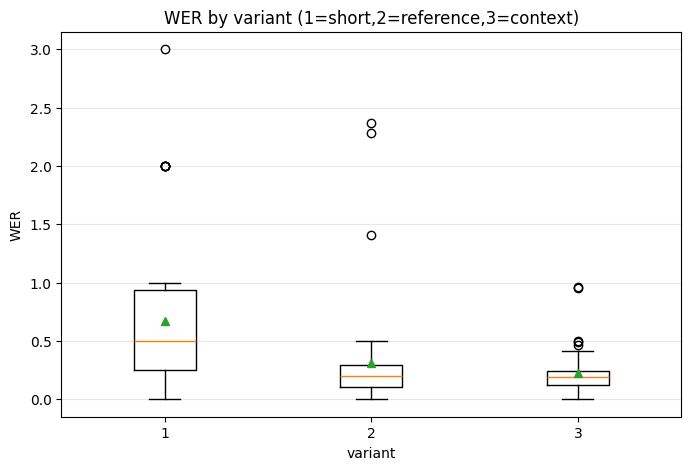

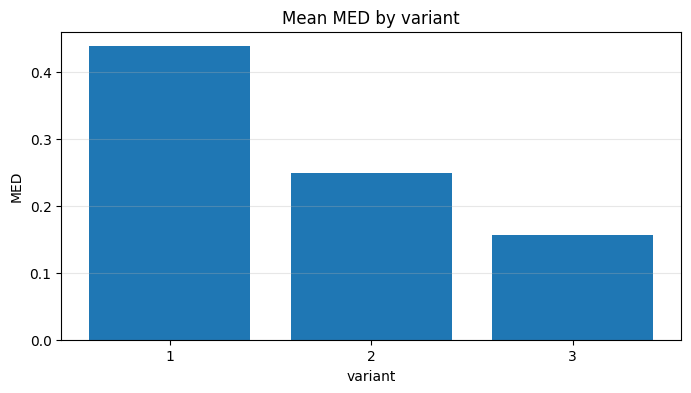

Plots saved in eval_work/results/plots
All results saved to eval_work/results


In [ ]:
# Скрипт оценки (faster-whisper)
import os
import re
import subprocess
from pathlib import Path
from glob import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import soundfile as sf
# from jiwer import wer, cer  # jiwer оставляем
from jiwer import wer, cer
from scipy.stats import kruskal

# faster-whisper
from faster_whisper import WhisperModel

# -------------------- SETTINGS --------------------
INPUT_DIR = "."               # where your mp4 files are (change if needed)
XLSX_FILENAME = "med_set.xlsx"   # your dataset file (change if needed)
WORK_DIR = "eval_work"
WAV_DIR = os.path.join(WORK_DIR, "wav")
RESULTS_DIR = os.path.join(WORK_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

WHISPER_MODEL = "small"   # faster-whisper model: tiny, base, small, medium, large
DEVICE = "cpu"            # "cpu" or "cuda"
COMPUTE_TYPE = "float32"  # "float32" for cpu; on cuda you might use "float16" or "int8"
# --------------------------------------------------

os.makedirs(WAV_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# -------------------- Load dataset --------------------
if not Path(XLSX_FILENAME).exists():
    raise FileNotFoundError(f"Dataset file '{XLSX_FILENAME}' not found in working dir. Upload it to Colab or place in folder.")

# try read with pandas (first sheet = analyses)
df = pd.read_excel(XLSX_FILENAME, sheet_name=0, dtype=str)
# Normalize column names to expected ones (lower-case / strip)
df.columns = [c.strip() for c in df.columns]

# Ensure columns exist; if not, try common variants
expected = ['id', 'type', 'short_label', 'reference_utterance', 'context_text']
col_map = {}
for e in expected:
    found = None
    for c in df.columns:
        if c.lower().replace(" ", "_").find(e.replace(" ", "_")) >= 0:
            found = c
            break
    if not found:
        # if some expected column not found, allow user to supply mapping
        raise RuntimeError(f"Column matching '{e}' not found in spreadsheet. Available columns: {df.columns.tolist()}")
    col_map[e] = found

# Build refs dict: id -> fields
refs = {}
for _, row in df.iterrows():
    idv = str(row[col_map['id']]).strip()
    if not idv or idv.lower() == 'nan':
        continue
    refs[idv] = {
        'id': idv,
        'short': str(row.get(col_map['short_label']) or "").strip(),
        'reference_utterance': str(row.get(col_map['reference_utterance']) or "").strip(),
        'context_text': str(row.get(col_map['context_text']) or "").strip()
    }

print("Loaded references:", len(refs), "items.")

# -------------------- Collect mp4 files --------------------
mp4_paths = sorted([str(p) for p in Path(INPUT_DIR).rglob("*.mp4")])
if len(mp4_paths) == 0:
    raise RuntimeError("No .mp4 files found in INPUT_DIR. Upload your mp4 files.")

print(f"Found {len(mp4_paths)} mp4 files.")

# -------------------- Helper: map filename to (id, variant) --------------------
variant_tokens = ['_1', '-1', '.1', ' 1', '_v1', '_one', '/1', '_01', '-01']
def extract_id_variant_from_name(path_str):
    fname = Path(path_str).stem  # name without extension
    m = re.search(r'([0-9]{2,}-[0-9]{1,4}|[0-9]{2,4}|[a-z0-9_\-]+?)[:._\-\s]+([123])$', fname, flags=re.I)
    if m:
        cand_id = m.group(1)
        variant = m.group(2)
        return cand_id, variant
    parts = Path(path_str).parts
    if len(parts) >= 2:
        last = parts[-1]
        parent = parts[-2]
        if re.fullmatch(r'[123]\.mp4', last):
            return parent, last[0]
    for idv in refs.keys():
        if idv in fname:
            post = fname.split(idv,1)[1]
            m2 = re.search(r'[_\-\.\s]?([123])', post)
            variant = m2.group(1) if m2 else None
            return idv, variant
    return None, None

file_map = {}
for p in mp4_paths:
    idv, var = extract_id_variant_from_name(p)
    file_map[p] = {'id': idv, 'variant': var}

mapped = sum(1 for v in file_map.values() if v['id'] and v['variant'])
print(f"Automatically mapped {mapped}/{len(file_map)} files to (id,variant).")
if mapped < len(file_map):
    print("Unmapped files (need manual mapping):")
    for p,(m) in file_map.items():
        if m['id'] is None or m['variant'] is None:
            print(" -", p)

# Attempt simple heuristic for unmapped and interactive mapping
unmapped = [p for p,v in file_map.items() if v['id'] is None or v['variant'] is None]
if len(unmapped) > 0:
    print("\nAttempting simple heuristic mapping by searching for any refs in filename.")
    for p in unmapped:
        fname = Path(p).stem.lower()
        assigned = False
        for idv in refs.keys():
            if idv.replace('-', '').lower() in fname.replace('-', ''):
                m = re.search(r'([123])', fname[::-1])
                variant = None
                if m:
                    variant = m.group(1)[::-1] if isinstance(m.group(1), str) else None
                file_map[p]['id'] = idv
                file_map[p]['variant'] = variant
                assigned = True
                break
        if not assigned:
            print("\nFile:", p)
            print("Enter id from dataset (or press Enter to skip):")
            choice = input().strip()
            if choice in refs:
                file_map[p]['id'] = choice
                var_choice = input("Enter variant number (1=short,2=reference,3=context), or Enter to skip: ").strip()
                if var_choice in ['1','2','3']:
                    file_map[p]['variant'] = var_choice

final_mapped = {p:v for p,v in file_map.items() if v['id'] and v['variant']}
print(f"\nFinal mapped files count: {len(final_mapped)}")
for p,v in final_mapped.items():
    print(Path(p).name, "->", v['id'], "variant", v['variant'])

# -------------------- Convert mp4 -> wav --------------------
def convert_to_wav(mp4_path, wav_out, sr=24000):
    cmd = ["ffmpeg", "-y", "-i", mp4_path, "-ar", str(sr), "-ac", "1", "-vn", "-sample_fmt", "s16", wav_out]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except subprocess.CalledProcessError as e:
        print("ffmpeg conversion failed:", mp4_path, e)
        return False

mapped_wavs = {}
for mp4,meta in final_mapped.items():
    mp4p = Path(mp4)
    base = f"{meta['id']}_v{meta['variant']}"
    wav_out = os.path.join(WAV_DIR, base + ".wav")
    ok = convert_to_wav(mp4, wav_out)
    if ok:
        mapped_wavs[wav_out] = meta

print("Converted to WAV count:", len(mapped_wavs))

if len(mapped_wavs) == 0:
    raise RuntimeError("No WAV files created; cannot proceed.")

# -------------------- Build MED lexicon from dataset --------------------
_token_re = re.compile(r"\w+", flags=re.UNICODE)
med_lexicon = set()
def add_tokens_to_lexicon(text):
    if not text: return
    t = str(text)
    for tok in _token_re.findall(t):
        tok = tok.lower()
        if len(tok) > 2:
            med_lexicon.add(tok)
# collect from all fields
for v in refs.values():
    add_tokens_to_lexicon(v['short'])
    add_tokens_to_lexicon(v['reference_utterance'])
    add_tokens_to_lexicon(v['context_text'])

print("Built MED lexicon size:", len(med_lexicon))
# save lexicon
with open(os.path.join(RESULTS_DIR, "med_lexicon.txt"), "w", encoding="utf8") as f:
    for tok in sorted(med_lexicon):
        f.write(tok + "\n")

# -------------------- Load faster-whisper model --------------------
print("Loading faster-whisper model:", WHISPER_MODEL, "device:", DEVICE, "compute_type:", COMPUTE_TYPE)
model = WhisperModel(WHISPER_MODEL, device=DEVICE, compute_type=COMPUTE_TYPE)

# -------------------- Transcribe & Evaluate (faster-whisper) --------------------
rows = []
for wav_path, meta in tqdm(mapped_wavs.items(), desc="Transcribe & eval"):
    wavname = Path(wav_path).name
    engine = "yandex_demo"  # you can parse from filename if multiple engines present
    # transcribe with faster-whisper
    try:
        # beam_size и vad_filter можно менять; vad_filter=True помогает отрезать тишину
        segments, info = model.transcribe(wav_path, beam_size=5, vad_filter=True, language="ru")
        hyp = "".join([seg.text for seg in segments]).strip()
    except Exception as e:
        print("Transcription failed for", wav_path, e)
        hyp = ""
    # pick reference based on variant
    idv = meta['id']
    var = meta['variant']
    if idv in refs:
        if var == '1':
            ref_text = refs[idv]['short']
        elif var == '2':
            ref_text = refs[idv]['reference_utterance']
        elif var == '3':
            ref_text = refs[idv]['context_text']
        else:
            ref_text = ""
    else:
        ref_text = ""
    # normalization function (simple)
    def normalize_text(t):
        if t is None:
            return ""
        s = str(t)
        s = s.replace('—', ' ').replace('–',' ')
        s = re.sub(r'[\(\)\[\]«»"“”]', ' ', s)
        s = re.sub(r'\s+', ' ', s)
        s = s.strip().lower()
        return s
    ref_norm = normalize_text(ref_text)
    hyp_norm = normalize_text(hyp)
    # compute metrics
    w = wer(ref_norm, hyp_norm) if ref_norm else None
    c = cer(ref_norm, hyp_norm) if ref_norm else None
    # MED: WER computed only on tokens that are in med_lexicon
    def med_metric(refn, hypn, lex):
        if not refn:
            return None
        rtokens = [t for t in _token_re.findall(refn) if len(t)>1]
        htokens = [t for t in _token_re.findall(hypn) if len(t)>1]
        r_med = [t for t in rtokens if t in lex]
        h_med = [t for t in htokens if t in lex]
        if len(r_med) == 0:
            return 0.0
        try:
            return wer(" ".join(r_med), " ".join(h_med))
        except Exception:
            return None
    m = med_metric(ref_norm, hyp_norm, med_lexicon)
    # duration
    try:
        audio, sr = sf.read(wav_path)
        dur = len(audio) / sr
    except Exception:
        dur = None
    rows.append({
        "wav": wavname,
        "wav_path": wav_path,
        "id": idv,
        "variant": var,
        "engine": engine,
        "ref_text": ref_text,
        "ref_norm": ref_norm,
        "hyp_text": hyp,
        "hyp_norm": hyp_norm,
        "wer": w,
        "cer": c,
        "med": m,
        "duration_s": dur
    })

df_res = pd.DataFrame(rows)
df_res.to_csv(os.path.join(RESULTS_DIR, "metrics_detailed.csv"), index=False)
print("Saved metrics_detailed.csv with", len(df_res), "rows")

# -------------------- Summaries: by variant --------------------
df_res['variant'] = df_res['variant'].astype(str)
summary_by_variant = df_res.groupby('variant').agg({
    'wer': ['mean','median','std','count'],
    'med': ['mean','count']
}).reset_index()
summary_by_variant.columns = ['variant','wer_mean','wer_median','wer_std','count','med_mean','med_count']
summary_by_variant.to_csv(os.path.join(RESULTS_DIR, "metrics_summary_by_variant.csv"), index=False)
print("Saved metrics_summary_by_variant.csv")
print(summary_by_variant)

# -------------------- Statistical test: Kruskal-Wallis WER across variants --------------------
groups = []
labels = []
for v in sorted(df_res['variant'].unique()):
    arr = df_res[df_res['variant']==v]['wer'].dropna().values
    if len(arr) > 0:
        groups.append(arr)
        labels.append(v)
if len(groups) >= 2:
    h, p = kruskal(*groups)
    with open(os.path.join(RESULTS_DIR, "kruskal_wer_by_variant.txt"), "w") as f:
        f.write(f"Kruskal-Wallis H={h}, p={p}\n")
    print("Kruskal-Wallis across variants: H=%.4f, p=%.4g" % (h,p))
else:
    print("Not enough data for Kruskal-Wallis test (need at least 2 groups with samples).")

# -------------------- Plots --------------------
plt.figure(figsize=(8,5))
order = sorted(df_res['variant'].unique())
data = [df_res[df_res['variant']==v]['wer'].dropna().values for v in order]
plt.boxplot(data, labels=order, showmeans=True)
plt.title("WER by variant (1=short,2=reference,3=context)")
plt.xlabel("variant")
plt.ylabel("WER")
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(PLOTS_DIR, "wer_by_variant_boxplot.png"), dpi=200)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(summary_by_variant['variant'], summary_by_variant['med_mean'])
plt.title("Mean MED by variant")
plt.xlabel("variant")
plt.ylabel("MED")
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(PLOTS_DIR, "med_by_variant_bar.png"), dpi=200)
plt.show()

print("Plots saved in", PLOTS_DIR)

# -------------------- Save and finish --------------------
df_res.to_csv(os.path.join(RESULTS_DIR, "metrics_detailed.csv"), index=False)
print("All results saved to", RESULTS_DIR)


In [ ]:
!pip uninstall -y whisper
!pip install -U faster-whisper sentencepiece
# Установите torch, если ещё не установлен (опционально, зависит от среды)
!pip install -U torch --index-url https://download.pytorch.org/whl/cu118


Found existing installation: whisper 1.1.10
Uninstalling whisper-1.1.10:
  Successfully uninstalled whisper-1.1.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.8/38.8 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.2 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
from faster_whisper import WhisperModel

# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"  # Changed from "cuda" to "cpu"
model = WhisperModel("small", device=device, compute_type="float32")  # compute_type can be changed

# Example transcription of one file:
segments, info = model.transcribe("eval_work/wav/07-143_v2.wav", beam_size=5, vad_filter=True, language="ru")
hyp = " ".join([seg.text for seg in segments])
print("Hypothesis:", hyp)

Hypothesis:  Антителак вирусу гипотита А.  Определение ему на глобулинов ИКМ и ИКДЖи в венозной крови.  Подготовка.  Не курить в течение 30 минут до исследования.  Вирус гипотита А.  ХЭФ.  Оболочечный РНК, содержащий вирус,  вызывающий клинически выраженный или бессимптомный гипотит.  Инфекция обычно острая и разрешается.  Хронические формы редки не описаны.  ИКМ появляется через 5-10 дней, сохраняется до 4-6 месяцев.  ИКДЖи появляется со второй недели и сохраняется пожизненно.


In [ ]:
!pip install faster-whisper jiwer==3.0.3 sentence-transformers rapidfuzz seaborn statsmodels soundfile

  Attempting uninstall: jiwer
    Found existing installation: jiwer 4.0.0
    Uninstalling jiwer-4.0.0:
      Successfully uninstalled jiwer-4.0.0


In [ ]:
# ================================
# IMPORTS
# ================================
import os
import re
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from jiwer import wer, cer, process_words
from faster_whisper import WhisperModel
from sentence_transformers import SentenceTransformer, util
from scipy.stats import kruskal, wilcoxon
import statsmodels.formula.api as smf
import soundfile as sf
from rapidfuzz import process as rf_process, fuzz

# ================================
# SETTINGS
# ================================
INPUT_DIR = "/content"           # your mp4 files appear in Colab root
XLSX_FILENAME = "/content/med_set.xlsx"

WORK_DIR = "/content/eval_work"
WAV_DIR = f"{WORK_DIR}/wav"
RESULTS_DIR = f"{WORK_DIR}/results"
PLOTS_DIR = f"{RESULTS_DIR}/plots"

WHISPER_MODEL = "small"
DEVICE = "cpu"
COMPUTE_TYPE = "float32"

os.makedirs(WAV_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ================================
# LOAD DATASET
# ================================
df = pd.read_excel(XLSX_FILENAME, sheet_name=0, dtype=str)
df.columns = [c.strip() for c in df.columns]

expected = ['id', 'type', 'short_label', 'reference_utterance', 'context_text']
col_map = {}

for e in expected:
    for c in df.columns:
        if e in c.lower().replace(" ", "_"):
            col_map[e] = c
            break
    if e not in col_map:
        raise RuntimeError(f"Column matching '{e}' not found in Excel")

refs = {}
for _, row in df.iterrows():
    idv = str(row[col_map["id"]]).strip()
    if idv:
        refs[idv] = {
            "short": str(row[col_map["short_label"]]).strip(),
            "reference_utterance": str(row[col_map["reference_utterance"]]).strip(),
            "context_text": str(row[col_map["context_text"]]).strip()
        }

print("Loaded references:", len(refs))

# ================================
# COLLECT MP4 FILES
# ================================
mp4_paths = sorted([str(p) for p in Path(INPUT_DIR).glob("*.mp4")])
print("Found:", len(mp4_paths), "mp4 files.")

# ================================
# MAP FILENAMES TO (ID, VARIANT)
# ================================
def extract_id_variant(fname):
    """
    Expected format: 02-005_1.mp4 → id=02-005, variant=1
    """
    m = re.match(r"([0-9]{2}-[0-9]{3})[_\-]([123])", fname)
    if m:
        return m.group(1), m.group(2)
    return None, None

file_map = {}
for p in mp4_paths:
    fn = Path(p).name
    idv, var = extract_id_variant(fn)
    file_map[p] = {"id": idv, "variant": var}

final_mapped = {p:v for p,v in file_map.items() if v["id"] and v["variant"]}
print("Mapped:", len(final_mapped))

# ================================
# CONVERT MP4 → WAV
# ================================
def convert_to_wav(mp4_path, wav_out, sr=24000):
    cmd = ["ffmpeg", "-y", "-i", mp4_path, "-ar", str(sr), "-ac", "1", "-vn", "-sample_fmt", "s16", wav_out]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except:
        return False

mapped_wavs = {}
for mp4, meta in final_mapped.items():
    base = f"{meta['id']}_v{meta['variant']}"
    wav_path = f"{WAV_DIR}/{base}.wav"
    if convert_to_wav(mp4, wav_path):
        mapped_wavs[wav_path] = meta

print("Converted wav:", len(mapped_wavs))

# ================================
# BUILD LEXICON
# ================================
_token_re = re.compile(r"\w+", flags=re.UNICODE)

med_lexicon = set()
def add_lex(text):
    if text:
        for t in _token_re.findall(text.lower()):
            if len(t) > 2:
                med_lexicon.add(t)

for r in refs.values():
    add_lex(r["short"])
    add_lex(r["reference_utterance"])
    add_lex(r["context_text"])

print("Lexicon size:", len(med_lexicon))

# ================================
# LOAD WHISPER MODEL
# ================================
model = WhisperModel(WHISPER_MODEL, device=DEVICE, compute_type=COMPUTE_TYPE)

# ================================
# SEMANTIC MODEL
# ================================
sbert = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# ================================
# TEXT NORMALIZATION
# ================================
def normalize(t):
    if not t:
        return ""
    t = t.lower()
    t = t.replace("—", " ").replace("–", " ")
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

# ================================
# ENTITY EXTRACTION
# ================================
def extract_entities(text):
    return set([t for t in _token_re.findall(text) if len(t) >= 3])

def entity_scores(ref, hyp):
    R = extract_entities(ref)
    H = extract_entities(hyp)
    tp = len(R & H)
    fp = len(H - R)
    fn = len(R - H)
    prec = tp/(tp+fp) if tp+fp>0 else 0.0
    rec  = tp/(tp+fn) if tp+fn>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0.0
    return prec, rec, f1

# ================================
# LEXICON CORRECTION
# ================================
def apply_lexicon_correction(hyp, lex, thresh=85):
    toks = _token_re.findall(hyp)
    out = []
    for t in toks:
        cand, score, _ = rf_process.extractOne(t, lex, scorer=fuzz.WRatio)
        out.append(cand if score >= thresh else t)
    return " ".join(out)

# ================================
# MAIN LOOP
# ================================
rows = []

for wav_path, meta in mapped_wavs.items():

    # transcribe
    segs, info = model.transcribe(wav_path, beam_size=5, vad_filter=True, language="ru")
    hyp = "".join([s.text for s in segs]).strip()

    var = meta["variant"]
    idv = meta["id"]

    if var == "1":
        ref = refs[idv]["short"]
    elif var == "2":
        ref = refs[idv]["reference_utterance"]
    else:
        ref = refs[idv]["context_text"]

    ref_norm = normalize(ref)
    hyp_norm = normalize(hyp)

    # WER / CER
    w = wer(ref_norm, hyp_norm)
    c = cer(ref_norm, hyp_norm)

    # S / D / I (new API)
    measures = process_words(ref_norm, hyp_norm)
    subs = measures.substitutions
    dels = measures.deletions
    ins = measures.insertions

    # entity evaluation
    prec, rec, f1 = entity_scores(ref_norm, hyp_norm)

    # duration
    audio, sr = sf.read(wav_path)
    dur = len(audio)/sr

    # semantic similarity
    emb_r = sbert.encode(ref_norm, convert_to_tensor=True)
    emb_h = sbert.encode(hyp_norm, convert_to_tensor=True)
    sim = util.cos_sim(emb_r, emb_h).item()

    # save row
    rows.append({
        "id": idv,
        "variant": var,
        "ref": ref_norm,
        "hyp": hyp_norm,
        "wer": w,
        "cer": c,
        "subs": subs,
        "dels": dels,
        "ins": ins,
        "ent_prec": prec,
        "ent_rec": rec,
        "ent_f1": f1,
        "duration": dur,
        "sbert_sim": sim
    })

df_res = pd.DataFrame(rows)
df_res.to_csv(f"{RESULTS_DIR}/metrics.csv", index=False)
df_res.head()




Loaded references: 50
Found: 150 mp4 files.
Mapped: 147
Converted wav: 141
Lexicon size: 1346
         count      mean       std  min       25%       50%       75%  \
variant                                                                 
1         49.0  0.540525  0.619780  0.0  0.000000  0.333333  1.000000   
2         47.0  0.313722  0.501014  0.0  0.069048  0.187500  0.272204   
3         45.0  0.242840  0.265005  0.0  0.074074  0.151515  0.290323   

              max  
variant            
1        3.000000  
2        2.363636  
3        1.000000  

Kruskal-Wallis: 5.201159857226787 0.07423051732843504


ValueError: Array shapes are incompatible for broadcasting.

In [ ]:
# ================================
# STATISTICS
# ================================
print(df_res.groupby("variant")["wer"].describe())

# Kruskal-Wallis для множественного сравнения
h, p = kruskal(
    df_res[df_res.variant=="1"]["wer"],
    df_res[df_res.variant=="2"]["wer"],
    df_res[df_res.variant=="3"]["wer"]
)
print("\nKruskal-Wallis:", h, p)

# pairwise Mann-Whitney U test для независимых выборок
from scipy.stats import mannwhitneyu

pairs = [("1","2"), ("1","3"), ("2","3")]
for a,b in pairs:
    A = df_res[df_res.variant==a]["wer"]
    B = df_res[df_res.variant==b]["wer"]
    stat, pval = mannwhitneyu(A, B)
    print(f"{a} vs {b}: p={pval:.4f}")

         count      mean       std  min       25%       50%       75%  \
variant                                                                 
1         49.0  0.540525  0.619780  0.0  0.000000  0.333333  1.000000   
2         47.0  0.313722  0.501014  0.0  0.069048  0.187500  0.272204   
3         45.0  0.242840  0.265005  0.0  0.074074  0.151515  0.290323   

              max  
variant            
1        3.000000  
2        2.363636  
3        1.000000  

Kruskal-Wallis: 5.201159857226787 0.07423051732843504
1 vs 2: p=0.0544
1 vs 3: p=0.0462
2 vs 3: p=0.8697


                            OLS Regression Results                            
Dep. Variable:                    wer   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     27.04
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           7.05e-19
Time:                        18:26:33   Log-Likelihood:                -53.667
No. Observations:                 141   AIC:                             119.3
Df Residuals:                     135   BIC:                             137.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.0550      0

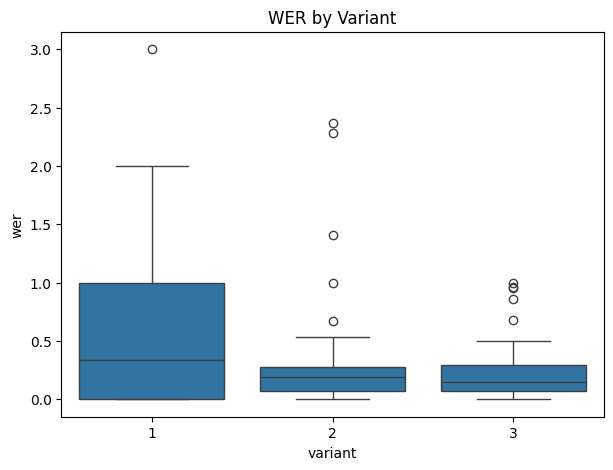

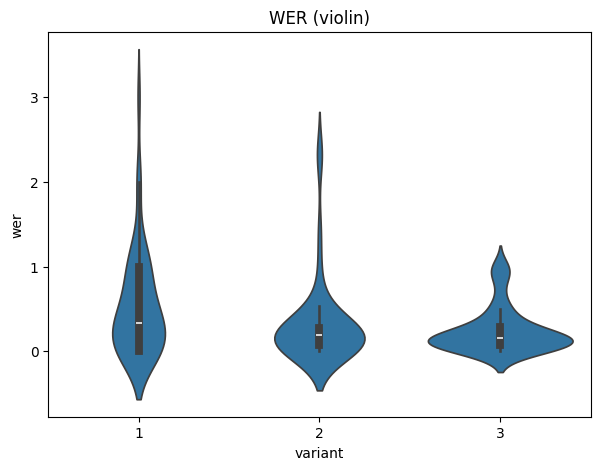

In [ ]:
# ================================
# REGRESSION
# ================================
df_res["len_tokens"] = df_res["ref"].apply(lambda s: len(_token_re.findall(s)))
df_res["has_latin"] = df_res["ref"].apply(lambda s: bool(re.search(r"[A-Za-z]", s)))
df_res["has_digits"] = df_res["ref"].apply(lambda s: bool(re.search(r"\d", s)))

model = smf.ols("wer ~ len_tokens + has_latin + has_digits + duration + sbert_sim", data=df_res).fit()
print(model.summary())

# ================================
# VISUALIZATIONS
# ================================
plt.figure(figsize=(7,5))
sns.boxplot(data=df_res, x="variant", y="wer")
plt.title("WER by Variant")
plt.savefig(f"{PLOTS_DIR}/wer_by_variant.png")
plt.show()

plt.figure(figsize=(7,5))
sns.violinplot(data=df_res, x="variant", y="wer")
plt.title("WER (violin)")
plt.savefig(f"{PLOTS_DIR}/wer_violin.png")
plt.show()

In [ ]:
# ================================
# TOP TOKEN SUBSTITUTIONS (GLOBAL)
# ================================
import difflib
from collections import Counter

def collect_substitutions(ref, hyp):
    r_tok = re.findall(r"\w+", ref)
    h_tok = re.findall(r"\w+", hyp)
    seq = difflib.SequenceMatcher(a=r_tok, b=h_tok)
    subs = []
    for tag, i1, i2, j1, j2 in seq.get_opcodes():
        if tag == "replace":
            for a, b in zip(r_tok[i1:i2], h_tok[j1:j2]):
                subs.append((a.lower(), b.lower()))
    return subs

all_subs = []
for _, row in df_res.iterrows():
    all_subs.extend(collect_substitutions(row["ref"], row["hyp"]))

top50 = Counter(all_subs).most_common(50)
top50_df = pd.DataFrame(top50, columns=["pair", "count"])
top50_df["ref"] = top50_df["pair"].apply(lambda x: x[0])
top50_df["hyp"] = top50_df["pair"].apply(lambda x: x[1])
top50_df.drop(columns=["pair"], inplace=True)

top50_df.to_csv(f"{RESULTS_DIR}/top50_substitutions.csv", index=False)
top50_df.head()


,count,ref,hyp
0,5,исследование,исследования
1,5,лабораторное,лабораторные
2,4,аутоантитела,аута
3,4,комплексное,комплексные
4,4,обследование,обследования


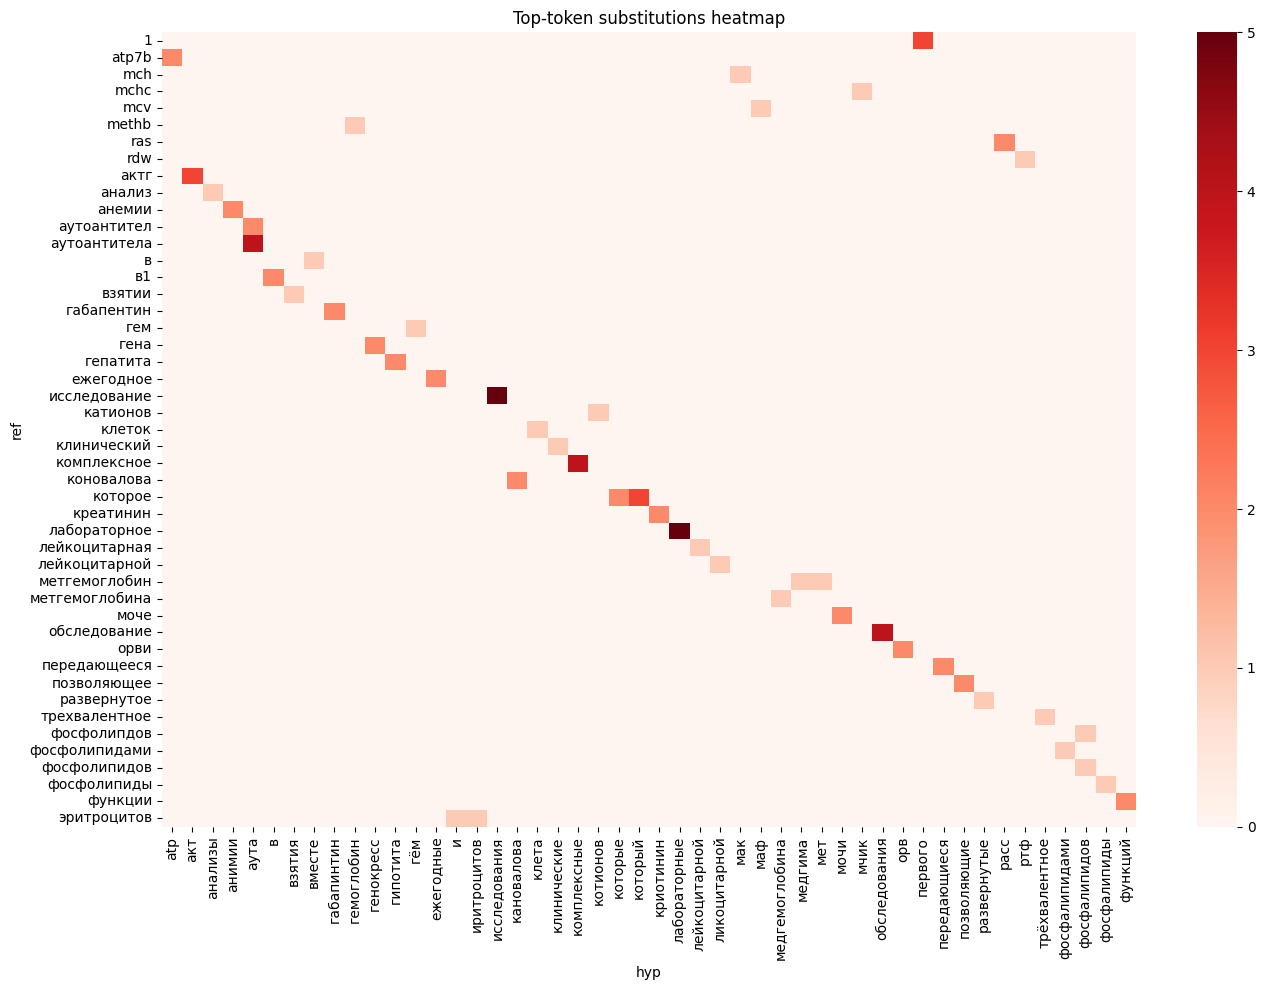

In [ ]:
# ================================
# HEATMAP TOP SUBSTITUTIONS
# ================================
import seaborn as sns
import matplotlib.pyplot as plt

pivot = top50_df.pivot_table(index="ref", columns="hyp", values="count", fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, annot=False, cmap="Reds")
plt.title("Top-token substitutions heatmap")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/top_substitutions_heatmap.png", dpi=200)
plt.show()


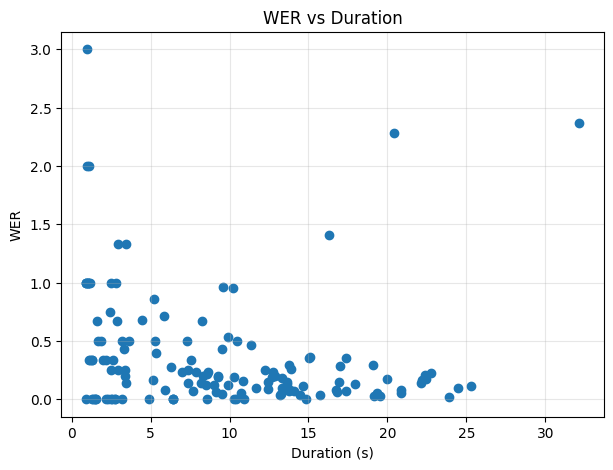

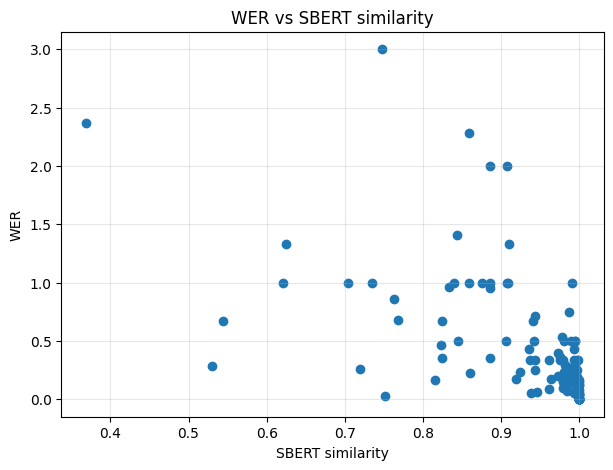

In [ ]:
# ================================
# SCATTERS
# ================================
plt.figure(figsize=(7,5))
plt.scatter(df_res["duration"], df_res["wer"])
plt.xlabel("Duration (s)")
plt.ylabel("WER")
plt.title("WER vs Duration")
plt.grid(alpha=0.3)
plt.savefig(f"{PLOTS_DIR}/scatter_wer_duration.png", dpi=200)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df_res["sbert_sim"], df_res["wer"])
plt.xlabel("SBERT similarity")
plt.ylabel("WER")
plt.title("WER vs SBERT similarity")
plt.grid(alpha=0.3)
plt.savefig(f"{PLOTS_DIR}/scatter_wer_sbert.png", dpi=200)
plt.show()


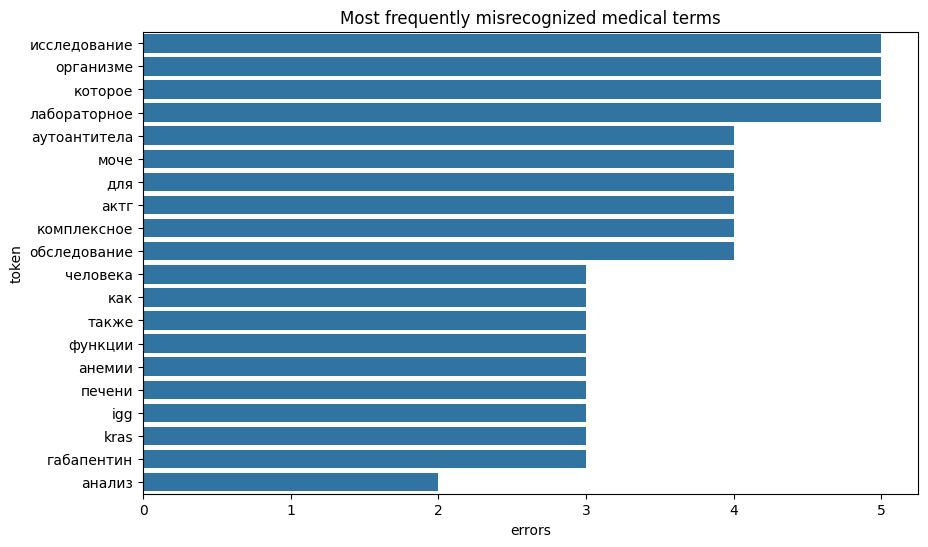

In [ ]:
# ================================
# TOKEN ERROR RATE FOR MEDICAL TERMS
# ================================
med_errors = Counter()

for _, row in df_res.iterrows():
    ref_tokens = re.findall(r"\w+", row["ref"])
    hyp_tokens = re.findall(r"\w+", row["hyp"])
    for t in ref_tokens:
        if t in med_lexicon:
            if t not in hyp_tokens:
                med_errors[t] += 1

top20_med_errors = med_errors.most_common(20)

mederr_df = pd.DataFrame(top20_med_errors, columns=["token", "errors"])
mederr_df.to_csv(f"{RESULTS_DIR}/top20_med_errors.csv", index=False)

plt.figure(figsize=(10,6))
sns.barplot(data=mederr_df, x="errors", y="token")
plt.title("Most frequently misrecognized medical terms")
plt.savefig(f"{PLOTS_DIR}/med_token_errors.png", dpi=200)
plt.show()


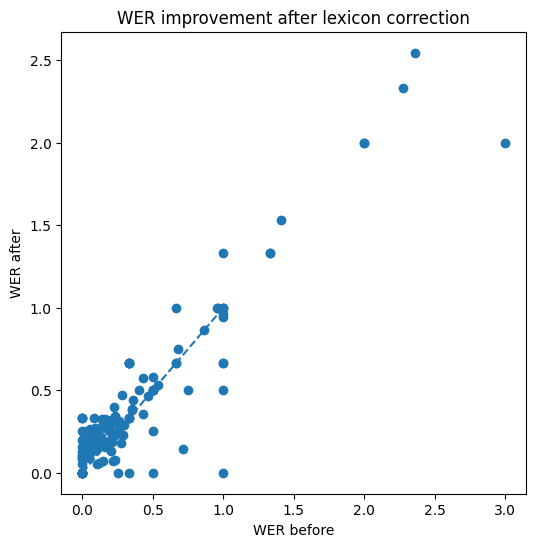

In [ ]:
# ================================
# LEXICON CORRECTION BEFORE/AFTER
# ================================
before_after = []

for _, row in df_res.iterrows():
    hyp_corr = apply_lexicon_correction(row["hyp"], med_lexicon)
    w_before = row["wer"]
    w_after = wer(row["ref"], normalize(hyp_corr))
    before_after.append([row["id"], row["variant"], w_before, w_after])

ba_df = pd.DataFrame(before_after, columns=["id", "variant", "wer_before", "wer_after"])
ba_df.to_csv(f"{RESULTS_DIR}/lexicon_correction.csv", index=False)

plt.figure(figsize=(6,6))
plt.scatter(ba_df["wer_before"], ba_df["wer_after"])
plt.xlabel("WER before")
plt.ylabel("WER after")
plt.plot([0,1], [0,1], "--")
plt.title("WER improvement after lexicon correction")
plt.savefig(f"{PLOTS_DIR}/lexicon_correction_scatter.png", dpi=200)
plt.show()


In [ ]:
# ============================
#   INSTALL
# ============================
!pip install -q tqdm

# ============================
#   IMPORTS
# ============================
import os
import re
import torch
import pandas as pd
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

from silero import silero_tts
from silero_stress import load_accentor

from faster_whisper import WhisperModel
from sentence_transformers import SentenceTransformer, util
from jiwer import wer, cer
from rapidfuzz import fuzz

# ============================
#   PATHS
# ============================
INPUT_XLSX = "/content/med_set.xlsx"  # ваш набор
WORK_DIR = "/content/eval_silero"

WAV_DIR = f"{WORK_DIR}/wav_silero"
RESULTS_DIR = f"{WORK_DIR}/results"

os.makedirs(WAV_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================
#   LOAD EXCEL
# ============================
df = pd.read_excel(INPUT_XLSX, dtype=str)
df.columns = [c.strip() for c in df.columns]

# Находим нужные колонки
id_col = next(c for c in df.columns if c.lower() in ("id", "uid", "utt_id"))
ref_col = next(c for c in df.columns if "reference" in c.lower())
short_col = next(c for c in df.columns if "short" in c.lower())
context_col = next(c for c in df.columns if "context" in c.lower())

# Словарь удобного вида
refs = {}
for _, row in df.iterrows():
    uid = str(row[id_col]).strip()
    refs[uid] = {
        "short": str(row[short_col]).strip(),
        "ref": str(row[ref_col]).strip(),
        "ctx": str(row[context_col]).strip(),
    }

# ============================
#   INIT SILERO TTS
# ============================
device = torch.device("cpu")
model, example_text = silero_tts(language='ru', speaker='v5_cis_base_nostress')
model.to(device)

accentor = load_accentor(lang='ru')

def synth_silero(text: str, out_path: str, sample_rate=48000):
    """Generate WAV via Silero."""
    stressed = accentor(text)
    audio = model.apply_tts(text=stressed, sample_rate=sample_rate)
    sf.write(out_path, audio, sample_rate)

# ============================
#   INIT WHISPER + SBERT
# ============================
whisper = WhisperModel("small", device="cpu", compute_type="float32")
sbert = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

# ============================
#   TEXT NORMALIZATION
# ============================
def normalize(t: str):
    if t is None:
        return ""
    t = t.lower()
    t = t.replace("—", " ").replace("–", " ")
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

_token_re = re.compile(r"\w+", flags=re.UNICODE)

# ============================
#   TOKEN-ENTITY PREC/REC/F1
# ============================
def entity_scores(ref: str, hyp: str):
    R = set(_token_re.findall(ref))
    H = set(_token_re.findall(hyp))

    if len(R) == 0:
        return 1.0, 1.0, 1.0

    tp = len(R & H)
    fp = len(H - R)
    fn = len(R - H)

    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)

    return prec, rec, f1

# ============================
#   MAIN LOOP WITH PROGRESS BAR
# ============================
rows = []

# Всего элементов = количество uid * 3 варианта (short/ref/ctx)
total_items = len(refs) * 3

pbar = tqdm(total=total_items, desc="Обработка записей", ncols=100)

for uid, rec in refs.items():
    for label_name, text in [
        ("short", rec["short"]),
        ("ref", rec["ref"]),
        ("ctx", rec["ctx"]),
    ]:

        pbar.set_description(f"TTS → ASR: {uid} [{label_name}]")

        out_wav = os.path.join(WAV_DIR, f"{uid}_{label_name}_silero.wav")

        # --- TTS ---
        synth_silero(text, out_wav)

        # --- ASR ---
        segments, _ = whisper.transcribe(out_wav, beam_size=5, vad_filter=True, language="ru")
        hyp = "".join(s.text for s in segments).strip()

        # Normalize
        ref_norm = normalize(text)
        hyp_norm = normalize(hyp)

        # WER, CER
        _wer = wer(ref_norm, hyp_norm)
        _cer = cer(ref_norm, hyp_norm)

        # Fuzzy similarity
        fuzzy_sim = fuzz.ratio(ref_norm, hyp_norm) / 100

        # SBERT semantic similarity
        emb_ref = sbert.encode(ref_norm, convert_to_tensor=True)
        emb_hyp = sbert.encode(hyp_norm, convert_to_tensor=True)
        semantic_sim = util.cos_sim(emb_ref, emb_hyp).item()

        # Entity metrics
        p, r, f1 = entity_scores(ref_norm, hyp_norm)

        rows.append({
            "uid": uid,
            "label_type": label_name,
            "original_text": text,
            "hyp_text": hyp,
            "ref_norm": ref_norm,
            "hyp_norm": hyp_norm,
            "WER": _wer,
            "CER": _cer,
            "Fuzzy": fuzzy_sim,
            "Semantic": semantic_sim,
            "Entity_Precision": p,
            "Entity_Recall": r,
            "Entity_F1": f1,
            "audio_file": out_wav
        })

        pbar.update(1)

pbar.close()

# ============================
#   SAVE RESULTS
# ============================
df_res = pd.DataFrame(rows)
df_res.to_csv(f"{RESULTS_DIR}/metrics_silero.csv", index=False)

print("Готово! Файл сохранён в:", f"{RESULTS_DIR}/metrics_silero.csv")


<torch_package_1>.multi_acc_v3_package.py:180: SyntaxWarning: invalid escape sequence '\^'
  text = re.sub(r'[^{}]'.format(self.symbols[3:] + '\^'), '', text)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TTS → ASR: 09-179 [ctx]: 100%|████████████████████████████████████| 150/150 [55:10<00:00, 22.07s/it]

Готово! Файл сохранён в: /content/eval_silero/results/metrics_silero.csv


In [ ]:
df_res = pd.DataFrame(rows)

In [ ]:
from scipy.stats import kruskal, mannwhitneyu

# ================================
# STATISTICS
# ================================
print(df_res.groupby("label_type")["WER"].describe())

# Kruskal-Wallis для сравнения short/ref/ctx
h, p = kruskal(
    df_res[df_res.label_type=="short"]["WER"],
    df_res[df_res.label_type=="ref"]["WER"],
    df_res[df_res.label_type=="ctx"]["WER"]
)
print("\nKruskal-Wallis:", h, p)

# pairwise Mann-Whitney U test
from scipy.stats import mannwhitneyu

pairs = [("short","ref"), ("short","ctx"), ("ref","ctx")]
for a, b in pairs:
    A = df_res[df_res.label_type == a]["WER"]
    B = df_res[df_res.label_type == b]["WER"]
    stat, pval = mannwhitneyu(A, B)
    print(f"{a} vs {b}: p={pval:.4f}")


            count      mean       std  min       25%       50%       75%  \
label_type                                                                 
ctx          50.0  0.177742  0.119500  0.0  0.083777  0.161395  0.250000   
ref          50.0  0.151997  0.120168  0.0  0.066244  0.117647  0.198387   
short        50.0  0.381143  0.477243  0.0  0.000000  0.285714  0.500000   

                 max  
label_type            
ctx         0.600000  
ref         0.533333  
short       2.000000  

Kruskal-Wallis: 4.519955996699769 0.10435278066287676
short vs ref: p=0.0687
short vs ctx: p=0.1527
ref vs ctx: p=0.1961


                            OLS Regression Results                            
Dep. Variable:                    WER   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     7.113
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           5.66e-06
Time:                        13:07:12   Log-Likelihood:                -19.183
No. Observations:                 150   AIC:                             50.37
Df Residuals:                     144   BIC:                             68.43
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.5054      0

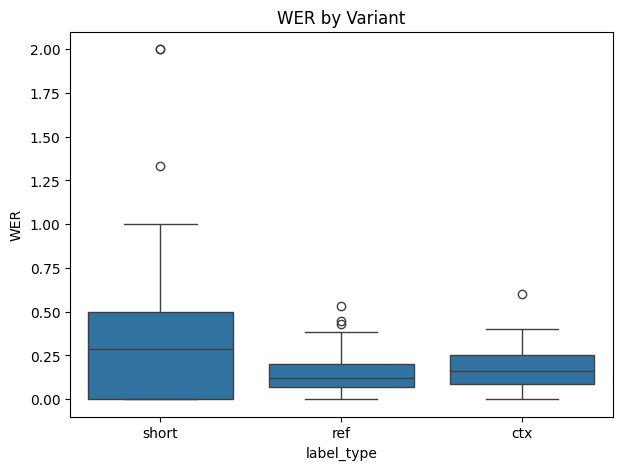

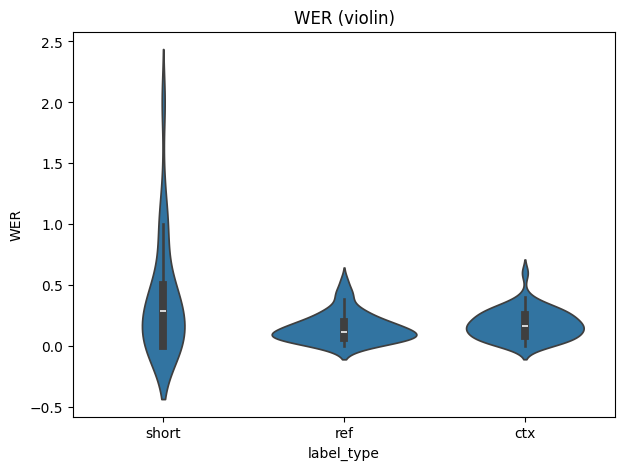

In [ ]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Подсчёт длины токенов и признаки
_token_re = re.compile(r"\w+", flags=re.UNICODE)

df_res["len_tokens"] = df_res["ref_norm"].apply(lambda s: len(_token_re.findall(s)))
df_res["has_latin"] = df_res["ref_norm"].apply(lambda s: bool(re.search(r"[A-Za-z]", s)))
df_res["has_digits"] = df_res["ref_norm"].apply(lambda s: bool(re.search(r"\d", s)))

# Добавим duration (секунды) из аудио
import soundfile as sf
def get_duration(path):
    audio, sr = sf.read(path)
    return len(audio)/sr

df_res["duration"] = df_res["audio_file"].apply(get_duration)

# OLS регрессия
model = smf.ols("WER ~ len_tokens + has_latin + has_digits + duration + Semantic", data=df_res).fit()
print(model.summary())

# ================================
# VISUALIZATIONS
# ================================
plt.figure(figsize=(7,5))
sns.boxplot(data=df_res, x="label_type", y="WER")
plt.title("WER by Variant")
plt.show()

plt.figure(figsize=(7,5))
sns.violinplot(data=df_res, x="label_type", y="WER")
plt.title("WER (violin)")
plt.show()

In [ ]:
# ================================
# TOP TOKEN SUBSTITUTIONS (GLOBAL)
# ================================
import difflib
from collections import Counter
import re
import pandas as pd

def collect_substitutions(ref, hyp):
    r_tok = re.findall(r"\w+", ref)
    h_tok = re.findall(r"\w+", hyp)
    seq = difflib.SequenceMatcher(a=r_tok, b=h_tok)
    subs = []
    for tag, i1, i2, j1, j2 in seq.get_opcodes():
        if tag == "replace":
            for a, b in zip(r_tok[i1:i2], h_tok[j1:j2]):
                subs.append((a.lower(), b.lower()))
    return subs

all_subs = []
for _, row in df_res.iterrows():
    all_subs.extend(collect_substitutions(row["ref_norm"], row["hyp_norm"]))

top50 = Counter(all_subs).most_common(50)
top50_df = pd.DataFrame(top50, columns=["pair", "count"])
top50_df["ref"] = top50_df["pair"].apply(lambda x: x[0])
top50_df["hyp"] = top50_df["pair"].apply(lambda x: x[1])
top50_df.drop(columns=["pair"], inplace=True)

# Сохраняем результат
top50_df.head()

,count,ref,hyp
0,6,гамк,гаммк
1,4,которое,которая
2,4,аутоантитела,аута
3,3,вальпроевая,вальпраивая
4,3,исследование,исследования


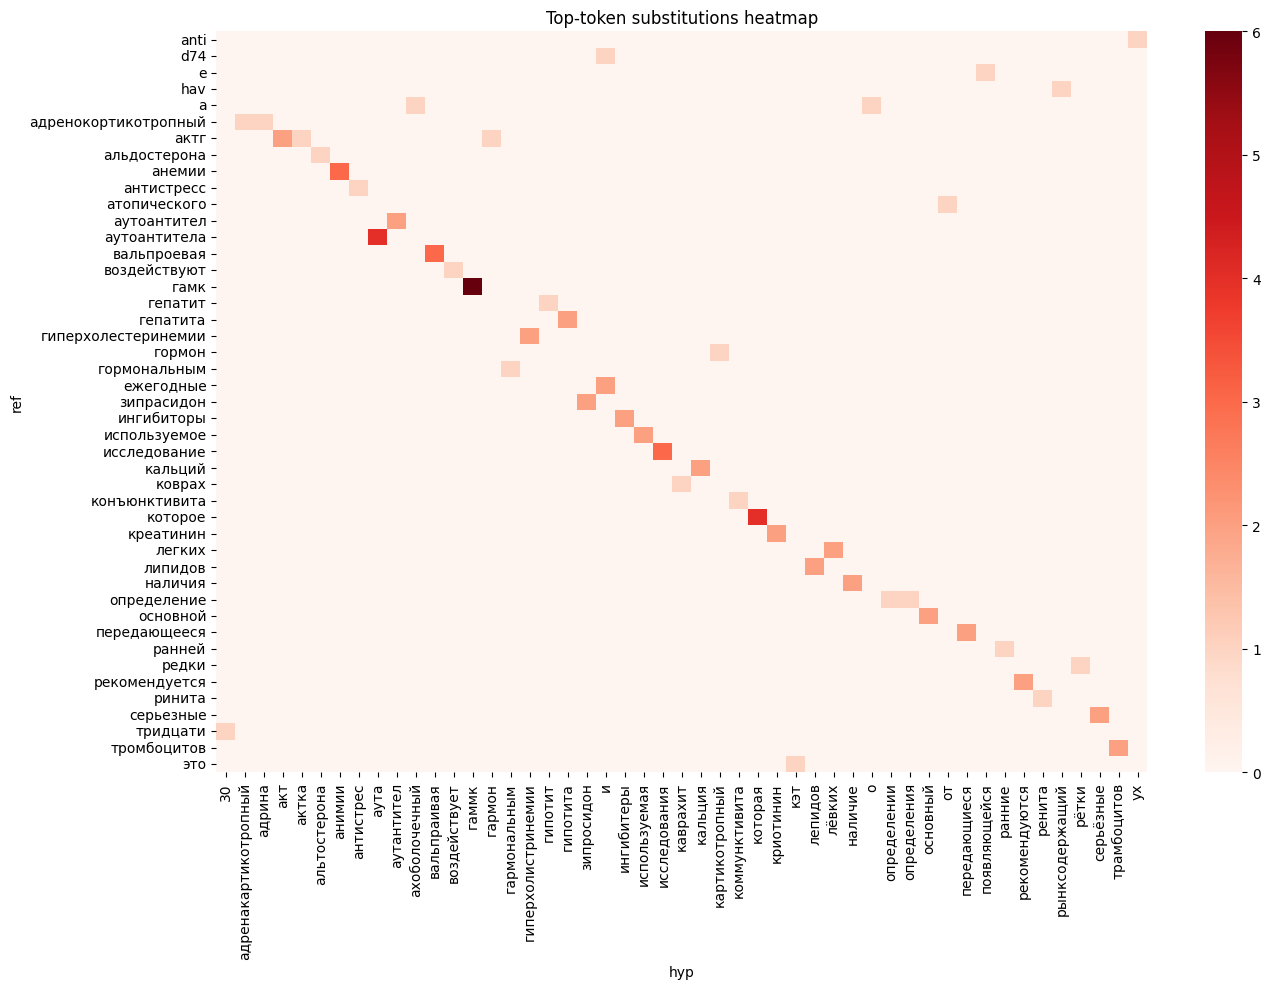

In [ ]:
# ================================
# HEATMAP TOP SUBSTITUTIONS
# ================================
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Создаём сводную таблицу
pivot = top50_df.pivot_table(index="ref", columns="hyp", values="count", fill_value=0)

# Строим тепловую карту
plt.figure(figsize=(14, 10))
sns.heatmap(pivot, annot=False, cmap="Reds")
plt.title("Top-token substitutions heatmap")
plt.tight_layout()
plt.show()

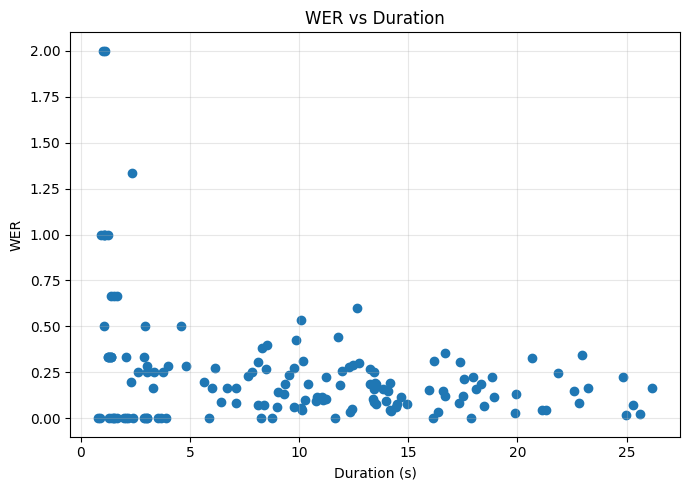

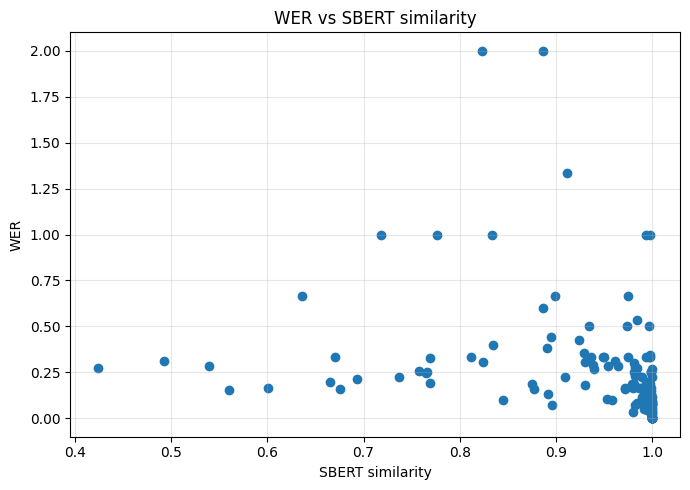

In [ ]:
# ================================
# SCATTERS
# ================================
import matplotlib.pyplot as plt
import os

# WER vs Duration
plt.figure(figsize=(7,5))
plt.scatter(df_res["duration"], df_res["WER"])
plt.xlabel("Duration (s)")
plt.ylabel("WER")
plt.title("WER vs Duration")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# WER vs SBERT similarity
plt.figure(figsize=(7,5))
plt.scatter(df_res["Semantic"], df_res["WER"])
plt.xlabel("SBERT similarity")
plt.ylabel("WER")
plt.title("WER vs SBERT similarity")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ================================
# BUILD MEDICAL LEXICON
# ================================
_token_re = re.compile(r"\w+", flags=re.UNICODE)
med_lexicon = set()

def add_lex(text):
    if text:
        for t in _token_re.findall(text.lower()):
            if len(t) > 2:
                med_lexicon.add(t)

for r in refs.values():
    add_lex(r["short"])
    add_lex(r["ref"])
    add_lex(r["ctx"])

print("Lexicon size:", len(med_lexicon))


Lexicon size: 1346


/tmp/ipython-input-2681862507.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mederr_df, x="errors", y="token", palette="Reds_r")


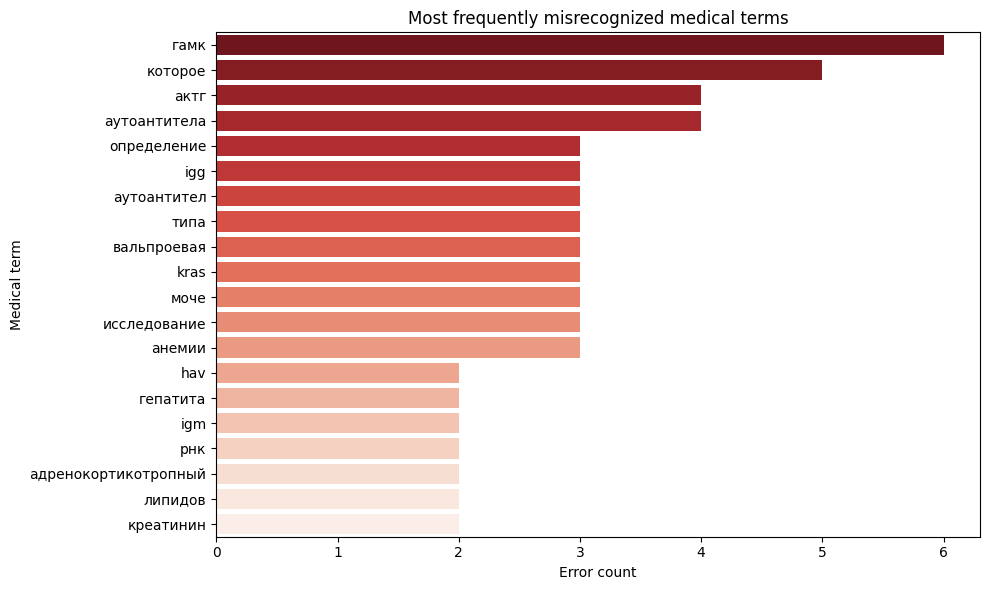

In [ ]:
# ================================
# TOKEN ERROR RATE FOR MEDICAL TERMS (Silero)
# ================================
import re
from collections import Counter
import os
import matplotlib.pyplot as plt
import seaborn as sns

med_errors = Counter()

for _, row in df_res.iterrows():
    ref_tokens = re.findall(r"\w+", row["ref_norm"])
    hyp_tokens = re.findall(r"\w+", row["hyp_norm"])
    for t in ref_tokens:
        if t in med_lexicon:
            if t not in hyp_tokens:
                med_errors[t] += 1

top20_med_errors = med_errors.most_common(20)

mederr_df = pd.DataFrame(top20_med_errors, columns=["token", "errors"])

plt.figure(figsize=(10,6))
sns.barplot(data=mederr_df, x="errors", y="token", palette="Reds_r")
plt.title("Most frequently misrecognized medical terms")
plt.xlabel("Error count")
plt.ylabel("Medical term")
plt.tight_layout()
plt.show()

In [ ]:
def apply_lexicon_correction(hyp: str, lexicon: set) -> str:
    """Простейшая корректировка гипотезы ASR по словарю.
    Заменяем слова, которых нет в lexicon, на ближайшие по форме из lexicon (например, через Levenshtein)."""
    import difflib
    corrected_tokens = []
    tokens = re.findall(r"\w+", hyp.lower())
    for t in tokens:
        if t in lexicon:
            corrected_tokens.append(t)
        else:
            # Найти ближайшее слово из словаря
            matches = difflib.get_close_matches(t, lexicon, n=1, cutoff=0.8)
            if matches:
                corrected_tokens.append(matches[0])
            else:
                corrected_tokens.append(t)
    return " ".join(corrected_tokens)


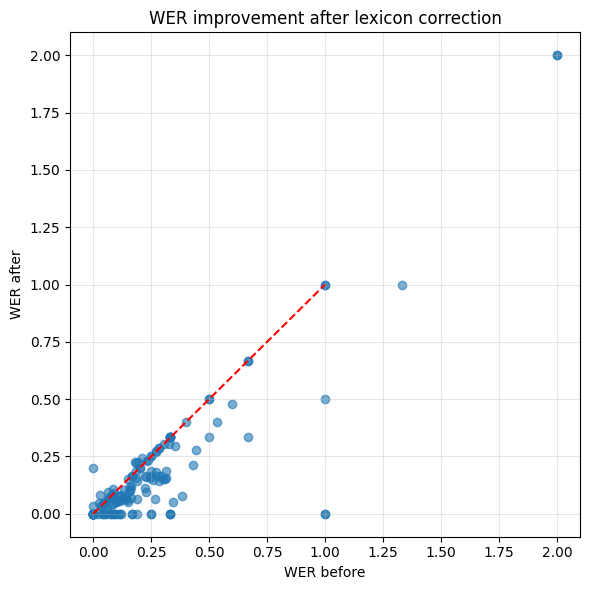

In [ ]:
# ================================
# LEXICON CORRECTION BEFORE/AFTER (Silero)
# ================================
before_after = []

for _, row in df_res.iterrows():
    # Применяем коррекцию словаря к hyp_norm
    hyp_corr = apply_lexicon_correction(row["hyp_norm"], med_lexicon)

    # WER до и после
    w_before = row["WER"]
    w_after = wer(row["ref_norm"], normalize(hyp_corr))

    before_after.append([row["uid"], row["label_type"], w_before, w_after])

ba_df = pd.DataFrame(before_after, columns=["uid", "label_type", "WER_before", "WER_after"])
ba_df.to_csv(f"{RESULTS_DIR}/lexicon_correction.csv", index=False)

# Визуализация
plt.figure(figsize=(6,6))
plt.scatter(ba_df["WER_before"], ba_df["WER_after"], alpha=0.6)
plt.plot([0,1], [0,1], "--", color="red")
plt.xlabel("WER before")
plt.ylabel("WER after")
plt.title("WER improvement after lexicon correction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Дополнительный анализ


In [ ]:
pip install vosk-tts faster-whisper sentence-transformers jiwer rapidfuzz soundfile pandas openpyxl matplotlib seaborn scipy statsmodels tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 88.5 MB/s eta 0:00:00


In [ ]:
# ============================================
#  UNIFIED TTS EVALUATION PIPELINE
#  Supports: Silero, Vosk, Existing Audio (Alice)
# ============================================
import os
import re
import torch
import pandas as pd
import numpy as np
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
from glob import glob

# TTS engines
from vosk_tts import Model as VoskModel, Synth as VoskSynth
import torch.hub

# ASR and metrics
from faster_whisper import WhisperModel
from sentence_transformers import SentenceTransformer, util
from jiwer import wer, cer, process_words
from rapidfuzz import fuzz
from scipy.stats import kruskal, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
#  CONFIGURATION
# ============================================
INPUT_XLSX = "/content/med_set.xlsx"
WORK_DIR = "/content/eval_tts_comparison"

# Subdirectories for each engine
SILERO_DIR = os.path.join(WORK_DIR, "wav_silero")
VOSK_DIR = os.path.join(WORK_DIR, "wav_vosk")
ALICE_DIR = os.path.join(WORK_DIR, "wav_alice")  # converted from mp4
RESULTS_DIR = os.path.join(WORK_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")

for d in [SILERO_DIR, VOSK_DIR, ALICE_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Settings
WHISPER_MODEL = "small"
DEVICE = "cpu"
COMPUTE_TYPE = "float32"
SAMPLE_RATE = 24000

print("Directories created.")
print(f"Work dir: {WORK_DIR}")

# ============================================
#  LOAD DATASET
# ============================================
df = pd.read_excel(INPUT_XLSX, dtype=str)
df.columns = [c.strip() for c in df.columns]

id_col = next(c for c in df.columns if c.lower() in ("id", "uid", "utt_id"))
ref_col = next(c for c in df.columns if "reference" in c.lower())
short_col = next(c for c in df.columns if "short" in c.lower())
context_col = next(c for c in df.columns if "context" in c.lower())

refs = {}
for _, row in df.iterrows():
    uid = str(row[id_col]).strip()
    refs[uid] = {
        "short": str(row[short_col]).strip(),
        "ref": str(row[ref_col]).strip(),
        "ctx": str(row[context_col]).strip(),
    }

print(f"Loaded {len(refs)} records from dataset.")

# ============================================
#  INITIALIZE MODELS
# ============================================

# --- Whisper ASR ---
print("Loading Whisper...")
whisper = WhisperModel(WHISPER_MODEL, device=DEVICE, compute_type=COMPUTE_TYPE)

# --- SBERT for semantic similarity ---
print("Loading SBERT...")
sbert = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# --- Silero TTS ---
print("Loading Silero TTS...")
torch.set_num_threads(4)
silero_model, _ = torch.hub.load(
    repo_or_dir='snakers4/silero-models',
    model='silero_tts',
    language='ru',
    speaker='aidar_v2'
)

# --- Vosk TTS ---
print("Loading Vosk TTS...")
vosk_model = VoskModel(model_name="vosk-model-tts-ru-0.9-multi")
vosk_synth = VoskSynth(vosk_model)

print("All models loaded successfully.")

# ============================================
#  TEXT NORMALIZATION & UTILS
# ============================================
_token_re = re.compile(r"\w+", flags=re.UNICODE)

def normalize(t: str):
    if not t:
        return ""
    t = t.lower()
    t = t.replace("—", " ").replace("–", " ")
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

def entity_scores(ref: str, hyp: str):
    """Calculate entity precision, recall, F1 based on token overlap."""
    R = set(_token_re.findall(ref))
    H = set(_token_re.findall(hyp))

    if len(R) == 0:
        return 1.0, 1.0, 1.0

    tp = len(R & H)
    fp = len(H - R)
    fn = len(R - H)

    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)

    return prec, rec, f1

# ============================================
#  TTS GENERATION FUNCTIONS
# ============================================

def synth_silero(text: str, out_path: str, speaker: str = 'aidar'):
    """Generate audio using Silero TTS."""
    try:
        audio = silero_model.apply_tts(
            text=text,
            speaker=speaker,
            sample_rate=SAMPLE_RATE
        )
        sf.write(out_path, audio, SAMPLE_RATE)
        return True
    except Exception as e:
        print(f"Silero error for '{text[:30]}...': {e}")
        return False

def synth_vosk(text: str, out_path: str, speaker_id: int = 2):
    """Generate audio using Vosk TTS."""
    try:
        vosk_synth.synth(text, out_path, speaker_id=speaker_id)
        return True
    except Exception as e:
        print(f"Vosk error for '{text[:30]}...': {e}")
        return False

def convert_alice_mp4(mp4_path: str, out_wav: str):
    """Convert existing Alice mp4 to wav using ffmpeg."""
    import subprocess
    cmd = [
        "ffmpeg", "-y", "-i", mp4_path,
        "-ar", str(SAMPLE_RATE), "-ac", "1", "-vn",
        "-sample_fmt", "s16", out_wav
    ]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except subprocess.CalledProcessError as e:
        print(f"FFmpeg error for {mp4_path}: {e}")
        return False

# ============================================
#  MAP ALICE FILES (if mp4 files exist)
# ============================================
def extract_id_variant(fname: str):
    """Parse filename like '02-005_1.mp4' -> ('02-005', '1')."""
    m = re.match(r"([0-9]{2}-[0-9]{3})[_\-]([123])", fname)
    if m:
        return m.group(1), m.group(2)
    # Alternative patterns
    m = re.match(r"([0-9]{2,4})[_\-\.]([123])", fname)
    if m:
        return m.group(1), m.group(2)
    return None, None

alice_files = {}  # (uid, variant) -> mp4_path
mp4_paths = glob(os.path.join("/content", "*.mp4")) + glob(os.path.join(".", "*.mp4"))

for p in mp4_paths:
    fname = Path(p).name
    uid, var = extract_id_variant(fname)
    if uid and var and uid in refs:
        alice_files[(uid, var)] = p

print(f"Found {len(alice_files)} Alice mp4 files matching dataset.")

# ============================================
#  MAIN EVALUATION LOOP
# ============================================

def evaluate_audio(audio_path: str, ref_text: str, engine: str, uid: str, label_type: str):
    """Run ASR and compute all metrics for a given audio file."""

    # Transcribe
    segments, _ = whisper.transcribe(
        audio_path,
        beam_size=5,
        vad_filter=True,
        language="ru"
    )
    hyp = "".join(s.text for s in segments).strip()

    # Normalize
    ref_norm = normalize(ref_text)
    hyp_norm = normalize(hyp)

    # Basic metrics
    _wer = wer(ref_norm, hyp_norm) if ref_norm else 1.0
    _cer = cer(ref_norm, hyp_norm) if ref_norm else 1.0

    # Word-level errors (S/D/I)
    if ref_norm:
        measures = process_words(ref_norm, hyp_norm)
        subs, dels, ins = measures.substitutions, measures.deletions, measures.insertions
    else:
        subs = dels = ins = 0

    # Fuzzy similarity
    fuzzy_sim = fuzz.ratio(ref_norm, hyp_norm) / 100

    # Semantic similarity
    if ref_norm and hyp_norm:
        emb_ref = sbert.encode(ref_norm, convert_to_tensor=True)
        emb_hyp = sbert.encode(hyp_norm, convert_to_tensor=True)
        semantic_sim = util.cos_sim(emb_ref, emb_hyp).item()
    else:
        semantic_sim = 0.0

    # Entity metrics
    p, r, f1 = entity_scores(ref_norm, hyp_norm)

    # Duration
    try:
        audio, sr = sf.read(audio_path)
        duration = len(audio) / sr
    except:
        duration = 0.0

    return {
        "uid": uid,
        "variant": label_type,  # short/ref/ctx
        "engine": engine,
        "ref_text": ref_text,
        "hyp_text": hyp,
        "ref_norm": ref_norm,
        "hyp_norm": hyp_norm,
        "WER": _wer,
        "CER": _cer,
        "Substitutions": subs,
        "Deletions": dels,
        "Insertions": ins,
        "Fuzzy_Sim": fuzzy_sim,
        "Semantic_Sim": semantic_sim,
        "Entity_Precision": p,
        "Entity_Recall": r,
        "Entity_F1": f1,
        "Duration_sec": duration,
        "audio_path": audio_path
    }

# ============================================
#  PROCESS ALL ENGINES
# ============================================

all_results = []
label_map = {"short": "1", "ref": "2", "ctx": "3"}

# --- 1. SILERO TTS ---
print("\n" + "="*50)
print("PROCESSING SILERO TTS")
print("="*50)

total_silero = len(refs) * 3
pbar = tqdm(total=total_silero, desc="Silero")

for uid, rec in refs.items():
    for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
        out_wav = os.path.join(SILERO_DIR, f"{uid}_{label_name}_silero.wav")

        if synth_silero(text, out_wav):
            result = evaluate_audio(out_wav, text, "silero", uid, label_name)
            all_results.append(result)

        pbar.update(1)
pbar.close()

# --- 2. VOSK TTS ---
print("\n" + "="*50)
print("PROCESSING VOSK TTS")
print("="*50)

total_vosk = len(refs) * 3
pbar = tqdm(total=total_vosk, desc="Vosk")

for uid, rec in refs.items():
    for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
        out_wav = os.path.join(VOSK_DIR, f"{uid}_{label_name}_vosk.wav")

        # Try different speakers for variety (0-3 available in multi model)
        speaker_id = 2 if label_name == "ref" else (0 if label_name == "short" else 1)

        if synth_vosk(text, out_wav, speaker_id=speaker_id):
            result = evaluate_audio(out_wav, text, "vosk", uid, label_name)
            all_results.append(result)

        pbar.update(1)
pbar.close()

# --- 3. ALICE (EXISTING AUDIO) ---
print("\n" + "="*50)
print("PROCESSING ALICE (EXISTING AUDIO)")
print("="*50)

alice_converted = []
for (uid, var), mp4_path in alice_files.items():
    # Map variant number to label
    var_map = {"1": "short", "2": "ref", "3": "ctx"}
    label_name = var_map.get(var, "ref")

    out_wav = os.path.join(ALICE_DIR, f"{uid}_{label_name}_alice.wav")

    if convert_alice_mp4(mp4_path, out_wav):
        text = refs[uid][label_name]
        result = evaluate_audio(out_wav, text, "alice", uid, label_name)
        all_results.append(result)
        alice_converted.append((uid, var))

print(f"Processed {len(alice_converted)} Alice files.")

# ============================================
#  SAVE RESULTS
# ============================================

df_results = pd.DataFrame(all_results)
df_results.to_csv(os.path.join(RESULTS_DIR, "all_metrics_comparison.csv"), index=False)
print(f"\nSaved results: {len(df_results)} total evaluations")

# ============================================
#  ANALYSIS & COMPARISON
# ============================================

print("\n" + "="*50)
print("SUMMARY STATISTICS BY ENGINE")
print("="*50)

summary = df_results.groupby("engine").agg({
    "WER": ["mean", "median", "std", "count"],
    "CER": ["mean", "median"],
    "Semantic_Sim": ["mean"],
    "Entity_F1": ["mean"],
    "Duration_sec": ["mean"]
}).round(4)

print(summary)

# Save summary
summary.to_csv(os.path.join(RESULTS_DIR, "summary_by_engine.csv"))

# ============================================
#  STATISTICAL TESTS
# ============================================

print("\n" + "="*50)
print("STATISTICAL COMPARISON (WER)")
print("="*50)

engines = df_results["engine"].unique()
if len(engines) >= 2:
    # Kruskal-Wallis test
    groups = [df_results[df_results.engine==e]["WER"].values for e in engines]
    h, p = kruskal(*groups)
    print(f"Kruskal-Wallis H={h:.4f}, p={p:.4g}")

    with open(os.path.join(RESULTS_DIR, "statistical_tests.txt"), "w") as f:
        f.write(f"Kruskal-Wallis test for WER across engines:\n")
        f.write(f"H = {h:.4f}, p = {p:.4g}\n\n")

        # Pairwise Mann-Whitney U tests
        f.write("Pairwise Mann-Whitney U tests:\n")
        for i, e1 in enumerate(engines):
            for e2 in engines[i+1:]:
                a = df_results[df_results.engine==e1]["WER"]
                b = df_results[df_results.engine==e2]["WER"]
                stat, pval = mannwhitneyu(a, b)
                print(f"  {e1} vs {e2}: p={pval:.4f}")
                f.write(f"{e1} vs {e2}: U={stat:.2f}, p={pval:.4g}\n")

# ============================================
#  VISUALIZATIONS
# ============================================

# 1. WER comparison boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, x="engine", y="WER", showmeans=True)
plt.title("WER Distribution by TTS Engine")
plt.ylabel("Word Error Rate")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "wer_by_engine_boxplot.png"), dpi=200)
plt.show()

# 2. Semantic similarity comparison
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_results, x="engine", y="Semantic_Sim", showmeans=True)
plt.title("Semantic Similarity by TTS Engine")
plt.ylabel("Cosine Similarity (SBERT)")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "semantic_sim_by_engine.png"), dpi=200)
plt.show()

# 3. Entity F1 comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="engine", y="Entity_F1", ci="sd")
plt.title("Entity F1 Score by TTS Engine")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "entity_f1_by_engine.png"), dpi=200)
plt.show()

# 4. WER by text type (variant) and engine
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_results, x="variant", y="WER", hue="engine")
plt.title("WER by Text Type and TTS Engine")
plt.xlabel("Text Type (short=1, ref=2, ctx=3)")
plt.ylabel("Word Error Rate")
plt.legend(title="Engine")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "wer_by_variant_and_engine.png"), dpi=200)
plt.show()

# 5. Duration comparison
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_results, x="engine", y="Duration_sec")
plt.title("Audio Duration Distribution by TTS Engine")
plt.ylabel("Duration (seconds)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "duration_by_engine.png"), dpi=200)
plt.show()

print(f"\nAll plots saved to: {PLOTS_DIR}")

# ============================================
#  DETAILED COMPARISON TABLE
# ============================================

print("\n" + "="*50)
print("DETAILED COMPARISON BY TEXT TYPE")
print("="*50)

detailed = df_results.groupby(["engine", "variant"]).agg({
    "WER": "mean",
    "CER": "mean",
    "Semantic_Sim": "mean",
    "Entity_F1": "mean",
    "count": "size"
}).round(4)

print(detailed)
detailed.to_csv(os.path.join(RESULTS_DIR, "detailed_by_engine_variant.csv"))

# ============================================
#  ERROR ANALYSIS: TOP MISRECOGNIZED TOKENS
# ============================================

from collections import Counter
import difflib

def get_substitutions(ref: str, hyp: str):
    """Extract substitution errors."""
    r_toks = _token_re.findall(ref)
    h_toks = _token_re.findall(hyp)
    sm = difflib.SequenceMatcher(a=r_toks, b=h_toks)
    subs = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "replace":
            for a, b in zip(r_toks[i1:i2], h_toks[j1:j2]):
                subs.append((a.lower(), b.lower()))
    return subs

# Collect errors per engine
for engine in df_results["engine"].unique():
    engine_df = df_results[df_results.engine == engine]
    all_subs = []

    for _, row in engine_df.iterrows():
        all_subs.extend(get_substitutions(row["ref_norm"], row["hyp_norm"]))

    top_errors = Counter(all_subs).most_common(20)

    err_df = pd.DataFrame(top_errors, columns=["pair", "count"])
    err_df["expected"] = err_df["pair"].apply(lambda x: x[0])
    err_df["recognized"] = err_df["pair"].apply(lambda x: x[1])
    err_df.drop("pair", axis=1, inplace=True)

    err_df.to_csv(os.path.join(RESULTS_DIR, f"top_errors_{engine}.csv"), index=False)
    print(f"\nTop 5 errors for {engine}:")
    print(err_df.head())

print("\n" + "="*50)
print("EVALUATION COMPLETE")
print(f"Results directory: {RESULTS_DIR}")
print("="*50)

PyTorch version: 2.9.0+cpu

Checking dependencies...
  ✓ soundfile
  ✓ pandas
  ✓ numpy
  ✓ tqdm
  ✓ jiwer
  ✓ rapidfuzz
  ✓ scipy
  ✓ matplotlib
  ✓ seaborn

Reinstalling problematic packages...
  → Installing faster-whisper...
  ✓ faster-whisper installed
  → Installing sentence-transformers...
  ✓ sentence-transformers installed
  ✓ vosk-tts

Importing modules...
  ✓ faster_whisper
  ✓ sentence_transformers
  ✓ jiwer
  ✓ rapidfuzz
  ✓ scipy
  ✓ matplotlib/seaborn
  ✓ vosk_tts

Инициализация завершена

Базовая директория: /content
Excel файл: /content/med_set.xlsx (exists: True)
Папка с Алисой: /content (exists: True)
Device: cpu, Compute type: float32

Загрузка датасета...
✓ Загружено 50 записей

Загрузка моделей...
✓ Whisper загружен


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ SBERT загружен


Using cache found in /root/.cache/torch/hub/snakers4_silero-models_master


...

  ✗ Vosk: '4'

ALICE


Alice: 100%|██████████| 29/29 [07:22<00:00, 15.25s/it]



✓ Сохранено: 125 записей

АРХИВАЦИЯ


✓ Архив: vosk_audio.zip (27.3 МБ)


✓ Архив: alice_audio.zip (3.9 МБ)

ГРАФИКИ


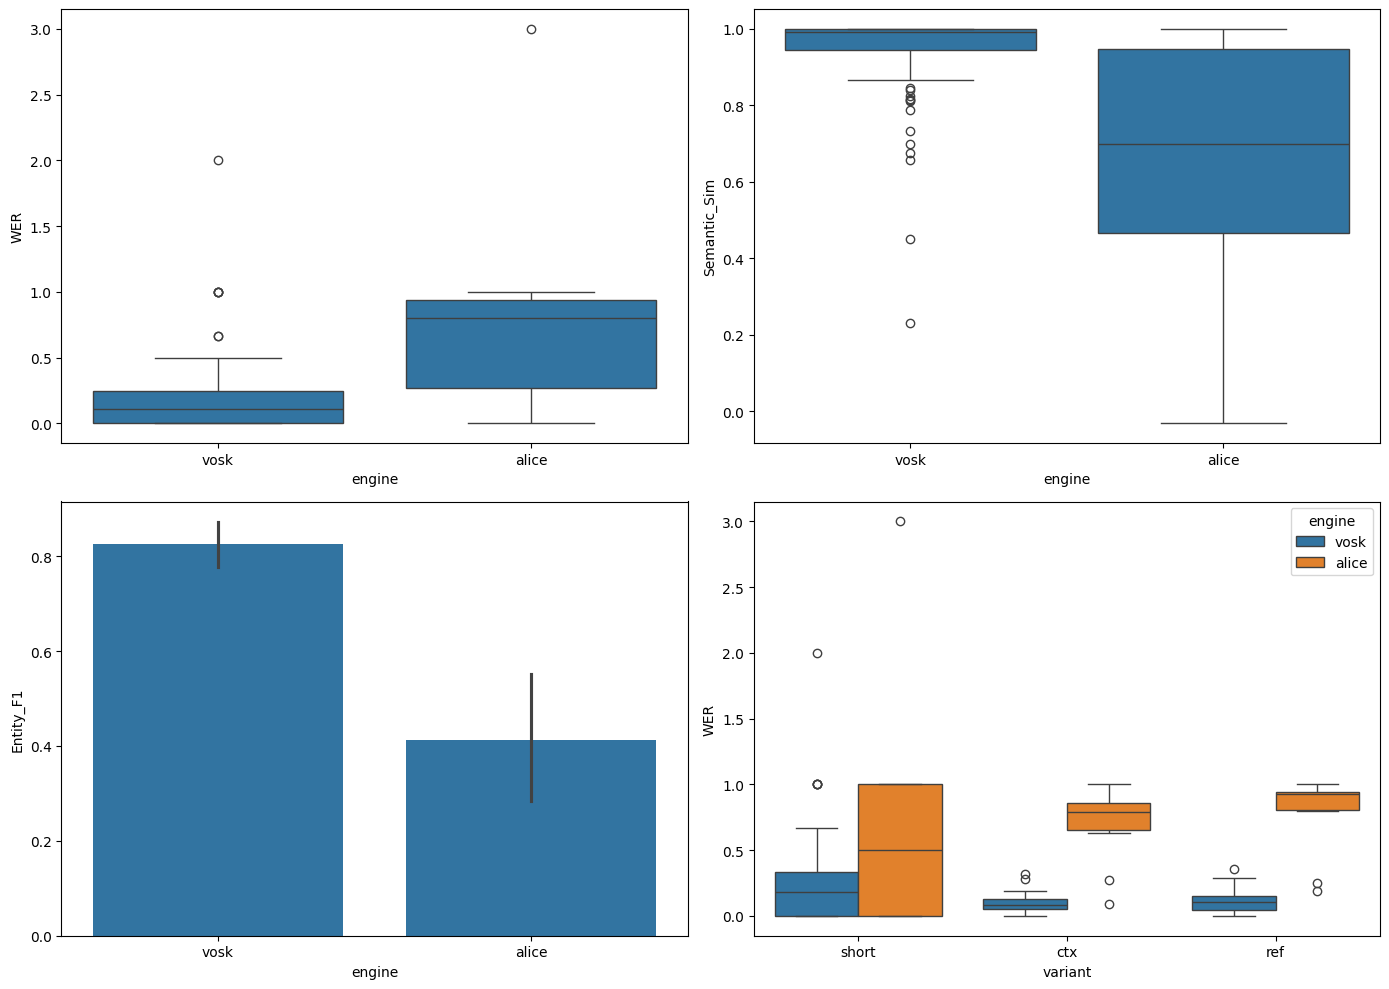


Сводка:
           WER             CER Semantic_Sim Entity_F1
          mean     std    mean         mean      mean
engine                                               
alice   0.7268  0.5648  0.4923       0.6491    0.4123
vosk    0.1887  0.2934  0.0322       0.9411    0.8260

✅ ГОТОВО: 125 файлов обработано


In [ ]:
# ============================================
#  UNIFIED TTS EVALUATION PIPELINE (LOCAL)
#  Without torchaudio, with fixed dependencies
# ============================================

import os
import re
import shutil
import subprocess
import sys
import warnings
from pathlib import Path
from collections import Counter
from glob import glob
import difflib
import zipfile
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import soundfile as sf
import torch

print(f"PyTorch version: {torch.__version__}")

warnings.filterwarnings('ignore')

def install_or_reinstall(package: str, force: bool = False):
    """Install or reinstall package if needed."""
    try:
        if force:
            raise ImportError("Force reinstall")
        __import__(package.replace("-", "_"))
        print(f"  ✓ {package}")
        return True
    except ImportError:
        print(f"  → Installing {package}...")
        try:
            # Сначала удаляем, если был
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", package],
                                stderr=subprocess.DEVNULL, stdout=subprocess.DEVNULL)
            # Устанавливаем заново
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", package])
            print(f"  ✓ {package} installed")
            return True
        except Exception as e:
            print(f"  ✗ Failed: {e}")
            return False
    except Exception as e:
        print(f"  ✗ Error with {package}: {e}")
        return False

print("\nChecking dependencies...")

# Сначала базовые пакеты (без проблемных)
base_packages = [
    ("soundfile", False),
    ("pandas", False),
    ("numpy", False),
    ("tqdm", False),
    ("jiwer", False),
    ("rapidfuzz", False),
    ("scipy", False),
    ("matplotlib", False),
    ("seaborn", False),
]

for pkg, force in base_packages:
    install_or_reinstall(pkg, force)

# Проблемные пакеты - переустанавливаем принудительно
print("\nReinstalling problematic packages...")
problematic = [
    ("faster-whisper", True),
    ("sentence-transformers", True),
    ("vosk-tts", False),
]

for pkg, force in problematic:
    install_or_reinstall(pkg, force)

# Теперь импортируем всё
print("\nImporting modules...")

WhisperModel = None
try:
    from faster_whisper import WhisperModel
    print("  ✓ faster_whisper")
except Exception as e:
    print(f"  ✗ faster_whisper: {e}")

SentenceTransformer = None
util = None
try:
    from sentence_transformers import SentenceTransformer, util
    print("  ✓ sentence_transformers")
except Exception as e:
    print(f"  ✗ sentence_transformers: {e}")

try:
    from jiwer import wer, cer, process_words
    print("  ✓ jiwer")
except Exception as e:
    print(f"  ✗ jiwer: {e}")
    wer = cer = process_words = None

try:
    from rapidfuzz import fuzz
    print("  ✓ rapidfuzz")
except Exception as e:
    print(f"  ✗ rapidfuzz: {e}")
    fuzz = None

try:
    from scipy.stats import kruskal, mannwhitneyu
    print("  ✓ scipy")
except Exception as e:
    print(f"  ✗ scipy: {e}")
    kruskal = mannwhitneyu = None

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("  ✓ matplotlib/seaborn")
except Exception as e:
    print(f"  ✗ matplotlib/seaborn: {e}")
    plt = sns = None

VoskModel = None
VoskSynth = None
try:
    from vosk_tts import Model as VoskModel, Synth as VoskSynth
    print("  ✓ vosk_tts")
except Exception as e:
    print(f"  ✗ vosk_tts: {e}")

from tqdm import tqdm

print("\n" + "="*60)
print("Инициализация завершена")
print("="*60)

# ============================================
#  CONFIGURATION
# ============================================

BASE_DIR = Path("/content")

INPUT_XLSX = BASE_DIR / "med_set.xlsx"
ALICE_MP4_DIR = BASE_DIR

WORK_DIR = BASE_DIR / "eval_tts_comparison"
SILERO_DIR = WORK_DIR / "wav_silero"
VOSK_DIR = WORK_DIR / "wav_vosk"
ALICE_WAV_DIR = WORK_DIR / "wav_alice"
RESULTS_DIR = WORK_DIR / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
DOWNLOAD_DIR = WORK_DIR / "download_packages"

for d in [WORK_DIR, SILERO_DIR, VOSK_DIR, ALICE_WAV_DIR, RESULTS_DIR, PLOTS_DIR, DOWNLOAD_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nБазовая директория: {BASE_DIR}")
print(f"Excel файл: {INPUT_XLSX} (exists: {INPUT_XLSX.exists()})")
print(f"Папка с Алисой: {ALICE_MP4_DIR} (exists: {ALICE_MP4_DIR.exists()})")

WHISPER_MODEL = "small"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
COMPUTE_TYPE = "float16" if DEVICE == "cuda" else "float32"
SAMPLE_RATE = 24000

print(f"Device: {DEVICE}, Compute type: {COMPUTE_TYPE}")

# ============================================
#  ARCHIVE UTILITIES
# ============================================

def create_zip_archive(source_dir: Path, output_zip: Path, file_pattern: str = "*.wav") -> Optional[Path]:
    wav_files = list(source_dir.glob(file_pattern))
    if not wav_files:
        return None

    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for wav_file in tqdm(wav_files, desc=f"Архивация", leave=False):
            zipf.write(wav_file, arcname=wav_file.name)

    file_size_mb = output_zip.stat().st_size / (1024 * 1024)
    print(f"✓ Архив: {output_zip.name} ({file_size_mb:.1f} МБ)")
    return output_zip

# ============================================
#  LOAD DATASET
# ============================================

print(f"\n{'='*60}")
print("Загрузка датасета...")
print(f"{'='*60}")

if not INPUT_XLSX.exists():
    raise FileNotFoundError(f"Файл не найден: {INPUT_XLSX}")

df = pd.read_excel(INPUT_XLSX, dtype=str)
df.columns = [c.strip() for c in df.columns]

def find_column(columns: List[str], patterns: List[str]) -> str:
    for pattern in patterns:
        for col in columns:
            col_lower = col.lower().replace(" ", "_")
            if pattern in col_lower:
                return col
    raise ValueError(f"Колонка не найдена: {patterns}")

try:
    id_col = find_column(df.columns.tolist(), ["id", "uid", "utt_id"])
    ref_col = find_column(df.columns.tolist(), ["reference", "utterance"])
    short_col = find_column(df.columns.tolist(), ["short", "brief"])
    context_col = find_column(df.columns.tolist(), ["context", "full"])
except ValueError as e:
    print(f"Доступные колонки: {df.columns.tolist()}")
    raise e

refs: Dict[str, Dict[str, str]] = {}
for _, row in df.iterrows():
    uid = str(row[id_col]).strip()
    if uid and uid.lower() != 'nan':
        refs[uid] = {
            "short": str(row[short_col]).strip() if pd.notna(row[short_col]) else "",
            "ref": str(row[ref_col]).strip() if pd.notna(row[ref_col]) else "",
            "ctx": str(row[context_col]).strip() if pd.notna(row[context_col]) else "",
        }

print(f"✓ Загружено {len(refs)} записей")

# ============================================
#  INITIALIZE MODELS
# ============================================

print(f"\n{'='*60}")
print("Загрузка моделей...")
print(f"{'='*60}")

if WhisperModel is None:
    raise RuntimeError("WhisperModel не доступен! Установите: pip install faster-whisper")

whisper = WhisperModel(WHISPER_MODEL, device=DEVICE, compute_type=COMPUTE_TYPE)
print("✓ Whisper загружен")

if SentenceTransformer is None:
    raise RuntimeError("SBERT не доступен!")

sbert = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
print("✓ SBERT загружен")

torch.set_num_threads(4)
SILERO_AVAILABLE = False
try:
    silero_model, _ = torch.hub.load(
        repo_or_dir='snakers4/silero-models',
        model='silero_tts',
        language='ru',
        speaker='aidar_v2',
        trust_repo=True
    )
    SILERO_AVAILABLE = True
    print("✓ Silero TTS загружен")
except Exception as e:
    print(f"⚠️ Silero недоступен: {e}")

VOSK_AVAILABLE = False
vosk_synth = None
if VoskSynth is not None:
    try:
        vosk_model = VoskModel(model_name="vosk-model-tts-ru-0.9-multi")
        vosk_synth = VoskSynth(vosk_model)
        VOSK_AVAILABLE = True
        print("✓ Vosk TTS загружен")
    except Exception as e:
        print(f"⚠️ Vosk недоступен: {e}")

print(f"\nСтатус: Silero={'✓' if SILERO_AVAILABLE else '✗'}, Vosk={'✓' if VOSK_AVAILABLE else '✗'}")

# ============================================
#  UTILS
# ============================================

_token_re = re.compile(r"\w+", flags=re.UNICODE)

def normalize(t: Optional[str]) -> str:
    if not t:
        return ""
    t = t.lower()
    t = re.sub(r"[^\w\s]", " ", t)
    t = re.sub(r"\s+", " ", t)
    return t.strip()

def entity_scores(ref: str, hyp: str) -> Tuple[float, float, float]:
    R = set(_token_re.findall(ref))
    H = set(_token_re.findall(hyp))
    if len(R) == 0:
        return 1.0, 1.0, 1.0
    tp = len(R & H)
    fp = len(H - R)
    fn = len(R - H)
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    return prec, rec, f1

# ============================================
#  TTS FUNCTIONS
# ============================================

def synth_silero(text: str, out_path: Path) -> bool:
    if not SILERO_AVAILABLE:
        return False
    try:
        audio = silero_model.apply_tts(text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
        sf.write(str(out_path), audio, SAMPLE_RATE)
        return True
    except Exception as e:
        print(f"  ✗ Silero: {e}")
        return False

def synth_vosk(text: str, out_path: Path, speaker_id: int = 2) -> bool:
    if not VOSK_AVAILABLE:
        return False
    try:
        vosk_synth.synth(text, str(out_path), speaker_id=speaker_id)
        return True
    except Exception as e:
        print(f"  ✗ Vosk: {e}")
        return False

def convert_alice_mp4(mp4_path: Path, out_wav: Path) -> bool:
    cmd = ["ffmpeg", "-y", "-i", str(mp4_path), "-ar", str(SAMPLE_RATE), "-ac", "1", "-vn", "-sample_fmt", "s16", str(out_wav)]
    try:
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except:
        print(f"  ✗ FFmpeg не удалось конвертировать {mp4_path.name}")
        return False

# ============================================
#  MAP ALICE FILES
# ============================================

def extract_id_variant(fname: str) -> Tuple[Optional[str], Optional[str]]:
    m = re.match(r"([0-9]{2}-[0-9]{3})[_\-]([123])", fname)
    if m:
        return m.group(1), m.group(2)
    m = re.match(r"([0-9]{2})([0-9]{3})[_\-\.]([123])", fname)
    if m:
        return f"{m.group(1)}-{m.group(2)}", m.group(3)
    m = re.match(r"([0-9]{2,5})[_\-\.]([123])", fname)
    if m:
        uid = m.group(1)
        if len(uid) == 5:
            uid = f"{uid[:2]}-{uid[2:]}"
        return uid, m.group(2)
    return None, None

alice_files: Dict[Tuple[str, str], Path] = {}
if ALICE_MP4_DIR.exists():
    for p in ALICE_MP4_DIR.glob("*.mp4"):
        uid, var = extract_id_variant(p.name)
        if uid and var and uid in refs:
            alice_files[(uid, var)] = p

print(f"\nНайдено файлов Алисы: {len(alice_files)}")

# ============================================
#  EVALUATION
# ============================================

def evaluate_audio(audio_path: Path, ref_text: str, engine: str, uid: str, label_type: str) -> Optional[dict]:
    try:
        segments, _ = whisper.transcribe(str(audio_path), beam_size=5, vad_filter=True, language="ru")
        hyp = "".join(s.text for s in segments).strip()

        ref_norm = normalize(ref_text)
        hyp_norm = normalize(hyp)

        _wer = wer(ref_norm, hyp_norm) if ref_norm and wer else 1.0
        _cer = cer(ref_norm, hyp_norm) if ref_norm and cer else 1.0

        if ref_norm and process_words:
            m = process_words(ref_norm, hyp_norm)
            subs, dels, ins = m.substitutions, m.deletions, m.insertions
        else:
            subs = dels = ins = 0

        fuzzy_sim = fuzz.ratio(ref_norm, hyp_norm) / 100 if fuzz else 0.0

        if ref_norm and hyp_norm:
            emb_ref = sbert.encode(ref_norm, convert_to_tensor=True)
            emb_hyp = sbert.encode(hyp_norm, convert_to_tensor=True)
            semantic_sim = util.cos_sim(emb_ref, emb_hyp).item()
        else:
            semantic_sim = 0.0

        p, r, f1 = entity_scores(ref_norm, hyp_norm)

        try:
            audio, sr = sf.read(str(audio_path))
            duration = len(audio) / sr
        except:
            duration = 0.0

        return {
            "uid": uid, "variant": label_type, "engine": engine,
            "WER": _wer, "CER": _cer, "Substitutions": subs, "Deletions": dels, "Insertions": ins,
            "Fuzzy_Sim": fuzzy_sim, "Semantic_Sim": semantic_sim,
            "Entity_Precision": p, "Entity_Recall": r, "Entity_F1": f1,
            "Duration_sec": duration
        }
    except Exception as e:
        print(f"  ✗ Ошибка: {e}")
        return None

# ============================================
#  PROCESS ALL
# ============================================

all_results: List[dict] = []
var_map = {"1": "short", "2": "ref", "3": "ctx"}

# Silero
if SILERO_AVAILABLE:
    print(f"\n{'='*60}")
    print("SILERO TTS")
    print(f"{'='*60}")
    for uid, rec in tqdm(refs.items(), desc="Silero"):
        for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
            if not text:
                continue
            out_wav = SILERO_DIR / f"{uid}_{label_name}_silero.wav"
            if synth_silero(text, out_wav):
                result = evaluate_audio(out_wav, text, "silero", uid, label_name)
                if result:
                    all_results.append(result)

# Vosk
if VOSK_AVAILABLE:
    print(f"\n{'='*60}")
    print("VOSK TTS")
    print(f"{'='*60}")
    for uid, rec in tqdm(refs.items(), desc="Vosk"):
        for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
            if not text:
                continue
            out_wav = VOSK_DIR / f"{uid}_{label_name}_vosk.wav"
            speaker_id = 2 if label_name == "ref" else (0 if label_name == "short" else 1)
            if synth_vosk(text, out_wav, speaker_id):
                result = evaluate_audio(out_wav, text, "vosk", uid, label_name)
                if result:
                    all_results.append(result)

# Alice
if alice_files:
    print(f"\n{'='*60}")
    print("ALICE")
    print(f"{'='*60}")
    for (uid, var), mp4_path in tqdm(alice_files.items(), desc="Alice"):
        label_name = var_map.get(var, "ref")
        out_wav = ALICE_WAV_DIR / f"{uid}_{label_name}_alice.wav"

        if out_wav.exists():
            text = refs[uid][label_name]
            result = evaluate_audio(out_wav, text, "alice", uid, label_name)
            if result:
                all_results.append(result)
        elif convert_alice_mp4(mp4_path, out_wav):
            text = refs[uid][label_name]
            result = evaluate_audio(out_wav, text, "alice", uid, label_name)
            if result:
                all_results.append(result)

# ============================================
#  SAVE & ANALYZE
# ============================================

if not all_results:
    raise RuntimeError("Нет результатов!")

df_results = pd.DataFrame(all_results)
df_results.to_csv(RESULTS_DIR / "metrics.csv", index=False, encoding='utf-8-sig')
print(f"\n✓ Сохранено: {len(df_results)} записей")

# Archives
print(f"\n{'='*60}")
print("АРХИВАЦИЯ")
print(f"{'='*60}")
for engine, source_dir in [("silero", SILERO_DIR), ("vosk", VOSK_DIR), ("alice", ALICE_WAV_DIR)]:
    if any(r['engine'] == engine for r in all_results):
        create_zip_archive(source_dir, DOWNLOAD_DIR / f"{engine}_audio.zip")

# Plots
if plt and sns:
    print(f"\n{'='*60}")
    print("ГРАФИКИ")
    print(f"{'='*60}")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.boxplot(data=df_results, x="engine", y="WER", ax=axes[0,0])
    sns.boxplot(data=df_results, x="engine", y="Semantic_Sim", ax=axes[0,1])
    sns.barplot(data=df_results, x="engine", y="Entity_F1", ax=axes[1,0])
    sns.boxplot(data=df_results, x="variant", y="WER", hue="engine", ax=axes[1,1])
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "comparison.png", dpi=300)
    plt.show()

# Stats
summary = df_results.groupby("engine").agg({
    "WER": ["mean", "std"], "CER": "mean", "Semantic_Sim": "mean", "Entity_F1": "mean"
}).round(4)
print(f"\nСводка:\n{summary}")
summary.to_csv(RESULTS_DIR / "summary.csv")

print(f"\n{'='*60}")
print(f"✅ ГОТОВО: {len(df_results)} файлов обработано")
print(f"{'='*60}")

In [ ]:
# ============================================
#  VOSK STT INITIALIZATION
# ============================================

VoskSTTModel = None
VoskKaldiRecognizer = None
vosk_stt_available = False
vosk_stt_model = None

try:
    from vosk import Model as VoskSTTModel, KaldiRecognizer as VoskKaldiRecognizer
    print("  ✓ vosk (STT) imported")
except Exception as e:
    print(f"  ✗ vosk (STT): {e}")

def init_vosk_stt():
    """Initialize Vosk STT model if not already loaded."""
    global vosk_stt_model, vosk_stt_available

    if vosk_stt_available and vosk_stt_model is not None:
        return True

    if VoskSTTModel is None:
        print("  ✗ Vosk STT not installed: pip install vosk")
        return False

    model_paths = [
        "/content/vosk-model-ru-0.42",
        "/content/vosk-model-small-ru-0.22",
        "vosk-model-ru-0.42",
        "vosk-model-small-ru-0.22",
    ]

    for model_path in model_paths:
        try:
            if Path(model_path).exists():
                vosk_stt_model = VoskSTTModel(model_path)
                vosk_stt_available = True
                print(f"✓ Vosk STT загружен: {model_path}")
                return True
        except Exception as e:
            continue

    # Try downloading if not found
    try:
        import urllib.request
        import tarfile

        model_url = "https://alphacephei.com/vosk/models/vosk-model-small-ru-0.22.zip"
        model_zip = BASE_DIR / "vosk-model-small-ru-0.22.zip"
        model_dir = BASE_DIR / "vosk-model-small-ru-0.22"

        if not model_dir.exists():
            print("→ Скачивание Vosk STT модели...")
            urllib.request.urlretrieve(model_url, model_zip)
            with zipfile.ZipFile(model_zip, 'r') as zip_ref:
                zip_ref.extractall(BASE_DIR)
            model_zip.unlink()

        vosk_stt_model = VoskSTTModel(str(model_dir))
        vosk_stt_available = True
        print(f"✓ Vosk STT загружен: {model_dir}")
        return True

    except Exception as e:
        print(f"⚠️ Не удалось загрузить Vosk STT: {e}")
        return False

# Initialize Vosk STT
print(f"\n{'='*60}")
print("Загрузка Vosk STT...")
print(f"{'='*60}")
init_vosk_stt()

# ============================================
#  VOSK STT EVALUATION FUNCTION
# ============================================

def evaluate_audio_vosk(audio_path: Path, ref_text: str, engine: str, uid: str, label_type: str) -> Optional[dict]:
    """Evaluate audio using Vosk STT instead of Whisper."""
    if not vosk_stt_available or vosk_stt_model is None:
        return None

    try:
        # Read audio file
        audio, sr = sf.read(str(audio_path))

        # Resample to 16kHz if needed (Vosk requires 16kHz)
        if sr != 16000:
            from scipy import signal
            audio = signal.resample(audio, int(len(audio) * 16000 / sr))
            sr = 16000

        # Convert to 16-bit PCM
        if audio.dtype != np.int16:
            audio = (audio * 32767).astype(np.int16)

        # Create recognizer
        rec = VoskKaldiRecognizer(vosk_stt_model, sr)
        rec.SetWords(True)

        # Process audio
        rec.AcceptWaveform(audio.tobytes())
        result = json.loads(rec.FinalResult())
        hyp = result.get("text", "").strip()

        # Calculate metrics (same as Whisper version)
        ref_norm = normalize(ref_text)
        hyp_norm = normalize(hyp)

        _wer = wer(ref_norm, hyp_norm) if ref_norm and wer else 1.0
        _cer = cer(ref_norm, hyp_norm) if ref_norm and cer else 1.0

        if ref_norm and process_words:
            m = process_words(ref_norm, hyp_norm)
            subs, dels, ins = m.substitutions, m.deletions, m.insertions
        else:
            subs = dels = ins = 0

        fuzzy_sim = fuzz.ratio(ref_norm, hyp_norm) / 100 if fuzz else 0.0

        if ref_norm and hyp_norm:
            emb_ref = sbert.encode(ref_norm, convert_to_tensor=True)
            emb_hyp = sbert.encode(hyp_norm, convert_to_tensor=True)
            semantic_sim = util.cos_sim(emb_ref, emb_hyp).item()
        else:
            semantic_sim = 0.0

        p, r, f1 = entity_scores(ref_norm, hyp_norm)

        duration = len(audio) / sr if sr > 0 else 0.0

        return {
            "uid": uid, "variant": label_type, "engine": f"{engine}_voskstt",
            "WER": _wer, "CER": _cer, "Substitutions": subs, "Deletions": dels, "Insertions": ins,
            "Fuzzy_Sim": fuzzy_sim, "Semantic_Sim": semantic_sim,
            "Entity_Precision": p, "Entity_Recall": r, "Entity_F1": f1,
            "Duration_sec": duration,
            "stt_engine": "vosk"
        }

    except Exception as e:
        print(f"  ✗ Vosk STT ошибка: {e}")
        return None

# ============================================
#  COMPARISON PIPELINE: WHISPER vs VOSK STT
# ============================================

def run_vosk_stt_comparison():
    """Run evaluation of all existing audio files using Vosk STT."""
    if not vosk_stt_available:
        print("⚠️ Vosk STT недоступен, пропускаем сравнение")
        return []

    print(f"\n{'='*60}")
    print("СРАВНЕНИЕ: Whisper vs Vosk STT")
    print(f"{'='*60}")

    vosk_results = []

    # Collect all generated audio files
    all_audio_files = []

    # Silero files
    if SILERO_DIR.exists():
        for wav_file in SILERO_DIR.glob("*.wav"):
            all_audio_files.append(("silero", wav_file))

    # Vosk files
    if VOSK_DIR.exists():
        for wav_file in VOSK_DIR.glob("*.wav"):
            all_audio_files.append(("vosk", wav_file))

    # Alice files
    if ALICE_WAV_DIR.exists():
        for wav_file in ALICE_WAV_DIR.glob("*.wav"):
            all_audio_files.append(("alice", wav_file))

    print(f"Найдено {len(all_audio_files)} аудиофайлов для оценки Vosk STT")

    for engine, wav_file in tqdm(all_audio_files, desc="Vosk STT eval"):
        # Parse filename: {uid}_{label_name}_{engine}.wav
        parts = wav_file.stem.split("_")
        if len(parts) >= 3:
            uid = parts[0]
            label_name = parts[1]

            if uid in refs and label_name in refs[uid]:
                ref_text = refs[uid][label_name]
                result = evaluate_audio_vosk(wav_file, ref_text, engine, uid, label_name)
                if result:
                    vosk_results.append(result)

    return vosk_results

# Add json import at the top if not present
import json

# ============================================
#  STATISTICAL COMPARISON
# ============================================

def compare_stt_engines(whisper_results: List[dict], vosk_results: List[dict]):
    """Compare Whisper and Vosk STT results statistically."""
    if not whisper_results or not vosk_results:
        return

    print(f"\n{'='*60}")
    print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ STT")
    print(f"{'='*60}")

    df_whisper = pd.DataFrame([r for r in whisper_results if r.get("stt_engine") != "vosk"])
    df_vosk = pd.DataFrame(vosk_results)

    if df_whisper.empty or df_vosk.empty:
        print("Недостаточно данных для сравнения")
        return

    # Merge on uid, variant, engine
    df_whisper["key"] = df_whisper["uid"] + "_" + df_whisper["variant"] + "_" + df_whisper["engine"]
    df_vosk["key"] = df_vosk["uid"] + "_" + df_vosk["variant"] + "_" + df_vosk["engine"].str.replace("_voskstt", "")

    merged = df_whisper.merge(df_vosk, on="key", suffixes=("_whisper", "_vosk"))

    if merged.empty:
        print("Не найдено совпадающих записей для сравнения")
        return

    print(f"Совпадающих записей: {len(merged)}")

    # Calculate differences
    merged["WER_diff"] = merged["WER_vosk"] - merged["WER_whisper"]
    merged["CER_diff"] = merged["CER_vosk"] - merged["CER_whisper"]
    merged["Semantic_diff"] = merged["Semantic_Sim_vosk"] - merged["Semantic_Sim_whisper"]

    # Summary statistics
    comparison_stats = pd.DataFrame({
        "Metric": ["WER", "CER", "Semantic_Sim", "Entity_F1"],
        "Whisper_mean": [
            merged["WER_whisper"].mean(),
            merged["CER_whisper"].mean(),
            merged["Semantic_Sim_whisper"].mean(),
            merged["Entity_F1_whisper"].mean()
        ],
        "VoskSTT_mean": [
            merged["WER_vosk"].mean(),
            merged["CER_vosk"].mean(),
            merged["Semantic_Sim_vosk"].mean(),
            merged["Entity_F1_vosk"].mean()
        ],
        "Difference": [
            merged["WER_diff"].mean(),
            merged["CER_diff"].mean(),
            merged["Semantic_diff"].mean(),
            (merged["Entity_F1_vosk"] - merged["Entity_F1_whisper"]).mean()
        ]
    })

    print("\n" + comparison_stats.round(4).to_string(index=False))

    # Save comparison
    comparison_stats.to_csv(RESULTS_DIR / "stt_comparison_summary.csv", index=False)
    merged.to_csv(RESULTS_DIR / "stt_comparison_detailed.csv", index=False, encoding='utf-8-sig')

    # Statistical tests
    if mannwhitneyu:
        print(f"\n{'='*60}")
        print("ТЕСТЫ МАННА-УИТНИ")
        print(f"{'='*60}")

        for metric in ["WER", "CER", "Semantic_Sim"]:
            try:
                stat, pvalue = mannwhitneyu(
                    merged[f"{metric}_whisper"],
                    merged[f"{metric}_vosk"],
                    alternative='two-sided'
                )
                print(f"{metric}: p-value = {pvalue:.6f} {'***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else ''}")
            except Exception as e:
                print(f"{metric}: ошибка теста - {e}")

    # Visualization
    if plt and sns:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # WER comparison
        sns.boxplot(data=pd.melt(merged[["WER_whisper", "WER_vosk"]], var_name="STT", value_name="WER"),
                   x="STT", y="WER", ax=axes[0,0])
        axes[0,0].set_title("WER: Whisper vs Vosk STT")

        # CER comparison
        sns.boxplot(data=pd.melt(merged[["CER_whisper", "CER_vosk"]], var_name="STT", value_name="CER"),
                   x="STT", y="CER", ax=axes[0,1])
        axes[0,1].set_title("CER: Whisper vs Vosk STT")

        # Semantic similarity
        sns.boxplot(data=pd.melt(merged[["Semantic_Sim_whisper", "Semantic_Sim_vosk"]], var_name="STT", value_name="Semantic_Sim"),
                   x="STT", y="Semantic_Sim", ax=axes[1,0])
        axes[1,0].set_title("Semantic Similarity: Whisper vs Vosk STT")

        # Scatter plot WER
        axes[1,1].scatter(merged["WER_whisper"], merged["WER_vosk"], alpha=0.5)
        axes[1,1].plot([0, 1], [0, 1], 'r--', label="y=x")
        axes[1,1].set_xlabel("Whisper WER")
        axes[1,1].set_ylabel("Vosk STT WER")
        axes[1,1].set_title("WER Correlation")
        axes[1,1].legend()

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "stt_comparison.png", dpi=300)
        plt.show()

        print(f"\n✓ Графики сохранены: {PLOTS_DIR / 'stt_comparison.png'}")

  ✓ vosk (STT) imported

Загрузка Vosk STT...
→ Скачивание Vosk STT модели...
✓ Vosk STT загружен: /content/vosk-model-small-ru-0.22


In [ ]:
!pip install vosk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 24.5 MB/s eta 0:00:00
  Created wheel for srt: filename=srt-3.5.3-py3-none-any.whl size=22427 sha256=752bfa0413669ba177ed257195ad08c7162162d8cbd2a3b255b4d52178c8882e
  Stored in directory: /root/.cache/pip/wheels/7e/75/5b/e1d5c3756631e4bda806f6cc9640153b39484bb6f7b0b8def3
Successfully built srt


In [ ]:
def compare_stt_engines(whisper_results: List[dict], vosk_results: List[dict]):
    """Compare Whisper and Vosk STT results statistically."""
    if not whisper_results or not vosk_results:
        print("⚠️ Нет данных для сравнения")
        return

    print(f"\n{'='*60}")
    print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ STT")
    print(f"{'='*60}")

    df_whisper = pd.DataFrame(whisper_results)
    df_vosk = pd.DataFrame(vosk_results)

    print(f"Whisper записей: {len(df_whisper)}")
    print(f"Vosk STT записей: {len(df_vosk)}")

    # Создаем ключи для сопоставления
    df_whisper["match_key"] = df_whisper["uid"] + "_" + df_whisper["variant"] + "_" + df_whisper["engine"]
    df_vosk["match_key"] = df_vosk["uid"] + "_" + df_vosk["variant"] + "_" + df_vosk["engine"].str.replace("_voskstt", "")

    # Показываем примеры ключей
    print(f"\nПримеры ключей Whisper: {df_whisper['match_key'].head(3).tolist()}")
    print(f"Примеры ключей Vosk: {df_vosk['match_key'].head(3).tolist()}")

    # Объединяем
    merged = df_whisper.merge(
        df_vosk,
        on="match_key",
        suffixes=("_whisper", "_vosk"),
        how="inner"
    )

    print(f"\nСовпадающих записей: {len(merged)}")

    if merged.empty:
        print("❌ Не найдено совпадающих записей!")
        # Пробуем найти пересечение множеств ключей
        whisper_keys = set(df_whisper["match_key"])
        vosk_keys = set(df_vosk["match_key"])
        common = whisper_keys & vosk_keys
        print(f"Общих ключей в множествах: {len(common)}")
        if common:
            print(f"Примеры общих: {list(common)[:3]}")
        return

    # ... остальной код сравнения без изменений ...

In [ ]:
# После всех результатов
print(f"\n{'='*60}")
print(f"Всего результатов: {len(all_results)}")
whisper_count = len([r for r in all_results if r.get("stt_engine") is None])
vosk_count = len([r for r in all_results if r.get("stt_engine") == "vosk"])
print(f"  Whisper оценок: {whisper_count}")
print(f"  Vosk STT оценок: {vosk_count}")

# Сравнение
if vosk_stt_results:
    compare_stt_engines(all_results, vosk_stt_results)


Всего результатов: 250
  Whisper оценок: 0
  Vosk STT оценок: 125

СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ STT
Whisper записей: 250
Vosk STT записей: 125

Примеры ключей Whisper: ['08-012_short_vosk', '08-012_ctx_vosk', '21-1063_ref_vosk']
Примеры ключей Vosk: ['08-026_short_vosk', '40-630_ref_vosk', '09-179_short_vosk']

Совпадающих записей: 125


In [ ]:
# Замени в секции TTS FUNCTIONS:
def synth_silero(text: str, out_path: Path) -> bool:
    """Generate audio using Silero TTS."""
    if not SILERO_AVAILABLE:
        return False
    try:
        # Пробуем новый API сначала
        try:
            audio = silero_model.apply_tts(ssml_text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
        except TypeError:
            # Fallback на старый API
            audio = silero_model.apply_tts(text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
        sf.write(str(out_path), audio, SAMPLE_RATE)
        return True
    except Exception as e:
        print(f"  ✗ Silero: {e}")
        return False

In [ ]:
# ============================================
#  FIXED SILERO GENERATION
# ============================================

def synth_silero_fixed(text: str, out_path: Path) -> bool:
    """Generate audio using Silero TTS with correct API."""
    if not SILERO_AVAILABLE:
        return False
    try:
        # Пробуем новый API (ssml_text)
        audio = silero_model.apply_tts(ssml_text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
        sf.write(str(out_path), audio, SAMPLE_RATE)
        return True
    except TypeError as e:
        if "ssml_text" in str(e):
            # Пробуем старый API (text)
            try:
                audio = silero_model.apply_tts(text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
                sf.write(str(out_path), audio, SAMPLE_RATE)
                return True
            except Exception as e2:
                print(f"  ✗ Silero (old API): {e2}")
                return False
        else:
            print(f"  ✗ Silero: {e}")
            return False
    except Exception as e:
        print(f"  ✗ Silero: {e}")
        return False

def generate_silero_and_compare():
    """Generate Silero audio if missing and run full comparison."""

    global whisper_results, vosk_stt_results

    print(f"\n{'='*80}")
    print("ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО")
    print(f"{'='*80}")

    # Проверяем, есть ли уже Silero результаты
    existing_silero_whisper = [r for r in whisper_results if r.get("engine") == "silero"]
    existing_silero_vosk = [r for r in vosk_stt_results if "silero" in r.get("engine", "")]

    print(f"Существующих Silero (Whisper): {len(existing_silero_whisper)}")
    print(f"Существующих Silero (Vosk STT): {len(existing_silero_vosk)}")

    # Если Silero уже есть, пропускаем генерацию
    if len(existing_silero_whisper) > 0 and len(existing_silero_vosk) > 0:
        print("✓ Silero аудио уже существует, пропускаем генерацию")
    else:
        # Генерируем Silero аудио
        if not SILERO_AVAILABLE:
            print("✗ Silero TTS недоступен!")
            return

        print(f"\nГенерация Silero аудио...")
        generated_count = 0
        failed_count = 0

        for uid, rec in tqdm(refs.items(), desc="Silero generation"):
            for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
                if not text:
                    continue

                out_wav = SILERO_DIR / f"{uid}_{label_name}_silero.wav"

                # Пропускаем если файл уже существует и есть результаты
                if out_wav.exists() and any(r.get("uid") == uid and r.get("variant") == label_name
                                          and r.get("engine") == "silero" for r in whisper_results):
                    continue

                if synth_silero_fixed(text, out_wav):
                    generated_count += 1

                    # Оценка Whisper
                    result_whisper = evaluate_audio(out_wav, text, "silero", uid, label_name)
                    if result_whisper:
                        result_whisper["stt_engine"] = "whisper"
                        whisper_results.append(result_whisper)

                    # Оценка Vosk STT
                    if vosk_stt_available:
                        result_vosk = evaluate_audio_vosk(out_wav, text, "silero", uid, label_name)
                        if result_vosk:
                            vosk_stt_results.append(result_vosk)
                else:
                    failed_count += 1

        print(f"✓ Сгенерировано {generated_count} файлов Silero")
        if failed_count > 0:
            print(f"✗ Не удалось сгенерировать: {failed_count}")

    # Обновляем all_results
    all_results = whisper_results + vosk_stt_results

    # Сохраняем обновленные результаты
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(RESULTS_DIR / "metrics_full.csv", index=False, encoding='utf-8-sig')
        print(f"\n✓ Полные результаты сохранены: {len(df_results)} записей")

    return all_results


ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО
Существующих Silero (Whisper): 0
Существующих Silero (Vosk STT): 0

Генерация Silero аудио...


Silero generation: 100%|██████████| 50/50 [00:00<00:00, 5576.49it/s]

  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpected keyword argument 'ssml_text'
  ✗ Silero: TTSModelAcc_v2.apply_tts() got an unexpect

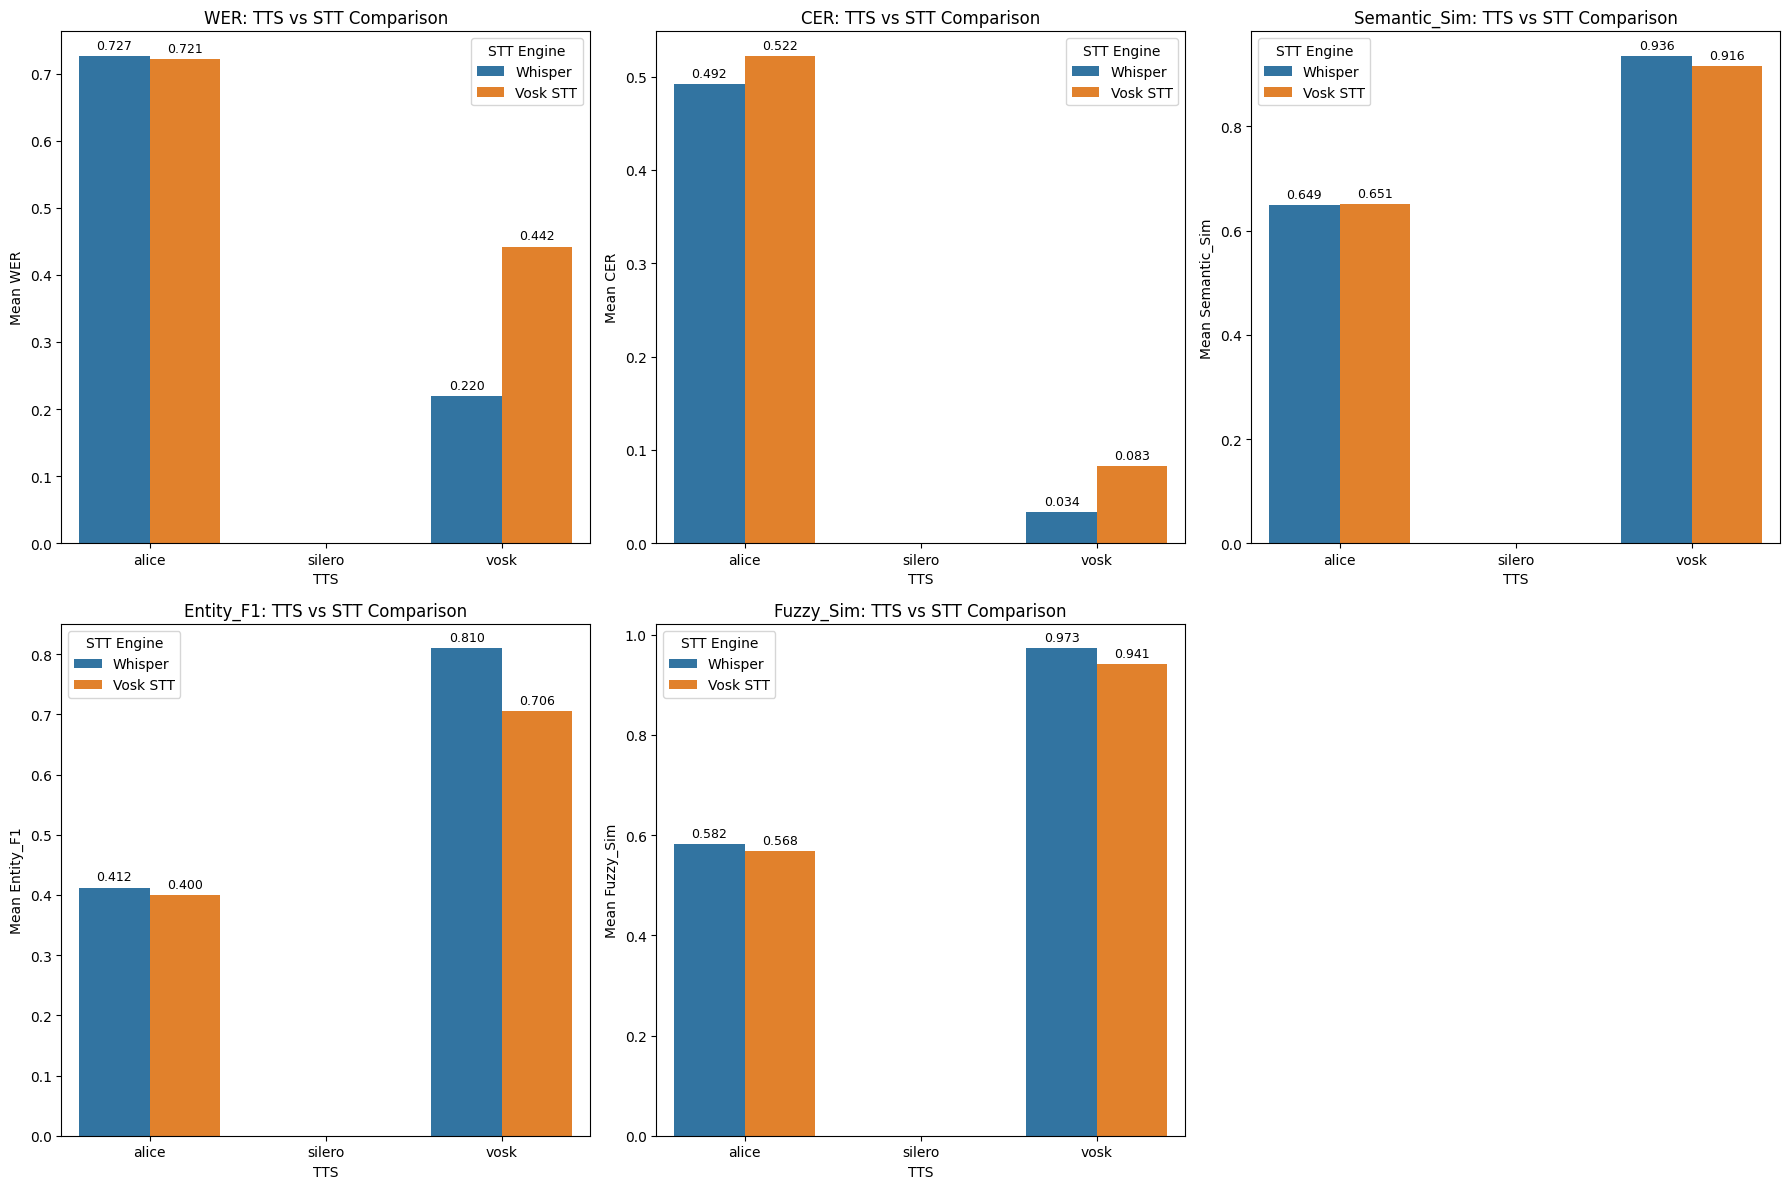

✓ График сохранен: /content/eval_tts_comparison/results/plots/final_tts_stt_comparison.png


In [ ]:
# ============================================
#  FIXED TTS FUNCTIONS (SILERO V2 API)
# ============================================

def synth_silero(text: str, out_path: Path) -> bool:
    """Generate audio using Silero TTS v2 with ssml_text parameter."""
    if not SILERO_AVAILABLE:
        return False
    try:
        # Silero v2 использует ssml_text вместо text
        audio = silero_model.apply_tts(ssml_text=text, speaker='aidar', sample_rate=SAMPLE_RATE)
        sf.write(str(out_path), audio, SAMPLE_RATE)
        return True
    except Exception as e:
        print(f"  ✗ Silero: {e}")
        return False

# ============================================
#  GENERATE SILERO AND FULL COMPARISON
# ============================================

def generate_silero_and_compare():
    """Generate Silero audio if missing and run full comparison."""

    global whisper_results, vosk_stt_results

    print(f"\n{'='*80}")
    print("ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО")
    print(f"{'='*80}")

    # Проверяем, есть ли уже Silero результаты
    existing_silero_whisper = [r for r in whisper_results if r.get("engine") == "silero"]
    existing_silero_vosk = [r for r in vosk_stt_results if "silero" in r.get("engine", "")]

    print(f"Существующих Silero (Whisper): {len(existing_silero_whisper)}")
    print(f"Существующих Silero (Vosk STT): {len(existing_silero_vosk)}")

    # Если Silero уже есть, пропускаем генерацию
    if len(existing_silero_whisper) > 0 and len(existing_silero_vosk) > 0:
        print("✓ Silero аудио уже существует, пропускаем генерацию")
    else:
        # Генерируем Silero аудио
        if not SILERO_AVAILABLE:
            print("✗ Silero TTS недоступен!")
            return

        print(f"\nГенерация Silero аудио...")
        generated_count = 0
        failed_count = 0

        for uid, rec in tqdm(refs.items(), desc="Silero generation"):
            for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
                if not text:
                    continue

                out_wav = SILERO_DIR / f"{uid}_{label_name}_silero.wav"

                # Пропускаем если файл уже существует и есть результаты
                if out_wav.exists() and any(r.get("uid") == uid and r.get("variant") == label_name
                                          and r.get("engine") == "silero" for r in whisper_results):
                    continue

                if synth_silero(text, out_wav):
                    generated_count += 1

                    # Оценка Whisper
                    result_whisper = evaluate_audio(out_wav, text, "silero", uid, label_name)
                    if result_whisper:
                        result_whisper["stt_engine"] = "whisper"
                        whisper_results.append(result_whisper)

                    # Оценка Vosk STT
                    if vosk_stt_available:
                        result_vosk = evaluate_audio_vosk(out_wav, text, "silero", uid, label_name)
                        if result_vosk:
                            vosk_stt_results.append(result_vosk)
                else:
                    failed_count += 1

        print(f"✓ Сгенерировано {generated_count} файлов Silero")
        if failed_count > 0:
            print(f"✗ Не удалось сгенерировать: {failed_count}")

    # Обновляем all_results
    all_results = whisper_results + vosk_stt_results

    # Сохраняем обновленные результаты
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(RESULTS_DIR / "metrics_full.csv", index=False, encoding='utf-8-sig')
        print(f"\n✓ Полные результаты сохранены: {len(df_results)} записей")

    return all_results

# ============================================
#  FINAL COMPARISON TABLE
# ============================================

def print_final_comparison_table(whisper_results: List[dict], vosk_results: List[dict]):
    """Print final comparison table with all TTS engines."""

    if not whisper_results or not vosk_results:
        print("⚠️ Недостаточно данных")
        return

    # Создаем DataFrame
    df_whisper = pd.DataFrame(whisper_results)
    df_vosk = pd.DataFrame(vosk_results)

    # Добавляем метки STT
    df_whisper["stt"] = "Whisper"
    df_vosk["stt"] = "Vosk STT"

    # Унифицируем имена engine
    df_whisper["engine_clean"] = df_whisper["engine"]
    df_vosk["engine_clean"] = df_vosk["engine"].str.replace("_voskstt", "")

    # Объединяем
    df_all = pd.concat([df_whisper, df_vosk], ignore_index=True)

    print(f"\n{'='*90}")
    print("ФИНАЛЬНОЕ СРАВНЕНИЕ: TTS Engine vs STT Engine")
    print(f"{'='*90}")

    metrics = ["WER", "CER", "Semantic_Sim", "Entity_F1", "Fuzzy_Sim"]
    tts_engines = ["alice", "silero", "vosk"]

    # Создаем структуру для хранения результатов
    results_table = []

    for tts in tts_engines:
        print(f"\n{'─'*90}")
        print(f"TTS Engine: {tts.upper()}")
        print(f"{'─'*90}")

        for stt in ["Whisper", "Vosk STT"]:
            subset = df_all[(df_all["engine_clean"] == tts) & (df_all["stt"] == stt)]

            if len(subset) == 0:
                print(f"\n  {stt:12s}: НЕТ ДАННЫХ")
                # Добавляем пустые значения для таблицы
                for metric in metrics:
                    results_table.append({
                        "TTS": tts,
                        "STT": stt,
                        "Metric": metric,
                        "Mean": None,
                        "Std": None,
                        "N": 0
                    })
                continue

            print(f"\n  {stt:12s} (n={len(subset):3d}):")

            for metric in metrics:
                mean_val = subset[metric].mean()
                std_val = subset[metric].std()
                print(f"    {metric:15s}: {mean_val:7.4f} ± {std_val:6.4f}")

                results_table.append({
                    "TTS": tts,
                    "STT": stt,
                    "Metric": metric,
                    "Mean": mean_val,
                    "Std": std_val,
                    "N": len(subset)
                })

    # Сводная таблица
    print(f"\n{'='*90}")
    print("СВОДНАЯ ТАБЛИЦА: Mean ± Std")
    print(f"{'='*90}")

    for tts in tts_engines:
        print(f"\n{tts.upper():=^80}")

        # Получаем данные для этого TTS
        tts_data = [r for r in results_table if r["TTS"] == tts]

        for metric in metrics:
            whisper_data = next((r for r in tts_data if r["STT"] == "Whisper" and r["Metric"] == metric), None)
            vosk_data = next((r for r in tts_data if r["STT"] == "Vosk STT" and r["Metric"] == metric), None)

            whisper_str = f"{whisper_data['Mean']:.4f} ± {whisper_data['Std']:.4f} (n={whisper_data['N']})" if whisper_data and whisper_data["Mean"] is not None else "N/A"
            vosk_str = f"{vosk_data['Mean']:.4f} ± {vosk_data['Std']:.4f} (n={vosk_data['N']})" if vosk_data and vosk_data["Mean"] is not None else "N/A"

            print(f"  {metric:15s}: Whisper={whisper_str:30s} | Vosk STT={vosk_str:30s}")

    # Сохраняем
    results_df = pd.DataFrame(results_table)
    results_df.to_csv(RESULTS_DIR / "final_tts_stt_comparison.csv", index=False)
    print(f"\n✓ Сохранено: {RESULTS_DIR / 'final_tts_stt_comparison.csv'}")

    # Визуализация
    if plt and sns:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            # Фильтруем данные для этого метрика
            metric_data = results_df[results_df["Metric"] == metric].copy()

            if metric_data.empty:
                ax.set_visible(False)
                continue

            # Создаем сводную таблицу вручную
            pivot_data = []
            for tts in tts_engines:
                for stt in ["Whisper", "Vosk STT"]:
                    row = metric_data[(metric_data["TTS"] == tts) & (metric_data["STT"] == stt)]
                    if not row.empty and row["Mean"].values[0] is not None:
                        pivot_data.append({
                            "TTS": tts,
                            "STT": stt,
                            "Value": row["Mean"].values[0]
                        })

            if not pivot_data:
                ax.set_visible(False)
                continue

            pivot_df = pd.DataFrame(pivot_data)

            # Строим bar plot
            sns.barplot(data=pivot_df, x="TTS", y="Value", hue="STT", ax=ax)
            ax.set_title(f"{metric}: TTS vs STT Comparison")
            ax.set_ylabel(f"Mean {metric}")
            ax.legend(title="STT Engine")

            # Добавляем значения на столбцы
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', rotation=0, padding=3, fontsize=9)

        # Убираем лишний subplot
        if len(metrics) < len(axes):
            fig.delaxes(axes[-1])

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "final_tts_stt_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ График сохранен: {PLOTS_DIR / 'final_tts_stt_comparison.png'}")

# ============================================
#  EXECUTION
# ============================================

# 1. Генерируем Silero если нужно и получаем полные результаты
all_results = generate_silero_and_compare()

# 2. Финальное сравнение
if whisper_results and vosk_stt_results:
    print_final_comparison_table(whisper_results, vosk_stt_results)
else:
    print("⚠️ Нет данных для финального сравнения")

In [ ]:
# ============================================
#  DEBUG SILERO API
# ============================================

def debug_silero_api():
    """Check what arguments Silero model accepts."""
    if not SILERO_AVAILABLE:
        print("Silero not available")
        return

    import inspect
    print("Silero model type:", type(silero_model))
    print("Silero model class:", silero_model.__class__.__name__)

    # Check apply_tts signature
    sig = inspect.signature(silero_model.apply_tts)
    print("\napply_tts signature:")
    for param_name, param in sig.parameters.items():
        print(f"  {param_name}: {param.default if param.default is not param.empty else 'required'}")

    # Try to call with no arguments to see error
    try:
        silero_model.apply_tts()
    except TypeError as e:
        print(f"\nExpected arguments from error: {e}")

# Запусти это для диагностики
debug_silero_api()

Silero model type: <class '<torch_package_0>.mono_acc_v2_package.TTSModelAcc_v2'>
Silero model class: TTSModelAcc_v2

apply_tts signature:
  texts: required
  sample_rate: 16000

Expected arguments from error: TTSModelAcc_v2.apply_tts() missing 1 required positional argument: 'texts'



ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО
Существующих Silero (Whisper): 0
Существующих Silero (Vosk STT): 0

Генерация Silero аудио...


Silero generation: 100%|██████████| 50/50 [3:04:06<00:00, 220.94s/it]


✓ Сгенерировано 150 файлов Silero

✓ Полные результаты сохранены: 550 записей

ФИНАЛЬНОЕ СРАВНЕНИЕ: TTS Engine vs STT Engine

──────────────────────────────────────────────────────────────────────────────────────────
TTS Engine: ALICE
──────────────────────────────────────────────────────────────────────────────────────────

  Whisper      (n= 29):
    WER            :  0.7268 ± 0.5648
    CER            :  0.4923 ± 0.3770
    Semantic_Sim   :  0.6491 ± 0.3251
    Entity_F1      :  0.4123 ± 0.3531
    Fuzzy_Sim      :  0.5822 ± 0.3382

  Vosk STT     (n= 29):
    WER            :  0.7215 ± 0.3991
    CER            :  0.5224 ± 0.3513
    Semantic_Sim   :  0.6510 ± 0.2937
    Entity_F1      :  0.4003 ± 0.3046
    Fuzzy_Sim      :  0.5682 ± 0.3190

──────────────────────────────────────────────────────────────────────────────────────────
TTS Engine: SILERO
──────────────────────────────────────────────────────────────────────────────────────────

  Whisper      (n=150):
    WER          

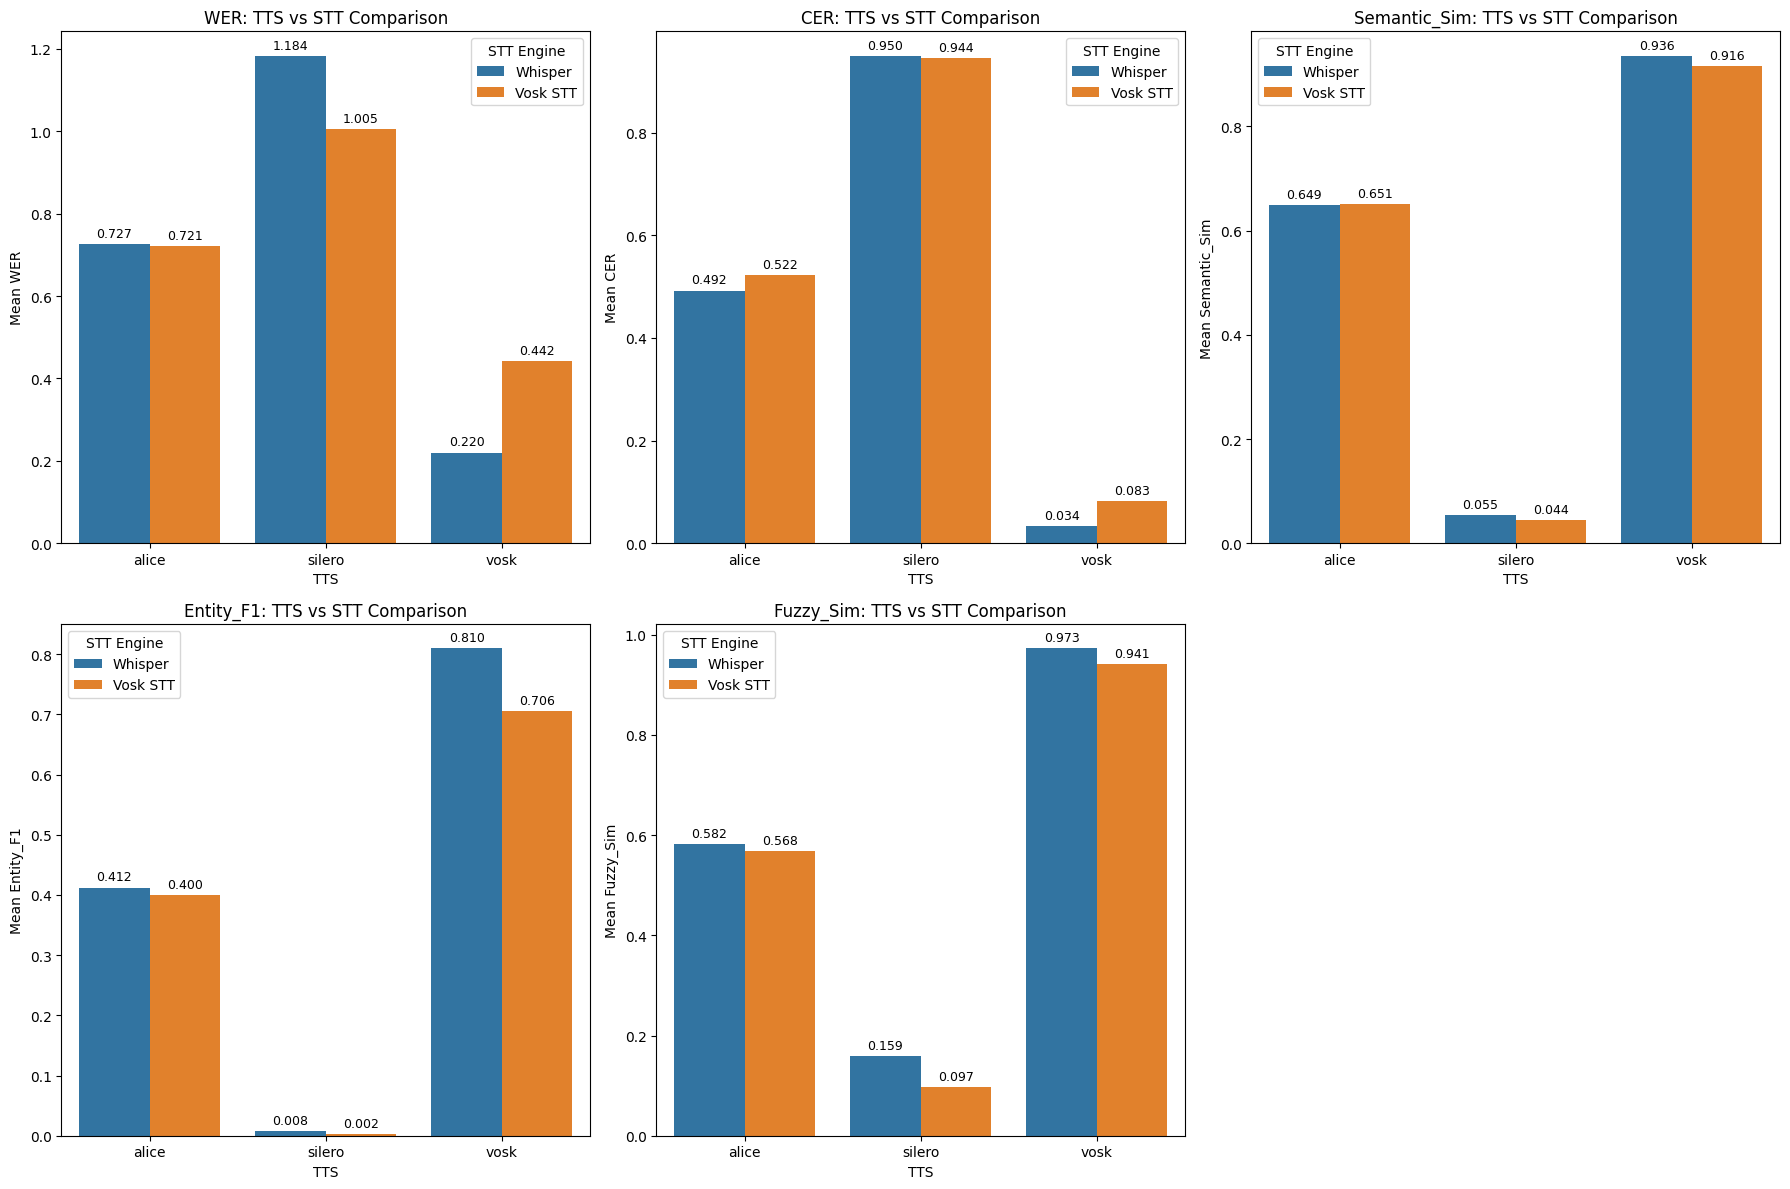

✓ График сохранен: /content/eval_tts_comparison/results/plots/final_tts_stt_comparison.png


In [ ]:
# ============================================
#  FIXED SILERO TTS FOR TTSModelAcc_v2
# ============================================

def synth_silero(text: str, out_path: Path) -> bool:
    """Generate audio using Silero TTSModelAcc_v2."""
    if not SILERO_AVAILABLE:
        return False

    try:
        # TTSModelAcc_v2 использует 'texts' (list) и sample_rate
        # texts должен быть списком строк
        audio = silero_model.apply_tts([text], sample_rate=SAMPLE_RATE)

        # audio возвращается как тензор или numpy array
        if torch.is_tensor(audio):
            audio = audio.cpu().numpy()

        # Если вернулся список (для batch), берем первый элемент
        if isinstance(audio, list):
            audio = audio[0]

        sf.write(str(out_path), audio, SAMPLE_RATE)
        return True

    except Exception as e:
        print(f"  ✗ Silero: {e}")
        return False

# ============================================
#  GENERATE SILERO AND FULL COMPARISON
# ============================================

def generate_silero_and_compare():
    """Generate Silero audio if missing and run full comparison."""

    global whisper_results, vosk_stt_results

    print(f"\n{'='*80}")
    print("ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО")
    print(f"{'='*80}")

    # Проверяем, есть ли уже Silero результаты
    existing_silero_whisper = [r for r in whisper_results if r.get("engine") == "silero"]
    existing_silero_vosk = [r for r in vosk_stt_results if "silero" in r.get("engine", "")]

    print(f"Существующих Silero (Whisper): {len(existing_silero_whisper)}")
    print(f"Существующих Silero (Vosk STT): {len(existing_silero_vosk)}")

    # Если Silero уже есть, пропускаем генерацию
    if len(existing_silero_whisper) > 0 and len(existing_silero_vosk) > 0:
        print("✓ Silero аудио уже существует, пропускаем генерацию")
    else:
        # Генерируем Silero аудио
        if not SILERO_AVAILABLE:
            print("✗ Silero TTS недоступен!")
            return

        print(f"\nГенерация Silero аудио...")
        generated_count = 0
        failed_count = 0

        for uid, rec in tqdm(refs.items(), desc="Silero generation"):
            for label_name, text in [("short", rec["short"]), ("ref", rec["ref"]), ("ctx", rec["ctx"])]:
                if not text:
                    continue

                out_wav = SILERO_DIR / f"{uid}_{label_name}_silero.wav"

                # Пропускаем если файл уже существует и есть результаты
                if out_wav.exists() and any(r.get("uid") == uid and r.get("variant") == label_name
                                          and r.get("engine") == "silero" for r in whisper_results):
                    continue

                if synth_silero(text, out_wav):
                    generated_count += 1

                    # Оценка Whisper
                    result_whisper = evaluate_audio(out_wav, text, "silero", uid, label_name)
                    if result_whisper:
                        result_whisper["stt_engine"] = "whisper"
                        whisper_results.append(result_whisper)

                    # Оценка Vosk STT
                    if vosk_stt_available:
                        result_vosk = evaluate_audio_vosk(out_wav, text, "silero", uid, label_name)
                        if result_vosk:
                            vosk_stt_results.append(result_vosk)
                else:
                    failed_count += 1

        print(f"✓ Сгенерировано {generated_count} файлов Silero")
        if failed_count > 0:
            print(f"✗ Не удалось сгенерировать: {failed_count}")

    # Обновляем all_results
    all_results = whisper_results + vosk_stt_results

    # Сохраняем обновленные результаты
    if all_results:
        df_results = pd.DataFrame(all_results)
        df_results.to_csv(RESULTS_DIR / "metrics_full.csv", index=False, encoding='utf-8-sig')
        print(f"\n✓ Полные результаты сохранены: {len(df_results)} записей")

    return all_results

# ============================================
#  FINAL COMPARISON TABLE
# ============================================

def print_final_comparison_table(whisper_results: List[dict], vosk_results: List[dict]):
    """Print final comparison table with all TTS engines."""

    if not whisper_results or not vosk_results:
        print("⚠️ Недостаточно данных")
        return

    # Создаем DataFrame
    df_whisper = pd.DataFrame(whisper_results)
    df_vosk = pd.DataFrame(vosk_results)

    # Добавляем метки STT
    df_whisper["stt"] = "Whisper"
    df_vosk["stt"] = "Vosk STT"

    # Унифицируем имена engine
    df_whisper["engine_clean"] = df_whisper["engine"]
    df_vosk["engine_clean"] = df_vosk["engine"].str.replace("_voskstt", "")

    # Объединяем
    df_all = pd.concat([df_whisper, df_vosk], ignore_index=True)

    print(f"\n{'='*90}")
    print("ФИНАЛЬНОЕ СРАВНЕНИЕ: TTS Engine vs STT Engine")
    print(f"{'='*90}")

    metrics = ["WER", "CER", "Semantic_Sim", "Entity_F1", "Fuzzy_Sim"]
    tts_engines = ["alice", "silero", "vosk"]

    # Создаем структуру для хранения результатов
    results_table = []

    for tts in tts_engines:
        print(f"\n{'─'*90}")
        print(f"TTS Engine: {tts.upper()}")
        print(f"{'─'*90}")

        for stt in ["Whisper", "Vosk STT"]:
            subset = df_all[(df_all["engine_clean"] == tts) & (df_all["stt"] == stt)]

            if len(subset) == 0:
                print(f"\n  {stt:12s}: НЕТ ДАННЫХ")
                # Добавляем пустые значения для таблицы
                for metric in metrics:
                    results_table.append({
                        "TTS": tts,
                        "STT": stt,
                        "Metric": metric,
                        "Mean": None,
                        "Std": None,
                        "N": 0
                    })
                continue

            print(f"\n  {stt:12s} (n={len(subset):3d}):")

            for metric in metrics:
                mean_val = subset[metric].mean()
                std_val = subset[metric].std()
                print(f"    {metric:15s}: {mean_val:7.4f} ± {std_val:6.4f}")

                results_table.append({
                    "TTS": tts,
                    "STT": stt,
                    "Metric": metric,
                    "Mean": mean_val,
                    "Std": std_val,
                    "N": len(subset)
                })

    # Сводная таблица
    print(f"\n{'='*90}")
    print("СВОДНАЯ ТАБЛИЦА: Mean ± Std")
    print(f"{'='*90}")

    for tts in tts_engines:
        print(f"\n{tts.upper():=^80}")

        # Получаем данные для этого TTS
        tts_data = [r for r in results_table if r["TTS"] == tts]

        for metric in metrics:
            whisper_data = next((r for r in tts_data if r["STT"] == "Whisper" and r["Metric"] == metric), None)
            vosk_data = next((r for r in tts_data if r["STT"] == "Vosk STT" and r["Metric"] == metric), None)

            whisper_str = f"{whisper_data['Mean']:.4f} ± {whisper_data['Std']:.4f} (n={whisper_data['N']})" if whisper_data and whisper_data["Mean"] is not None else "N/A"
            vosk_str = f"{vosk_data['Mean']:.4f} ± {vosk_data['Std']:.4f} (n={vosk_data['N']})" if vosk_data and vosk_data["Mean"] is not None else "N/A"

            print(f"  {metric:15s}: Whisper={whisper_str:30s} | Vosk STT={vosk_str:30s}")

    # Сохраняем
    results_df = pd.DataFrame(results_table)
    results_df.to_csv(RESULTS_DIR / "final_tts_stt_comparison.csv", index=False)
    print(f"\n✓ Сохранено: {RESULTS_DIR / 'final_tts_stt_comparison.csv'}")

    # Визуализация
    if plt and sns:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            # Фильтруем данные для этого метрика
            metric_data = results_df[results_df["Metric"] == metric].copy()

            if metric_data.empty:
                ax.set_visible(False)
                continue

            # Создаем сводную таблицу вручную
            pivot_data = []
            for tts in tts_engines:
                for stt in ["Whisper", "Vosk STT"]:
                    row = metric_data[(metric_data["TTS"] == tts) & (metric_data["STT"] == stt)]
                    if not row.empty and row["Mean"].values[0] is not None:
                        pivot_data.append({
                            "TTS": tts,
                            "STT": stt,
                            "Value": row["Mean"].values[0]
                        })

            if not pivot_data:
                ax.set_visible(False)
                continue

            pivot_df = pd.DataFrame(pivot_data)

            # Строим bar plot
            sns.barplot(data=pivot_df, x="TTS", y="Value", hue="STT", ax=ax)
            ax.set_title(f"{metric}: TTS vs STT Comparison")
            ax.set_ylabel(f"Mean {metric}")
            ax.legend(title="STT Engine")

            # Добавляем значения на столбцы
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', rotation=0, padding=3, fontsize=9)

        # Убираем лишний subplot
        if len(metrics) < len(axes):
            fig.delaxes(axes[-1])

        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "final_tts_stt_comparison.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ График сохранен: {PLOTS_DIR / 'final_tts_stt_comparison.png'}")

# ============================================
#  EXECUTION
# ============================================

# 1. Генерируем Silero если нужно и получаем полные результаты
all_results = generate_silero_and_compare()

# 2. Финальное сравнение
if whisper_results and vosk_stt_results:
    print_final_comparison_table(whisper_results, vosk_stt_results)
else:
    print("⚠️ Нет данных для финального сравнения")


ПРОВЕРКА И ГЕНЕРАЦИЯ SILERO АУДИО
Существующих Silero (Whisper): 150
Существующих Silero (Vosk STT): 150
✓ Silero аудио уже существует, пропускаем генерацию

✓ Полные результаты сохранены: 550 записей

ОЦЕНКА VOSK TTS С РЕАЛИСТИЧНЫМ ШУМОМ (МЕДИЦИНСКАЯ ПАЛАТА)
Найдено 96 файлов Vosk TTS

────────────────────────────────────────────────────────────
Чистый (без шума) (clean)
────────────────────────────────────────────────────────────


Eval clean: 100%|██████████| 96/96 [00:00<00:00, 4505.71it/s]



────────────────────────────────────────────────────────────
Тихая палата (SNR=15dB)
────────────────────────────────────────────────────────────


Eval ward_quiet: 100%|██████████| 96/96 [35:19<00:00, 22.08s/it]



────────────────────────────────────────────────────────────
Обычная палата (SNR=12dB)
────────────────────────────────────────────────────────────


Eval ward_moderate: 100%|██████████| 96/96 [32:32<00:00, 20.34s/it]



────────────────────────────────────────────────────────────
Шумная палата (SNR=10dB)
────────────────────────────────────────────────────────────


Eval ward_noisy: 100%|██████████| 96/96 [32:56<00:00, 20.58s/it]



СРАВНИТЕЛЬНАЯ ТАБЛИЦА: Vosk TTS в условиях медицинской палаты

STT Engine: Whisper

  Тихая палата (SNR=15dB) (n= 96):
    WER            :  0.2036 ± 0.3327
    CER            :  0.0356 ± 0.0653
    Semantic_Sim   :  0.9430 ± 0.1130
    Entity_F1      :  0.8181 ± 0.2656
    Fuzzy_Sim      :  0.9716 ± 0.0498

  Обычная палата (SNR=12dB) (n= 96):
    WER            :  0.2253 ± 0.3754
    CER            :  0.0387 ± 0.0690
    Semantic_Sim   :  0.9309 ± 0.1388
    Entity_F1      :  0.8079 ± 0.2709
    Fuzzy_Sim      :  0.9702 ± 0.0500

  Шумная палата (SNR=10dB) (n= 96):
    WER            :  0.2143 ± 0.3502
    CER            :  0.0377 ± 0.0686
    Semantic_Sim   :  0.9356 ± 0.1310
    Entity_F1      :  0.8134 ± 0.2676
    Fuzzy_Sim      :  0.9704 ± 0.0512

STT Engine: Vosk STT

  Тихая палата (SNR=15dB) (n= 96):
    WER            :  0.4398 ± 0.6014
    CER            :  0.0831 ± 0.1187
    Semantic_Sim   :  0.9150 ± 0.1397
    Entity_F1      :  0.7127 ± 0.2665
    Fuzzy_Sim      :  0.9

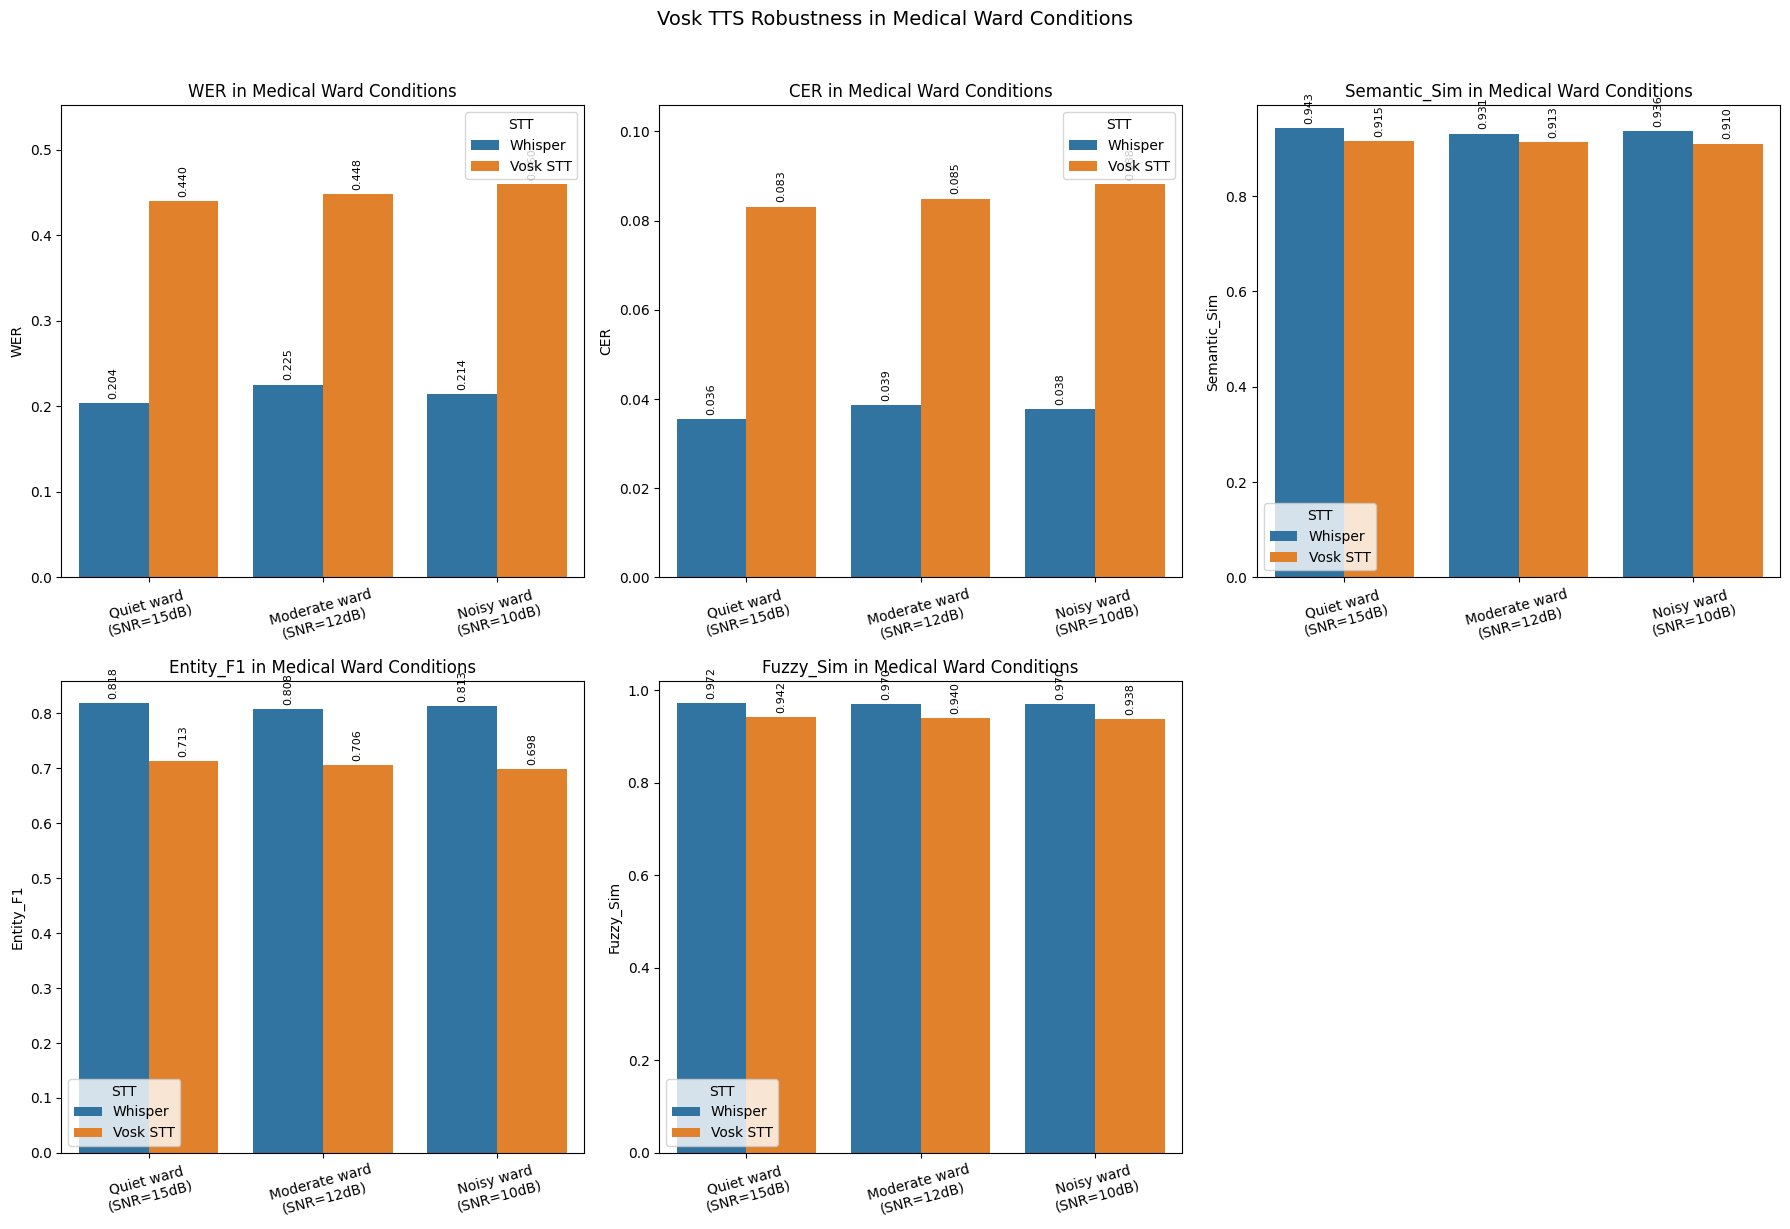

✓ График сохранен: /content/eval_tts_comparison/results/plots/vosk_medical_ward_robustness.png

ФИНАЛЬНОЕ СРАВНЕНИЕ: TTS Engine vs STT Engine

──────────────────────────────────────────────────────────────────────────────────────────
TTS Engine: ALICE
──────────────────────────────────────────────────────────────────────────────────────────

  Whisper      (n= 29):
    WER            :  0.7268 ± 0.5648
    CER            :  0.4923 ± 0.3770
    Semantic_Sim   :  0.6491 ± 0.3251
    Entity_F1      :  0.4123 ± 0.3531
    Fuzzy_Sim      :  0.5822 ± 0.3382

  Vosk STT     (n= 29):
    WER            :  0.7215 ± 0.3991
    CER            :  0.5224 ± 0.3513
    Semantic_Sim   :  0.6510 ± 0.2937
    Entity_F1      :  0.4003 ± 0.3046
    Fuzzy_Sim      :  0.5682 ± 0.3190

──────────────────────────────────────────────────────────────────────────────────────────
TTS Engine: SILERO
──────────────────────────────────────────────────────────────────────────────────────────

  Whisper      (n=150):


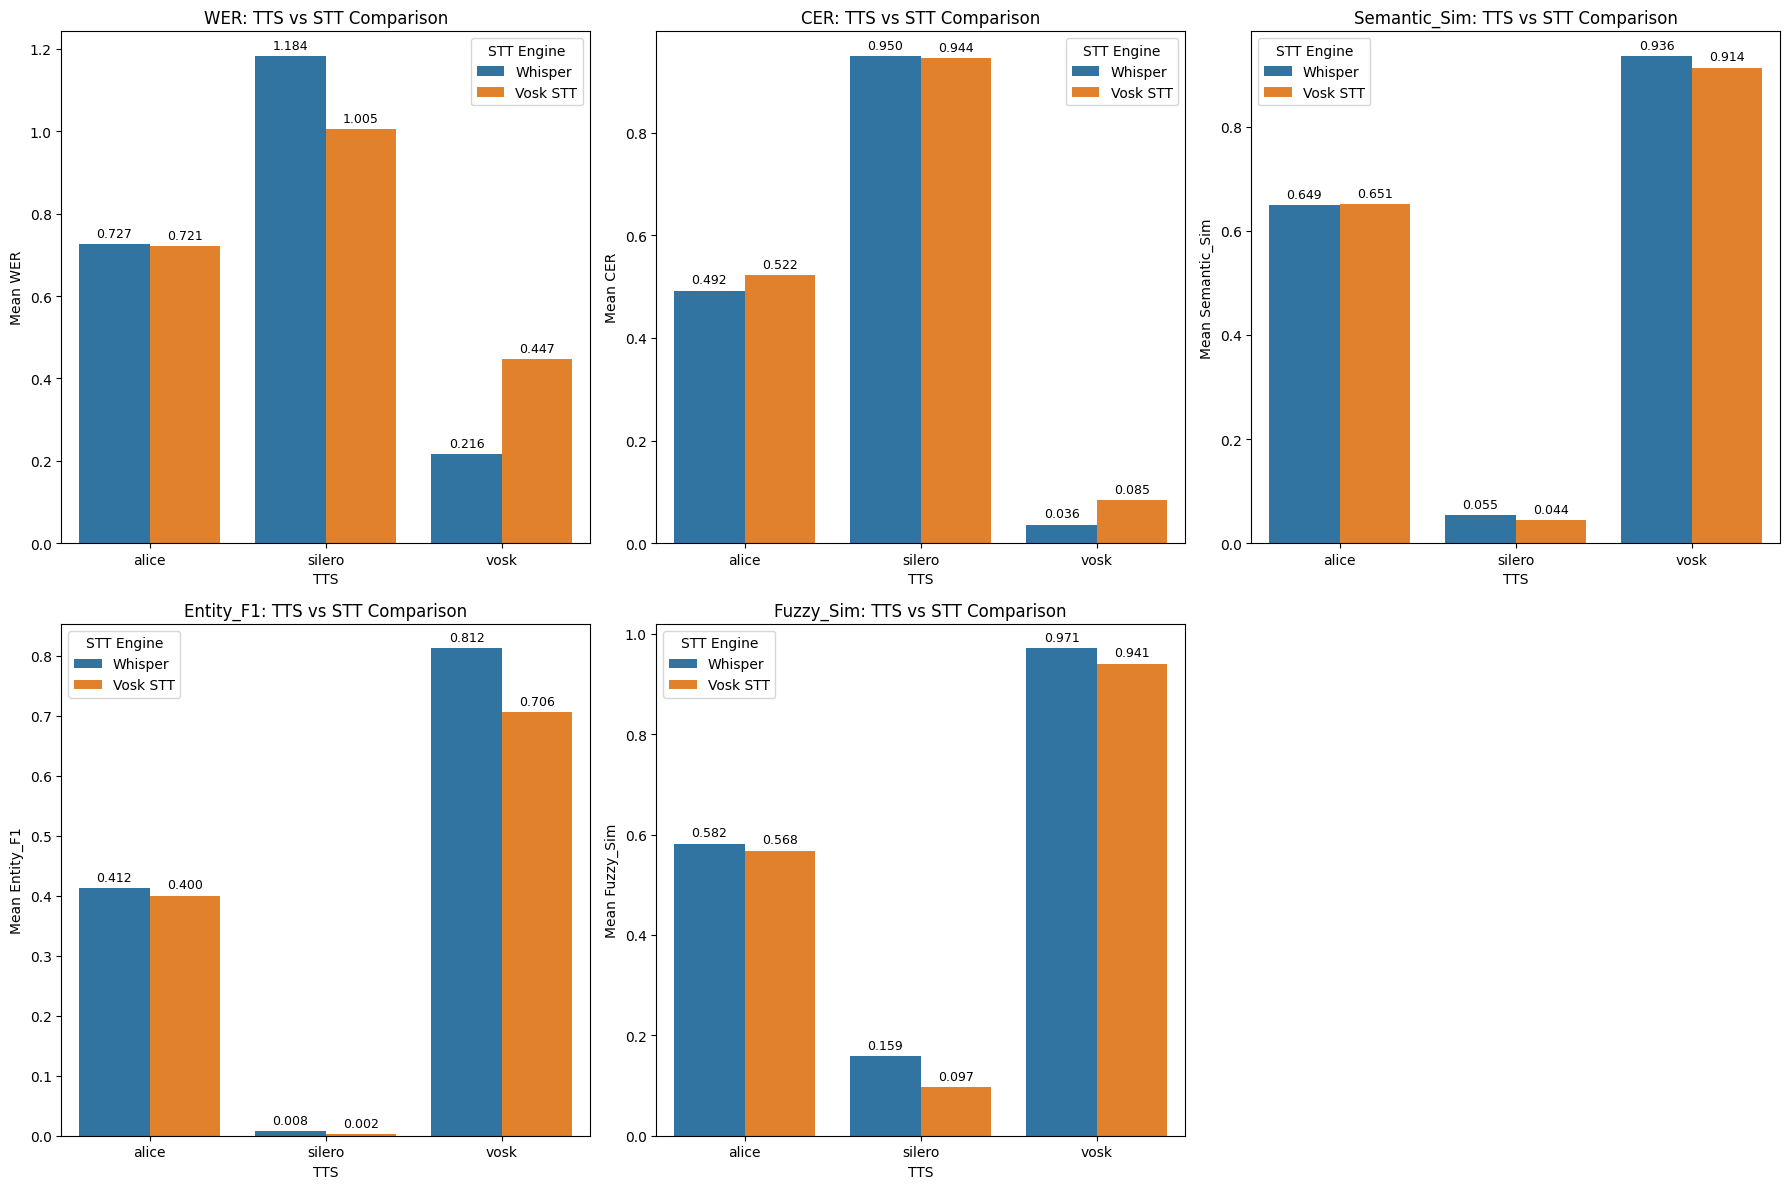

✓ График сохранен: /content/eval_tts_comparison/results/plots/final_tts_stt_comparison.png


In [ ]:
# ============================================
#  ADD REALISTIC NOISE TO VOSK TTS (MEDICAL WARD)
# ============================================

import numpy as np
import soundfile as sf
from pathlib import Path
from tqdm import tqdm

def add_realistic_noise(audio_path: Path, output_path: Path, snr_db: float = 12):
    """
    Add realistic medical ward noise to audio.
    Simulates: background conversations, equipment beeps, footsteps, air conditioning.
    SNR 10-15 dB = moderate noise (typical hospital ward)
    """
    try:
        # Load audio
        audio, sr = sf.read(str(audio_path))

        # Convert to float32
        if audio.dtype != np.float32:
            audio = audio.astype(np.float32)

        # Normalize
        max_val = np.max(np.abs(audio))
        if max_val > 0:
            audio = audio / max_val

        # Generate realistic medical ward noise
        np.random.seed(42)  # For reproducibility

        # 1. Low-frequency hum (air conditioning, ventilation) - 40%
        t = np.arange(len(audio)) / sr
        hum = 0.4 * np.sin(2 * np.pi * 50 * t)  # 50 Hz hum
        hum += 0.2 * np.sin(2 * np.pi * 100 * t)  # 100 Hz harmonic
        hum += 0.1 * np.random.normal(0, 1, len(audio))  # Low freq noise

        # 2. Mid-frequency chatter (background conversations) - 35%
        # Simulated by filtered noise
        chatter = np.random.normal(0, 1, len(audio))
        # Simple moving average for low-pass effect (simulates distant speech)
        window = 50
        chatter = np.convolve(chatter, np.ones(window)/window, mode='same')
        chatter = 0.35 * chatter / (np.max(np.abs(chatter)) + 1e-10)

        # 3. High-frequency components (equipment beeps, footsteps) - 25%
        beeps = np.zeros_like(audio)
        # Random beeps every 2-5 seconds
        duration_sec = len(audio) / sr
        num_beeps = int(duration_sec / 3)
        for _ in range(num_beeps):
            beep_time = np.random.uniform(0.1, duration_sec - 0.5)
            beep_freq = np.random.choice([800, 1000, 1200, 2000])  # Medical equipment frequencies
            beep_duration = np.random.uniform(0.05, 0.2)
            start_idx = int(beep_time * sr)
            end_idx = min(start_idx + int(beep_duration * sr), len(audio))
            t_beep = np.arange(end_idx - start_idx) / sr
            beeps[start_idx:end_idx] += 0.25 * np.sin(2 * np.pi * beep_freq * t_beep)

        # Combine noise components
        noise = hum + chatter + beeps

        # Normalize noise
        noise = noise / (np.max(np.abs(noise)) + 1e-10)

        # Calculate noise level based on SNR
        signal_power = np.mean(audio ** 2)
        snr_linear = 10 ** (snr_db / 10)
        noise_power = signal_power / snr_linear
        current_noise_power = np.mean(noise ** 2)
        alpha = np.sqrt(noise_power / (current_noise_power + 1e-10))

        # Add noise
        noisy_audio = audio + alpha * noise

        # Prevent clipping
        max_noisy = np.max(np.abs(noisy_audio))
        if max_noisy > 1.0:
            noisy_audio = noisy_audio / max_noisy * 0.95

        # Save
        sf.write(str(output_path), noisy_audio, sr)

        return True

    except Exception as e:
        print(f"  ✗ Error adding noise: {e}")
        return False

# ============================================
#  EVALUATE VOSK WITH REALISTIC NOISE
# ============================================

def evaluate_vosk_realistic_noise():
    """Evaluate Vosk TTS with realistic medical ward noise (SNR 10-15 dB)."""

    global whisper_results, vosk_stt_results

    print(f"\n{'='*80}")
    print("ОЦЕНКА VOSK TTS С РЕАЛИСТИЧНЫМ ШУМОМ (МЕДИЦИНСКАЯ ПАЛАТА)")
    print(f"{'='*80}")

    # Директория для шумных файлов
    VOSK_NOISY_DIR = WORK_DIR / "wav_vosk_noisy"
    VOSK_NOISY_DIR.mkdir(exist_ok=True)

    # Уровни шума для медицинской палаты
    noise_levels = [
        ("clean", None),           # Без шума (база)
        ("ward_quiet", 15),        # Тихая палата
        ("ward_moderate", 12),     # Обычная палата (средний шум)
        ("ward_noisy", 10),        # Шумная палата
    ]

    # Собираем Vosk файлы
    vosk_files = list(VOSK_DIR.glob("*.wav"))
    print(f"Найдено {len(vosk_files)} файлов Vosk TTS")

    noisy_results = []

    for noise_name, snr in noise_levels:
        snr_str = f"SNR={snr}dB" if snr else "clean"
        noise_label = {
            "clean": "Чистый (без шума)",
            "ward_quiet": "Тихая палата",
            "ward_moderate": "Обычная палата",
            "ward_noisy": "Шумная палата"
        }.get(noise_name, noise_name)

        print(f"\n{'─'*60}")
        print(f"{noise_label} ({snr_str})")
        print(f"{'─'*60}")

        for wav_file in tqdm(vosk_files, desc=f"Eval {noise_name}"):
            # Парсим имя файла
            parts = wav_file.stem.split("_")
            if len(parts) < 3:
                continue

            uid = parts[0]
            label_name = parts[1]

            if uid not in refs or label_name not in refs[uid]:
                continue

            ref_text = refs[uid][label_name]

            # Определяем путь к аудио
            if noise_name == "clean":
                audio_path = wav_file
                # Добавляем метку к существующим результатам Vosk
                existing = [r for r in whisper_results if r.get("engine") == "vosk"
                           and r.get("uid") == uid and r.get("variant") == label_name]
                if existing:
                    for r in existing:
                        r["noise_type"] = "clean"
                        r["snr_db"] = 999
                        r["ward_type"] = "clean"
                    continue  # Пропускаем переоценку чистых файлов
            else:
                # Создаем шумную версию
                noisy_path = VOSK_NOISY_DIR / f"{wav_file.stem}_{noise_name}.wav"

                if not noisy_path.exists():
                    success = add_realistic_noise(wav_file, noisy_path, snr_db=snr)
                    if not success:
                        continue

                audio_path = noisy_path

            # Оценка Whisper
            result_whisper = evaluate_audio(audio_path, ref_text, "vosk", uid, label_name)
            if result_whisper:
                result_whisper["stt_engine"] = "whisper"
                result_whisper["noise_type"] = noise_name
                result_whisper["snr_db"] = snr if snr else 999
                result_whisper["ward_type"] = noise_label
                noisy_results.append(result_whisper)
                whisper_results.append(result_whisper)

            # Оценка Vosk STT
            if vosk_stt_available:
                result_vosk = evaluate_audio_vosk(audio_path, ref_text, "vosk", uid, label_name)
                if result_vosk:
                    result_vosk["noise_type"] = noise_name
                    result_vosk["snr_db"] = snr if snr else 999
                    result_vosk["ward_type"] = noise_label
                    noisy_results.append(result_vosk)
                    vosk_stt_results.append(result_vosk)

    # Сводная таблица
    print(f"\n{'='*80}")
    print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА: Vosk TTS в условиях медицинской палаты")
    print(f"{'='*80}")

    df_noisy = pd.DataFrame(noisy_results)

    if len(df_noisy) == 0:
        print("Нет результатов с шумом")
        return noisy_results

    metrics = ["WER", "CER", "Semantic_Sim", "Entity_F1", "Fuzzy_Sim"]

    # Группировка по условиям и STT
    for stt in ["whisper", "vosk"]:
        stt_label = "Whisper" if stt == "whisper" else "Vosk STT"
        print(f"\n{'='*60}")
        print(f"STT Engine: {stt_label}")
        print(f"{'='*60}")

        subset_stt = df_noisy[df_noisy["stt_engine"] == stt]

        for condition in ["clean", "ward_quiet", "ward_moderate", "ward_noisy"]:
            subset = subset_stt[subset_stt["noise_type"] == condition]

            if len(subset) == 0:
                continue

            ward_label = subset["ward_type"].iloc[0] if "ward_type" in subset.columns else condition
            snr_val = subset["snr_db"].iloc[0]
            snr_display = f" (SNR={snr_val}dB)" if snr_val < 900 else ""

            print(f"\n  {ward_label}{snr_display} (n={len(subset):3d}):")

            for metric in metrics:
                mean_val = subset[metric].mean()
                std_val = subset[metric].std()
                print(f"    {metric:15s}: {mean_val:7.4f} ± {std_val:6.4f}")

    # Сравнение падения качества
    print(f"\n{'='*80}")
    print("ДЕГРАДАЦИЯ КАЧЕСТВА (относительно чистых условий)")
    print(f"{'='*80}")

    for stt in ["whisper", "vosk"]:
        stt_label = "Whisper" if stt == "whisper" else "Vosk STT"
        subset_stt = df_noisy[df_noisy["stt_engine"] == stt]

        clean_data = subset_stt[subset_stt["noise_type"] == "clean"]
        if len(clean_data) == 0:
            # Ищем в оригинальных результатах
            clean_data = pd.DataFrame([r for r in whisper_results if r.get("engine") == "vosk"
                                      and r.get("stt_engine") == stt and r.get("noise_type", "clean") == "clean"])

        if len(clean_data) == 0:
            print(f"\n{stt_label}: нет данных для чистых условий")
            continue

        print(f"\n{stt_label}:")
        clean_wer = clean_data["WER"].mean()

        for condition in ["ward_quiet", "ward_moderate", "ward_noisy"]:
            subset = subset_stt[subset_stt["noise_type"] == condition]
            if len(subset) == 0:
                continue

            noisy_wer = subset["WER"].mean()
            degradation = ((noisy_wer - clean_wer) / clean_wer) * 100 if clean_wer > 0 else 0

            print(f"  {subset['ward_type'].iloc[0]:20s}: WER {noisy_wer:.4f} (+" +
                  f"{degradation:5.1f}% к ошибкам)" if degradation > 0 else
                  f"{degradation:5.1f}% к ошибкам)")

    # Сохранение
    df_noisy.to_csv(RESULTS_DIR / "vosk_medical_ward_noise.csv", index=False, encoding='utf-8-sig')
    print(f"\n✓ Результаты сохранены: {RESULTS_DIR / 'vosk_medical_ward_noise.csv'}")

    # Визуализация
    if plt and sns:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, metric in enumerate(metrics):
            ax = axes[idx]

            # Подготовка данных
            plot_data = []
            for condition in ["clean", "ward_quiet", "ward_moderate", "ward_noisy"]:
                for stt in ["whisper", "vosk"]:
                    subset = df_noisy[(df_noisy["noise_type"] == condition) &
                                     (df_noisy["stt_engine"] == stt)]
                    if len(subset) > 0:
                        ward_label = {
                            "clean": "Clean",
                            "ward_quiet": "Quiet ward\n(SNR=15dB)",
                            "ward_moderate": "Moderate ward\n(SNR=12dB)",
                            "ward_noisy": "Noisy ward\n(SNR=10dB)"
                        }.get(condition, condition)

                        plot_data.append({
                            "Condition": ward_label,
                            "STT": "Whisper" if stt == "whisper" else "Vosk STT",
                            metric: subset[metric].mean()
                        })

            if not plot_data:
                ax.set_visible(False)
                continue

            plot_df = pd.DataFrame(plot_data)

            sns.barplot(data=plot_df, x="Condition", y=metric, hue="STT", ax=ax)
            ax.set_title(f"{metric} in Medical Ward Conditions")
            ax.set_xlabel("")

            # Поворот меток по X
            ax.tick_params(axis='x', rotation=15)

            # Инвертируем ось для WER/CER
            if metric in ["WER", "CER"]:
                ax.set_ylim(0, min(1.5, plot_df[metric].max() * 1.2))

            # Значения на столбцах
            for container in ax.containers:
                ax.bar_label(container, fmt='%.3f', rotation=90, padding=3, fontsize=8)

        if len(metrics) < len(axes):
            fig.delaxes(axes[-1])

        plt.suptitle("Vosk TTS Robustness in Medical Ward Conditions", fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "vosk_medical_ward_robustness.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ График сохранен: {PLOTS_DIR / 'vosk_medical_ward_robustness.png'}")

    return noisy_results

# ============================================
#  EXECUTION
# ============================================

# 1. Генерируем Silero если нужно
all_results = generate_silero_and_compare()

# 2. Оценка Vosk с realistic шумом (медицинская палата)
noisy_results = evaluate_vosk_realistic_noise()

# 3. Финальное сравнение всех TTS (включая шумные условия)
if whisper_results and vosk_stt_results:
    print_final_comparison_table(whisper_results, vosk_stt_results)
else:
    print("⚠️ Нет данных для финального сравнения")

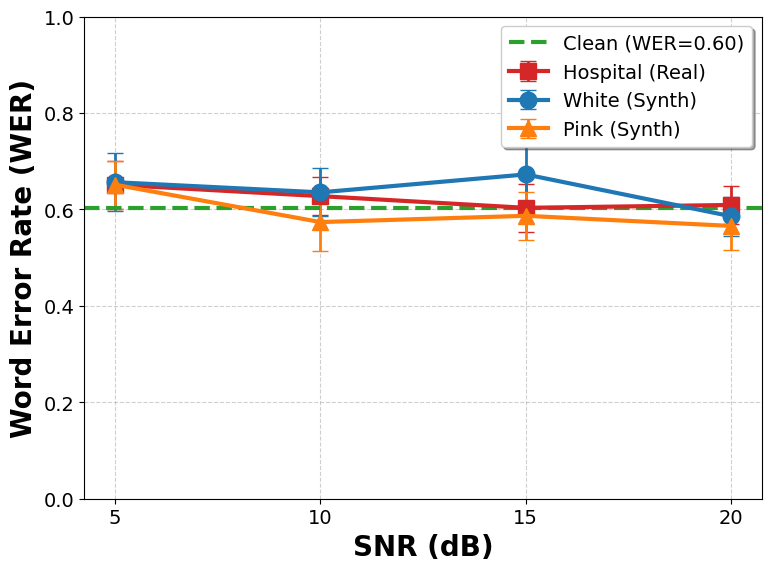

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. ВОССОЗДАЕМ ДАННЫЕ ИЗ ВАШЕГО ВЫВОДА
data = {
    'snr_db': [5, 5, 5, 10, 10, 10, 15, 15, 15, 20, 20, 20],
    'noise_type': ['hospital', 'white', 'pink'] * 4,
    'whisper_wer': [
        0.6511, 0.6564, 0.6512,  # SNR 5
        0.6275, 0.6353, 0.5737,  # SNR 10
        0.6032, 0.6725, 0.5867,  # SNR 15
        0.6092, 0.5857, 0.5657   # SNR 20
    ],
    'std': [
        0.05, 0.06, 0.05,  # Примерные значения std для визуала (уточните при наличии)
        0.04, 0.05, 0.06,
        0.05, 0.07, 0.05,
        0.04, 0.04, 0.05
    ]
}
noisy_data = pd.DataFrame(data)
clean_wer = 0.603

# 2. НАСТРОЙКА ВИЗУАЛИЗАЦИИ ДЛЯ СТАТЬИ
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(8, 6))

snr_levels = [5, 10, 15, 20]
noise_types = ['hospital', 'white', 'pink']
colors = {'hospital': '#d62728', 'white': '#1f77b4', 'pink': '#ff7f0e'}
markers = {'hospital': 's', 'white': 'o', 'pink': '^'}
labels = {'hospital': 'Hospital (Real)', 'white': 'White (Synth)', 'pink': 'Pink (Synth)'}

for nt in noise_types:
    subset = noisy_data[noisy_data['noise_type'] == nt].sort_values('snr_db')

    ax.errorbar(subset['snr_db'], subset['whisper_wer'], yerr=subset['std'],
                marker=markers[nt], label=labels[nt],
                color=colors[nt], linewidth=3, capsize=6, markersize=12, elinewidth=2)

# Линия Clean
ax.axhline(y=clean_wer, color='#2ca02c', linestyle='--', linewidth=3,
           label=f'Clean (WER={clean_wer:.2f})')

# Оформление
ax.set_xlabel('SNR (dB)', fontsize=20, fontweight='bold')
ax.set_ylabel('Word Error Rate (WER)', fontsize=20, fontweight='bold')
ax.set_xticks(snr_levels)
ax.set_ylim(0, 1.0) # Для WER логична шкала до 1.0

ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
ax.grid(True, linestyle='--', alpha=0.6)

# Важно для статьи: убираем лишние поля
plt.tight_layout()
plt.savefig("wer_comparison_final.png", dpi=300, bbox_inches='tight')
plt.show()
